In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm
from matplotlib.dates import DateFormatter, HourLocator, MinuteLocator, num2date
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.fft import rfft2, fftfreq, rfftfreq

SCRATCHDIR = "/glade/derecho/scratch/nforcone"

# high model top (~50 km)
RUNDIR_HIGH_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_fadiab_p_pert_isothermal275K/run"
FILENAME_HIGH_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_fadiab_p_pert_isothermal275K.cam.h0i.0001-01-01-00000.nc"

# 12km model top
RUNDIR_LOW_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_400m_fadiab_p_pert_isothermal275K/run"
FILENAME_LOW_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_400m_fadiab_p_pert_isothermal275K.cam.h0i.0001-01-01-00000.nc"

# high (50 km), dz=400m
RUNDIR_400m_50km = "CAM_6_4_025_20240829_ne30_ne30_mg16_L125_dz400m_50kmTop_fadiab_p_pert_isothermal275K_08day/run"
FILENAME_400m_50km = "CAM_6_4_025_20240829_ne30_ne30_mg16_L125_dz400m_50kmTop_fadiab_p_pert_isothermal275K_08day.cam.h0i.0001-01-01-00000.nc"

ds_high_top = xr.open_dataset(os.path.join(SCRATCHDIR, RUNDIR_HIGH_TOP, FILENAME_HIGH_TOP), decode_cf=False)
ds_low_top = xr.open_dataset(os.path.join(SCRATCHDIR, RUNDIR_LOW_TOP, FILENAME_LOW_TOP), decode_cf=False)
ds_400m_50km = xr.open_dataset(os.path.join(SCRATCHDIR, RUNDIR_400m_50km, FILENAME_400m_50km), decode_cf=False)

# SE RUNS
CASENAME_ACID_L58 = "CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid"
CASENAME_PRESSURE_L58 = "CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_pressure_perturb"
CASENAME_ACID_L93 = "CAM_6_4_089_ne30_ne30_mg16_L93_dz500m_acid"
CASENAME_PRESSURE_L93 = "CAM_6_4_089_ne30_ne30_mg16_L93_dz500m_pressure_perturb"

CAM_FILE = lambda x, y: os.path.join(x,y + '/run/'+ y + '.cam.h0i.0001-01-01-00000.nc') # given case name give file path


ds_se_L58_acid = xr.open_dataset(CAM_FILE(SCRATCHDIR,CASENAME_ACID_L58), decode_cf=False)
ds_se_L58_pressure = xr.open_dataset(CAM_FILE(SCRATCHDIR, CASENAME_PRESSURE_L58), decode_cf=False)
ds_se_L93_acid = xr.open_dataset(CAM_FILE(SCRATCHDIR, CASENAME_ACID_L93), decode_cf=False)
ds_se_L93_pressure = xr.open_dataset(CAM_FILE(SCRATCHDIR, CASENAME_PRESSURE_L93), decode_cf=False)

#EUL RUNS regridded to 1x1
SCRATCHDIR = '/glade/derecho/scratch/cjablono'

CASENAME_ACID_L58 = "cesm2.1.5_03052026.EULT85.L58.fadiab.acid"
CASENAME_PRESSURE_L58 = "cesm2.1.5_03052026.EULT85.L58.fadiab.pressure_perturb"
CASENAME_ACID_L93 = "cesm2.1.5_03052026.EULT85.L93.fadiab.acid"
CASENAME_PRESSURE_L93 = "cesm2.1.5_03052026.EULT85.L93.fadiab.pressure_perturb"

# '.h0.0001-01-01-00000.PS.U850.OMEGA850.OMEGA500.U.Z3.1_day.nc'
CAM_FILE = lambda x, y: os.path.join(x,y + '/run/'+ y + '.cam.h0.0001-01-01-00000.PS.U850.OMEGA850.OMEGA500.U.Z3.PHIS.1_day.regrid.1x1.nc') # given case name give file path


ds_eul_L58_acid = xr.open_dataset(CAM_FILE(SCRATCHDIR,CASENAME_ACID_L58), decode_cf=False)
ds_eul_L58_pressure = xr.open_dataset(CAM_FILE(SCRATCHDIR, CASENAME_PRESSURE_L58), decode_cf=False)
ds_eul_L93_acid = xr.open_dataset(CAM_FILE(SCRATCHDIR, CASENAME_ACID_L93), decode_cf=False)
print(CAM_FILE(SCRATCHDIR, CASENAME_ACID_L93),ds_eul_L93_acid.dims)
ds_eul_L93_pressure = xr.open_dataset(CAM_FILE(SCRATCHDIR, CASENAME_PRESSURE_L93), decode_cf=False)
print(CAM_FILE(SCRATCHDIR, CASENAME_PRESSURE_L93),ds_eul_L93_acid.dims)

#FV3 RUNS (one day interpolated)
SCRATCHDIR = '/glade/derecho/scratch/timand'

CASENAME = "cam_6_4_095_paper_nine_fv3_C96"
CAM_FILE = lambda x, y, z: os.path.join(x,y + '/run/'+ y + '.cam.h0i.0001-01-01-00000'+z) # given case name give file path

FILE_ACID_L58_SUFFIX = '_acid_L58_one_day.regrid.1x1.nc'
FILE_PRESSURE_L58_SUFFIX = '_p_pert_L58_one_day.regrid.1x1.nc'
FILE_ACID_L93_SUFFIX = '_acid_L93_one_day.regrid.1x1.nc'
FILE_PRESSURE_L93_SUFFIX = '_p_pert_L93_one_day.regrid.1x1.nc'

ds_fv3_L58_acid = xr.open_dataset(CAM_FILE(SCRATCHDIR,CASENAME,FILE_ACID_L58_SUFFIX), decode_cf=False)
ds_fv3_L58_pressure = xr.open_dataset(CAM_FILE(SCRATCHDIR,CASENAME,FILE_PRESSURE_L58_SUFFIX), decode_cf=False)
ds_fv3_L93_acid = xr.open_dataset(CAM_FILE(SCRATCHDIR,CASENAME,FILE_ACID_L93_SUFFIX), decode_cf=False)
ds_fv3_L93_pressure = xr.open_dataset(CAM_FILE(SCRATCHDIR,CASENAME,FILE_PRESSURE_L93_SUFFIX), decode_cf=False)

FILE_ACID_L58_SUFFIX = '_acid_L58_one_day_no_sponge.regrid.1x1.nc'
FILE_ACID_L93_SUFFIX = '_acid_L93_one_day_no_sponge.regrid.1x1.nc'

ds_fv3_L58_acid_no_spg = xr.open_dataset(CAM_FILE(SCRATCHDIR,CASENAME,FILE_ACID_L58_SUFFIX), decode_cf=False)
ds_fv3_L93_acid_no_spg = xr.open_dataset(CAM_FILE(SCRATCHDIR,CASENAME,FILE_ACID_L93_SUFFIX), decode_cf=False)

#one_day_no_sponge

ds_mpas_L58_pressure_RF30km = xr.open_dataset('/glade/derecho/scratch/cjablono/cam_6_4_161.MPAS120.L58.fadiab.pressure_perturb/run/w_RF_30km/cam_6_4_161.MPAS120.L58.fadiab.pressure_perturb.cam.h1i.0001-01-01-00000.regrid.1x1.w_RF_30km.nc',decode_cf=False)
ds_mpas_L58_pressure_RF20km = xr.open_dataset('/glade/derecho/scratch/cjablono/cam_6_4_161.MPAS120.L58.fadiab.pressure_perturb/run/w_RF_20km_u_RF_2days/cam_6_4_161.MPAS120.L58.fadiab.pressure_perturb.cam.h1i.0001-01-01-00000.regrid.1x1.w_RF_20km_u_RF_2days.nc',decode_cf=False)
ds_mpas_L58_pressure_RF100km = xr.open_dataset('/glade/derecho/scratch/cjablono/cam_6_4_161.MPAS120.L58.fadiab.pressure_perturb/run/w_RF_100km/cam_6_4_161.MPAS120.L58.fadiab.pressure_perturb.cam.h1i.0001-01-01-00000.regrid.1x1.w_RF_100km.nc',decode_cf=False)

ds_mpas_L93_pressure = xr.open_dataset('/glade/derecho/scratch/cjablono/cam_6_4_161.MPAS120.L93.fadiab.pressure_perturb/run/cam_6_4_161.MPAS120.L93.fadiab.pressure_perturb.cam.h1i.0001-01-01-00000.regrid.1x1.nc',decode_cf=False)

# ds_mpas_L93_pressure_Z3 = xr.open_dataset('/glade/derecho/scratch/cjablono/cam_6_4_161.MPAS120.L93.fadiab.pressure_perturb/run/cam_6_4_161.MPAS120.L93.fadiab.pressure_perturb.cam.h1i.0001-01-01-00000.Z3.1_day.regrid_bilinear.1x1.nc',decode_cf=False)



/glade/derecho/scratch/cjablono/cesm2.1.5_03052026.EULT85.L93.fadiab.acid/run/cesm2.1.5_03052026.EULT85.L93.fadiab.acid.cam.h0.0001-01-01-00000.PS.U850.OMEGA850.OMEGA500.U.Z3.PHIS.1_day.regrid.1x1.nc FrozenMappingWarningOnValuesAccess({'lat': 181, 'lon': 360, 'nbnd': 2, 'time': 145, 'lev': 93, 'ilev': 94})
/glade/derecho/scratch/cjablono/cesm2.1.5_03052026.EULT85.L93.fadiab.pressure_perturb/run/cesm2.1.5_03052026.EULT85.L93.fadiab.pressure_perturb.cam.h0.0001-01-01-00000.PS.U850.OMEGA850.OMEGA500.U.Z3.PHIS.1_day.regrid.1x1.nc FrozenMappingWarningOnValuesAccess({'lat': 181, 'lon': 360, 'nbnd': 2, 'time': 145, 'lev': 93, 'ilev': 94})


In [2]:
print(ds_mpas_L93_pressure_U.dims)
print(ds_mpas_L58_pressure.dims)
print(ds_eul_L93_acid.dims)

FrozenMappingWarningOnValuesAccess({'lat': 181, 'lon': 360, 'nbnd': 2, 'time': 145, 'lev': 93, 'chars': 8, 'ilev': 94, 'trop_pref': 93, 'trop_prefi': 94})
FrozenMappingWarningOnValuesAccess({'lat': 181, 'lon': 360, 'nbnd': 2, 'time': 145, 'lev': 58, 'chars': 8, 'ilev': 59, 'trop_pref': 58, 'trop_prefi': 59})
FrozenMappingWarningOnValuesAccess({'lat': 181, 'lon': 360, 'nbnd': 2, 'time': 145, 'lev': 93, 'ilev': 94})


In [ ]:
# EUL L93 acid and MPAS L93 U/Z3 files
# Hovmoller using OMEGA850 and OMEGA500
# Plot is three panel plot one panel for each configuration
# Make a plot for each test case and vertical top
# Plot between 90 and 270
# Draw line across all three to represent what time each gets to 90


# U plot with height at equator after X hours and Y longitude, expectation 2/7th
# density and KE slops too?
# 
# zonal wavenumber-frequency diagrams 



In [ ]:


FILENAME_EUL_ACID_L32_NODIF='/glade/derecho/scratch/cjablono/cesm2.1.5_03052026.EULT85.L32.fadiab.acid.cos.300K/run/diffusion_0/cesm2.1.5_03052026.EULT85.L32.fadiab.acid.cos.300K.cam.h0.0001-01-01-00000.nc'
FILENAME_EUL_ACID_L32_DIF='/glade/derecho/scratch/cjablono/cesm2.1.5_03052026.EULT85.L32.fadiab.acid.cos.300K/run/diffusion_default/cesm2.1.5_03052026.EULT85.L32.fadiab.acid.cos.300K.cam.h0.0001-01-01-00000.nc'
FILENAME_EUL_ACID_L93_NODIF='/glade/derecho/scratch/cjablono/cesm2.1.5_03052026.EULT85.L93.fadiab.acid.cos.300K/run/diffusion_0/cesm2.1.5_03052026.EULT85.L93.fadiab.acid.cos.300K.cam.h0.0001-01-01-00000.nc'
FILENAME_EUL_ACID_L93_DIF='/glade/derecho/scratch/cjablono/cesm2.1.5_03052026.EULT85.L93.fadiab.acid.cos.300K/run/diffusion_default/cesm2.1.5_03052026.EULT85.L93.fadiab.acid.cos.300K.cam.h0.0001-01-01-00000.nc'
# these are on the Eulerian dycore doing the acid test with T0=300K
ds_eul_L32_nodif = xr.open_dataset(FILENAME_EUL_ACID_L32_NODIF, decode_cf=False) # 40 km top
ds_eul_L32_dif = xr.open_dataset(FILENAME_EUL_ACID_L32_DIF, decode_cf=False)
ds_eul_L93_nodif = xr.open_dataset(FILENAME_EUL_ACID_L93_NODIF, decode_cf=False) # 80 km top
ds_eul_L93_dif = xr.open_dataset(FILENAME_EUL_ACID_L93_DIF, decode_cf=False)


#FV3 Run
FILENAME_FV3_ACID_L32 = '/glade/derecho/scratch/timand/cam_6_4_095_acid_owen_fv3_C96/run/cam_6_4_095_acid_owen_fv3_C96.cam.h0i.0001-01-01-00000_hord10_nord2.regrid.1x1.nc'
ds_fv3_L32 = xr.open_dataset(FILENAME_FV3_ACID_L32, decode_cf=False) # 40 km top

#HOMME runs
FILENAME_HOMME_ACID_np4 = '/glade/work/owhughes/output/np4/dcmip2012_test2_01.nc'
FILENAME_HOMME_ACID_np3 = '/glade/work/owhughes/output/np3-hr/dcmip2012_test2_01.nc'
FILENAME_HOMME_ACID_np2 = '/glade/work/owhughes/output/np2-hr/dcmip2012_test2_01.nc'


ds_homme_np4 = xr.open_dataset(FILENAME_HOMME_ACID_np4, decode_cf=False)
# ds_homme_np3 = xr.open_dataset(FILENAME_HOMME_ACID_np3, decode_cf=False)
# ds_homme_np2 = xr.open_dataset(FILENAME_HOMME_ACID_np2, decode_cf=False)

In [3]:
ds_400m_50km.U850

<xarray.DataArray 'U850' (time: 250, lat: 181, lon: 360)> Size: 65MB
[16290000 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * time     (time) float64 2kB 0.0 0.02083 0.04167 0.0625 ... 5.146 5.167 5.188
Attributes:
    units:         m/s
    long_name:     Zonal wind at 850 mbar pressure surface
    cell_methods:  time: point

# Hovmoller Plotting

In [4]:
def Hovmoller(MyAx, field_DataArray, lat_val, MyCMAP, MyNorm,
              xlim_left=90.0,xlim_right=270.0,model='',
              t_mask=None,use_min=False,lon_mid=91.0,lon_start=270.0,check_next_extrema=False):
    '''
    Plots a lon vs time plot of field_DataArray at the input lat_val.

    MyAx:               pass an matplotlib axis object to use for plotting
    fieldDataArray:     a horizontal data array (time, lat, lon)
    lat_val:            latitude value in degrees to plot lon vs time cross secction
    MyCMAP:             matplotlib colormap to use for plotting
    MyNorm:             colorbar normalization
    xlim_left:          left longitude limit in degrees
    xlim_right:         right longitude limit in degrees
    model:              string used to label the title with the model (ex: SE L58)
    t_mask:             maximum time cutoff in hours to use when plotting and determining wave speed. 
                        If none, plot Hovmoller over entire time array and wave speed is not approximated
    use_min:            If true use the minimum value along lon_mid to approximate the wave speed.
                        Else use the maximum.
    lon_mid:            the longitude value in degrees along which to determine the time location of
                        the leading wavefront
    lon_start:          the initial longitude value (in degrees) to use as reference when determining 
                        wave speed. It is assumed the wave is initiated at this longitude at t=0 
                        (which may not be true).
            
    check_next_extrema: When data is noisy, the min/max may not select the leading wave front. If true, 
                        instead of using the first max/min, use the next max/min that occurs earlier 
                        than the first identified max/min

    Note earth radius of 6371220 m is assumed and time array is assumed to be in units of days.
    '''
    labelsize = 16
    times = field_DataArray.time
    lons = field_DataArray.lon
    # print(times)

    if (t_mask != None):
        t_mid_max = field_DataArray[times<=t_mask,:, :].sel(lat=lat_val,lon=lon_mid, method="nearest").argmax(dim=['time'])
        # print(field_DataArray[times<=t_mask,:, :].sel(lat=lat_val,lon=91.0, method="nearest").max())
        field = field_DataArray[times<=t_mask,:, :].sel(lat=lat_val, method="nearest")
        times = times[times<=t_mask]
        # print(times[t_mid].values*24.0)
        a = 6371220.0

        t_mid_min = field_DataArray[field_DataArray.time<=times[t_mid_max].values,:, :].sel(lat=lat_val,lon=lon_mid, method="nearest").argmin(dim=['time'])

        if use_min:
            t_mid = t_mid_min
        else:
            t_mid = t_mid_max
        if (check_next_extrema):
            t_mid_max = field_DataArray[field_DataArray.time<=times[t_mid_min].values,:, :].sel(lat=lat_val,lon=lon_mid, method="nearest").argmax(dim=['time'])
            t_mid_min = field_DataArray[field_DataArray.time<=times[t_mid_max].values,:, :].sel(lat=lat_val,lon=lon_mid, method="nearest").argmin(dim=['time'])
            if use_min:
                t_mid = t_mid_min
            else:
                t_mid = t_mid_max
        c_approx = a*(lon_start-lon_mid)*np.pi/180.0*np.cos(lat_val*np.pi/180.0)/(times[t_mid].values*24.0*60.0*60.0) #m/s
        


    else:
        field = field_DataArray[:,:, :].sel(lat=lat_val, method="nearest")

    CF = MyAx.pcolormesh(lons, times, field, cmap=MyCMAP, norm=MyNorm)
    cb = plt.colorbar(CF, ax=MyAx)
    cb.set_label(r'Zonal Wind Speed [$m s^{-1}$]', size=labelsize)
    # plt.xticks(rotation=45, size='xx-small')
    MyAx.set_xticks(np.arange(0, 361, step=10),labels=np.arange(0, 361, step=10),rotation=45, size='xx-small')
    MyAx.set_xlabel("Longitude", size=labelsize)
    MyAx.set_xlim((xlim_left,xlim_right))
    MyAx.yaxis.set_major_locator(HourLocator(interval=3))
    MyAx.yaxis.set_major_formatter(DateFormatter("%d %H:%M"))
    if (t_mask != None):
        MyAx.set_title(rf"{model}: c$\approx${c_approx:.1f} m/s", size=labelsize)
        MyAx.scatter(lon_mid,times[t_mid],s=5.0,c='r')
    else:
        MyAx.set_title(f"lat={field.lat:.2f}", size=labelsize)

    # print the time location where U850 is maximum at 90


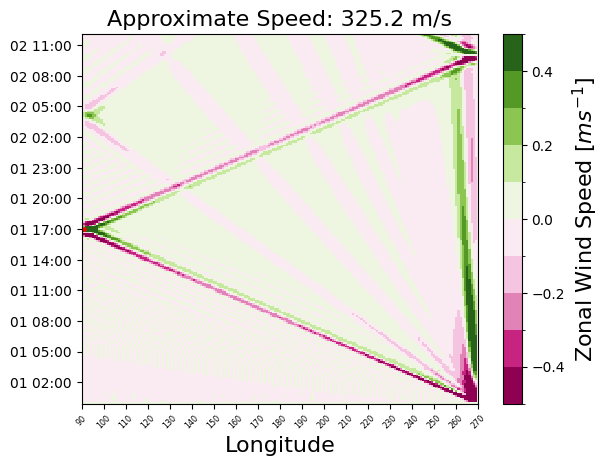

In [ ]:
# Hovmoller for single ds
# figure and axes
plt.figure(1)
hovmoller_ax = plt.axes()

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.5, 0.5, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(hovmoller_ax, ds_se_L58_pressure.U850, lat_value, cmap, norm,t_mask=1.5)

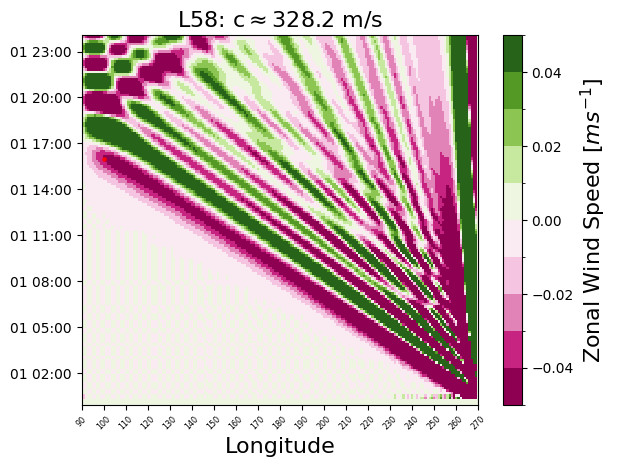

In [98]:
# Hovmoller for each dycore
# figure and axes
plt.figure(1)
hovmoller_ax = plt.axes()

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.05, 0.05, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(hovmoller_ax, ds_eul_L58_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='L58',lon_mid=100.0)

In [4]:
np.sqrt(275.0*1.4*287.0)

np.float64(332.40788197634544)

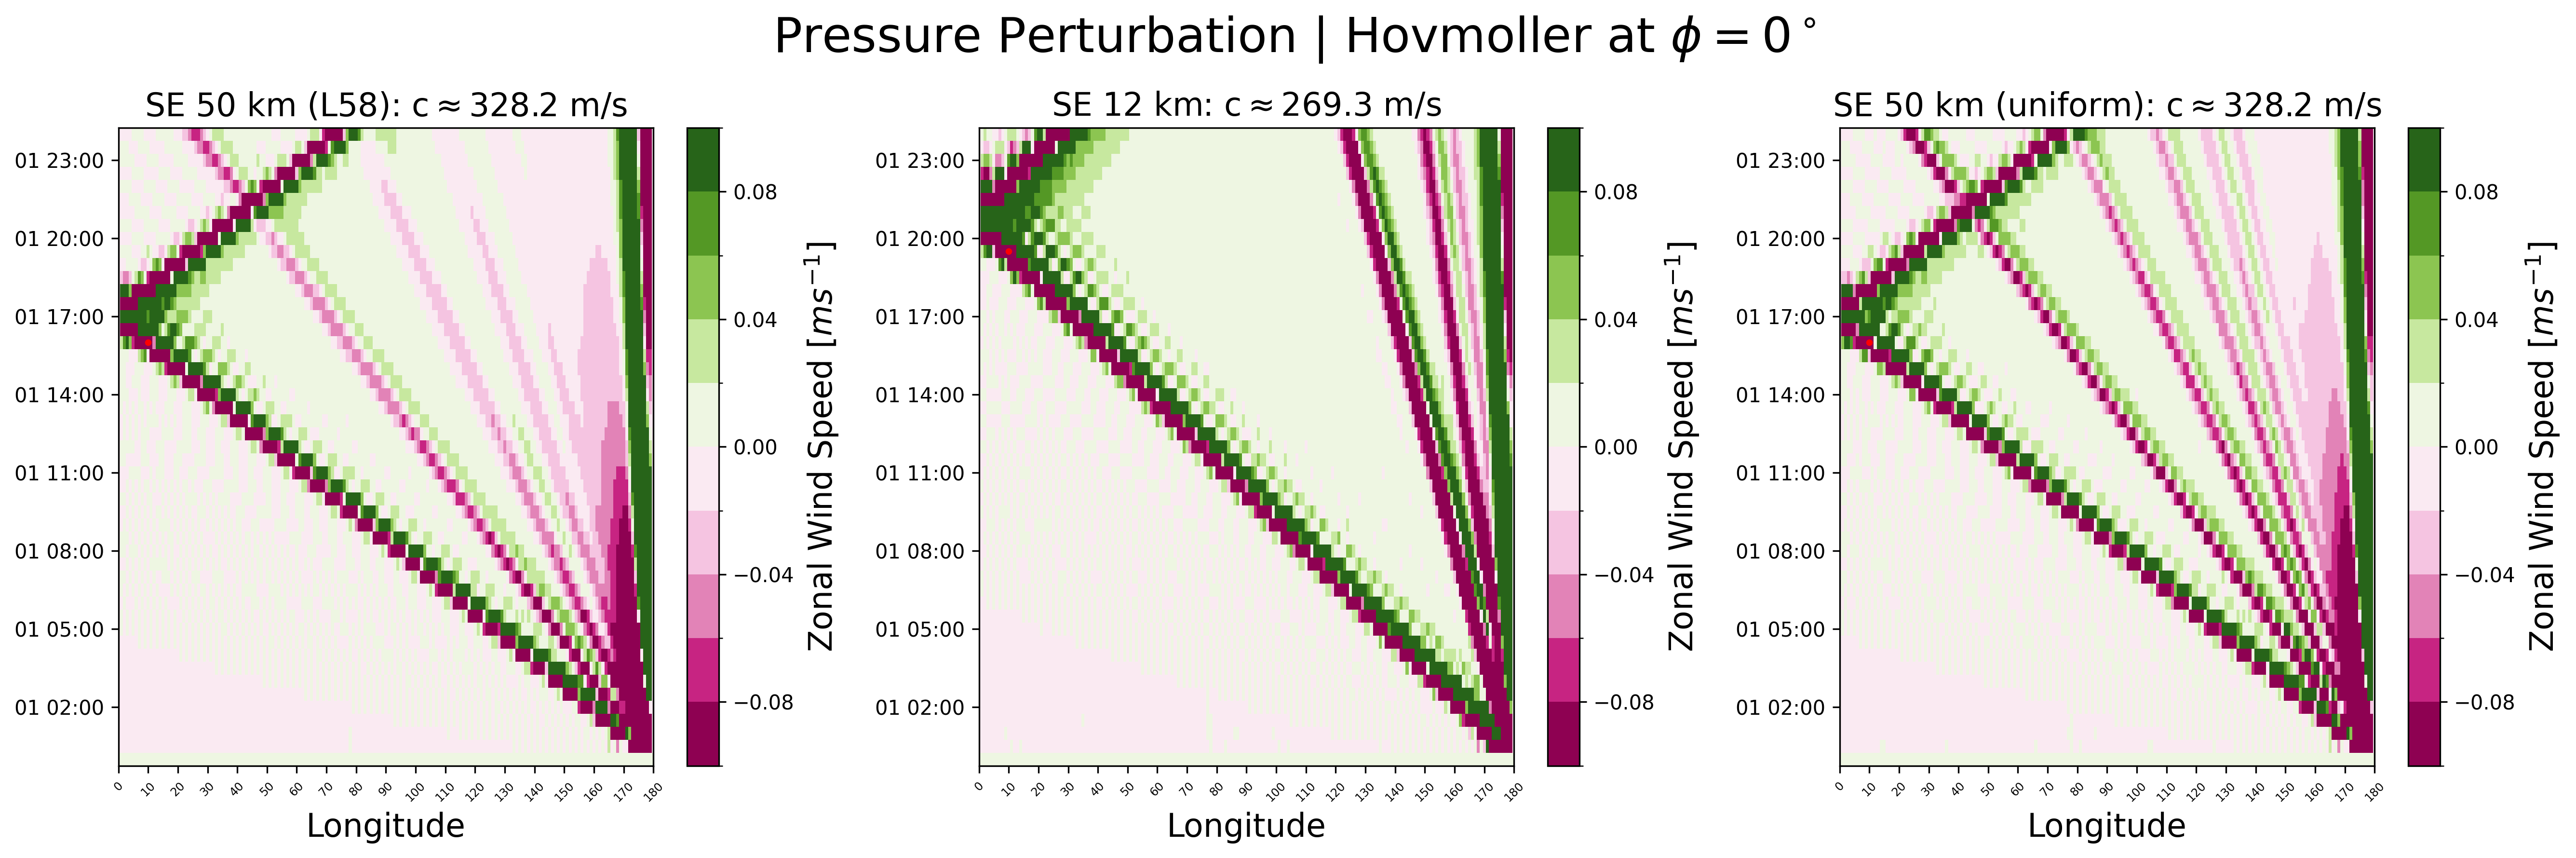

In [6]:
# Hovmoller for each dycore
# figure and axes
fig, ax = plt.subplots(1,3, figsize=(18,6),dpi=300)
se_L58_ax = ax[0]
fv3_L58_ax = ax[1]
eul_L58_ax = ax[2]



# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.1, 0.1, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(se_L58_ax, ds_high_top.U850, lat_value, cmap, norm,xlim_left=0.0,xlim_right=180.0,
          t_mask=1.0,use_min=True,model='SE 50 km (L58)',lon_mid=10.0,lon_start=180.0)
Hovmoller(fv3_L58_ax, ds_low_top.U850, lat_value, cmap, norm,xlim_left=0.0,xlim_right=180.0,
          t_mask=1.0,use_min=True,model='SE 12 km',lon_mid=10.0,lon_start=180.0)
Hovmoller(eul_L58_ax, ds_400m_50km.U850, lat_value, cmap, norm,xlim_left=0.0,xlim_right=180.0,
          t_mask=1.0,use_min=True,model='SE 50 km (uniform)',lon_mid=10.0,lon_start=180.0)

fig.suptitle(r'Pressure Perturbation | Hovmoller at $\phi=0^\circ$',fontsize=24)

fig.tight_layout()
plt.show()

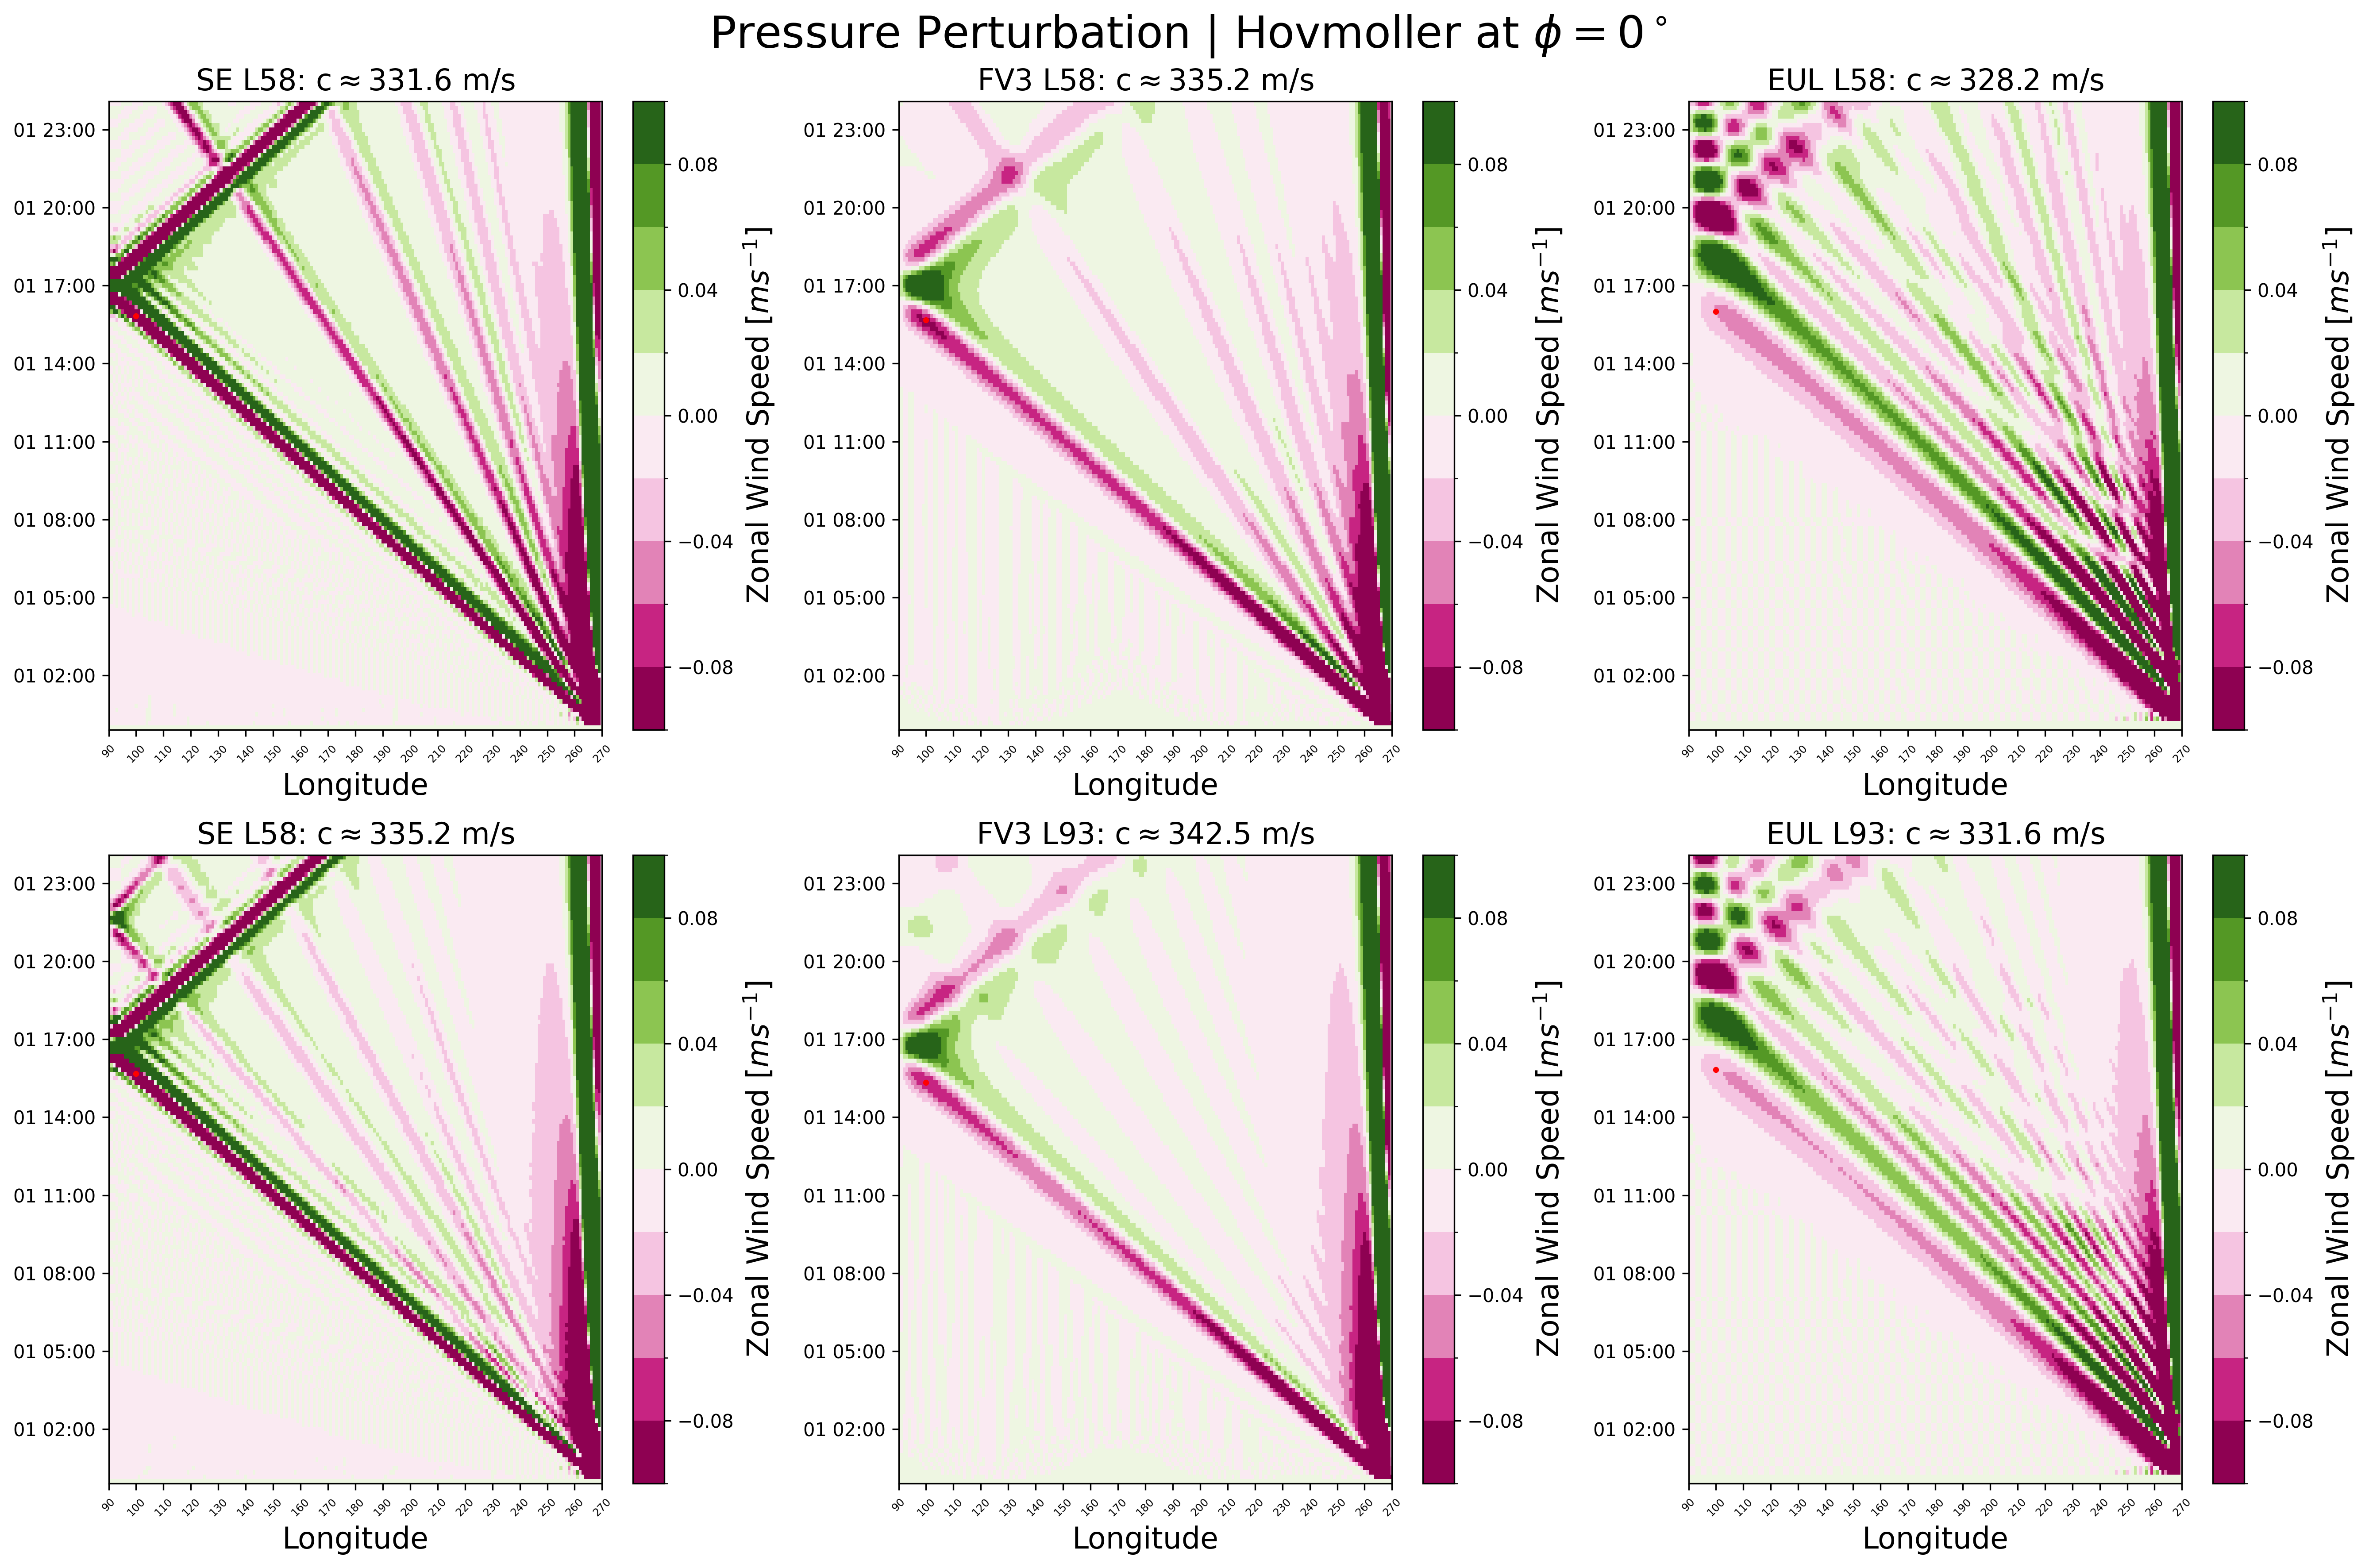

In [7]:
# Hovmoller for each dycore
# figure and axes
fig, ax = plt.subplots(2,3, figsize=(18,12),dpi=300)
se_L58_ax = ax[0,0]
fv3_L58_ax = ax[0,1]
eul_L58_ax = ax[0,2]

se_L93_ax = ax[1,0]
fv3_L93_ax = ax[1,1]
eul_L93_ax = ax[1,2]

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.1, 0.1, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(se_L58_ax, ds_se_L58_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='SE L58',lon_mid=100.0)
Hovmoller(fv3_L58_ax, ds_fv3_L58_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='FV3 L58',lon_mid=100.0)
Hovmoller(eul_L58_ax, ds_eul_L58_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='EUL L58',lon_mid=100.0)

fig.suptitle(r'Pressure Perturbation | Hovmoller at $\phi=0^\circ$',fontsize=24)

Hovmoller(se_L93_ax, ds_se_L93_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='SE L58',lon_mid=100.0)
Hovmoller(fv3_L93_ax, ds_fv3_L93_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='FV3 L93',lon_mid=100.0)
Hovmoller(eul_L93_ax, ds_eul_L93_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='EUL L93',lon_mid=100.0)

fig.tight_layout()
plt.show()

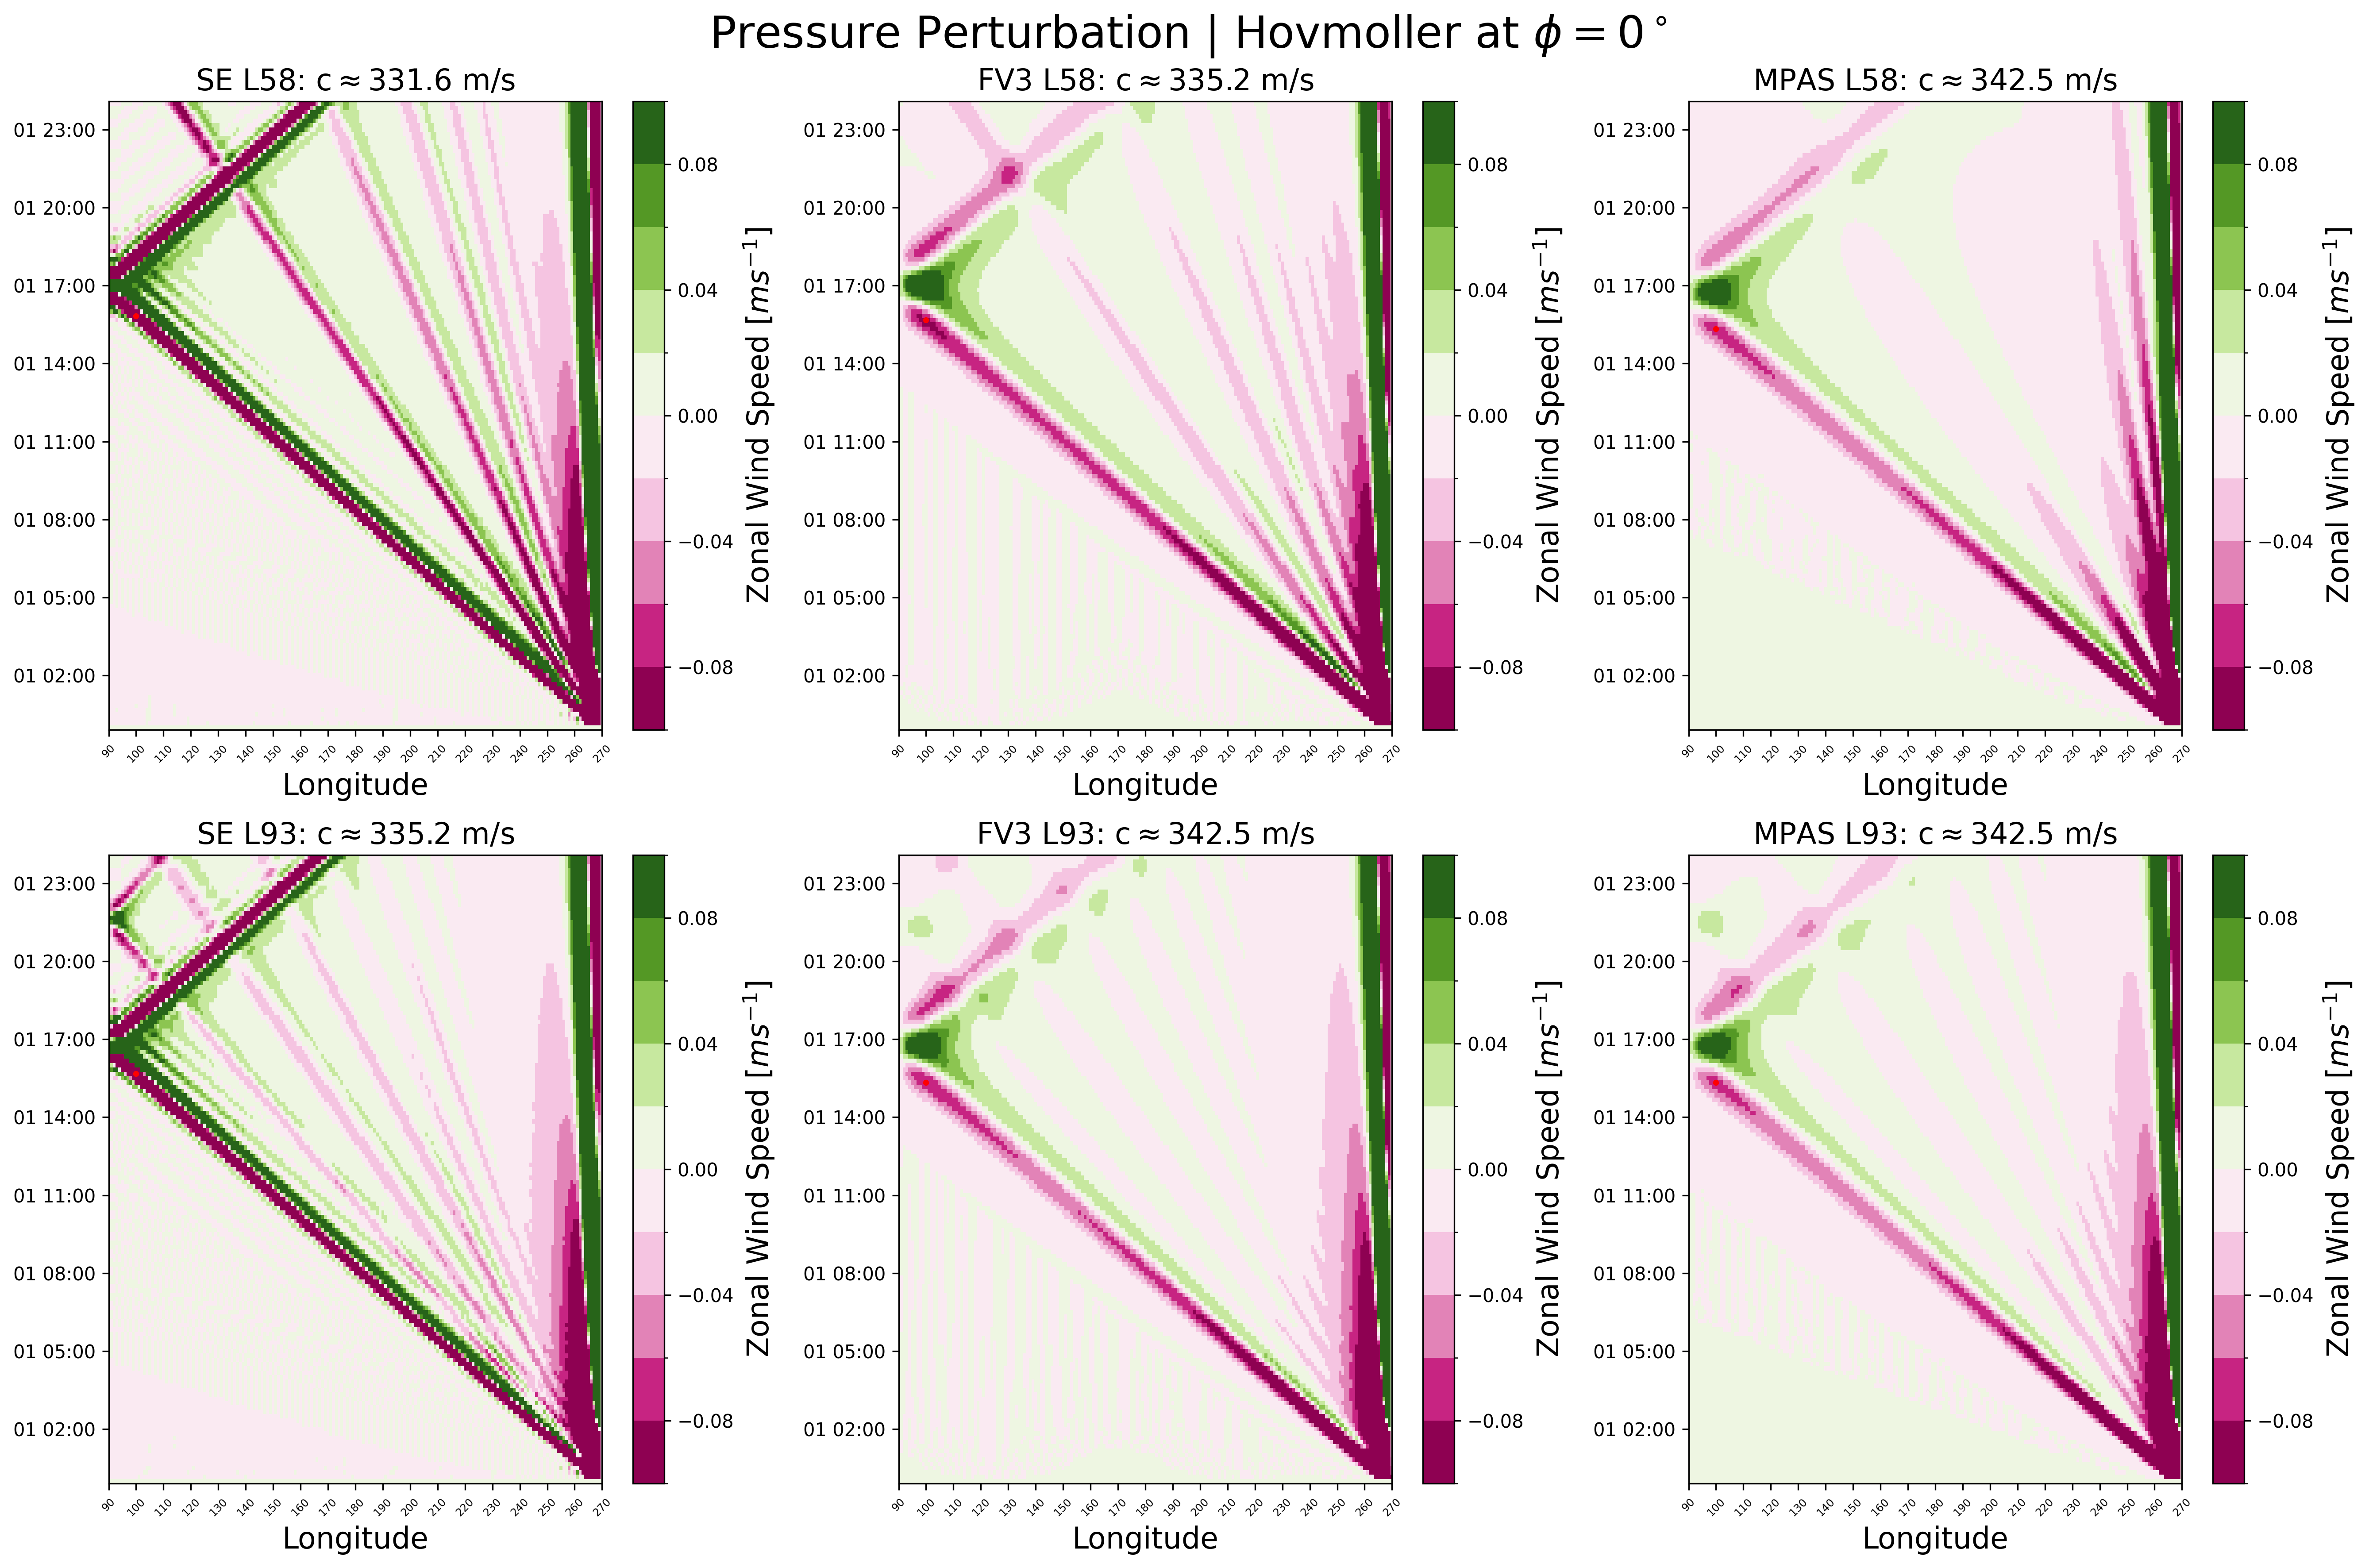

In [8]:
# Hovmoller for each dycore
# figure and axes
fig, ax = plt.subplots(2,3, figsize=(18,12),dpi=300)
se_L58_ax = ax[0,0]
fv3_L58_ax = ax[0,1]
eul_L58_ax = ax[0,2]

se_L93_ax = ax[1,0]
fv3_L93_ax = ax[1,1]
eul_L93_ax = ax[1,2]

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.1, 0.1, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(se_L58_ax, ds_se_L58_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='SE L58',lon_mid=100.0)
Hovmoller(fv3_L58_ax, ds_fv3_L58_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='FV3 L58',lon_mid=100.0)
# Hovmoller(eul_L58_ax, ds_eul_L58_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=False,model='EUL L58',lon_mid=180.0)
Hovmoller(eul_L58_ax, ds_mpas_L58_pressure_RF20km.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='MPAS L58',lon_mid=100.0)


fig.suptitle(r'Pressure Perturbation | Hovmoller at $\phi=0^\circ$',fontsize=24)

Hovmoller(se_L93_ax, ds_se_L93_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='SE L93',lon_mid=100.0)
Hovmoller(fv3_L93_ax, ds_fv3_L93_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='FV3 L93',lon_mid=100.0)
# Hovmoller(eul_L93_ax, ds_eul_L93_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='EUL L93',lon_mid=180.0)
Hovmoller(eul_L93_ax, ds_mpas_L93_pressure.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='MPAS L93',lon_mid=100.0)


fig.tight_layout()
plt.show()

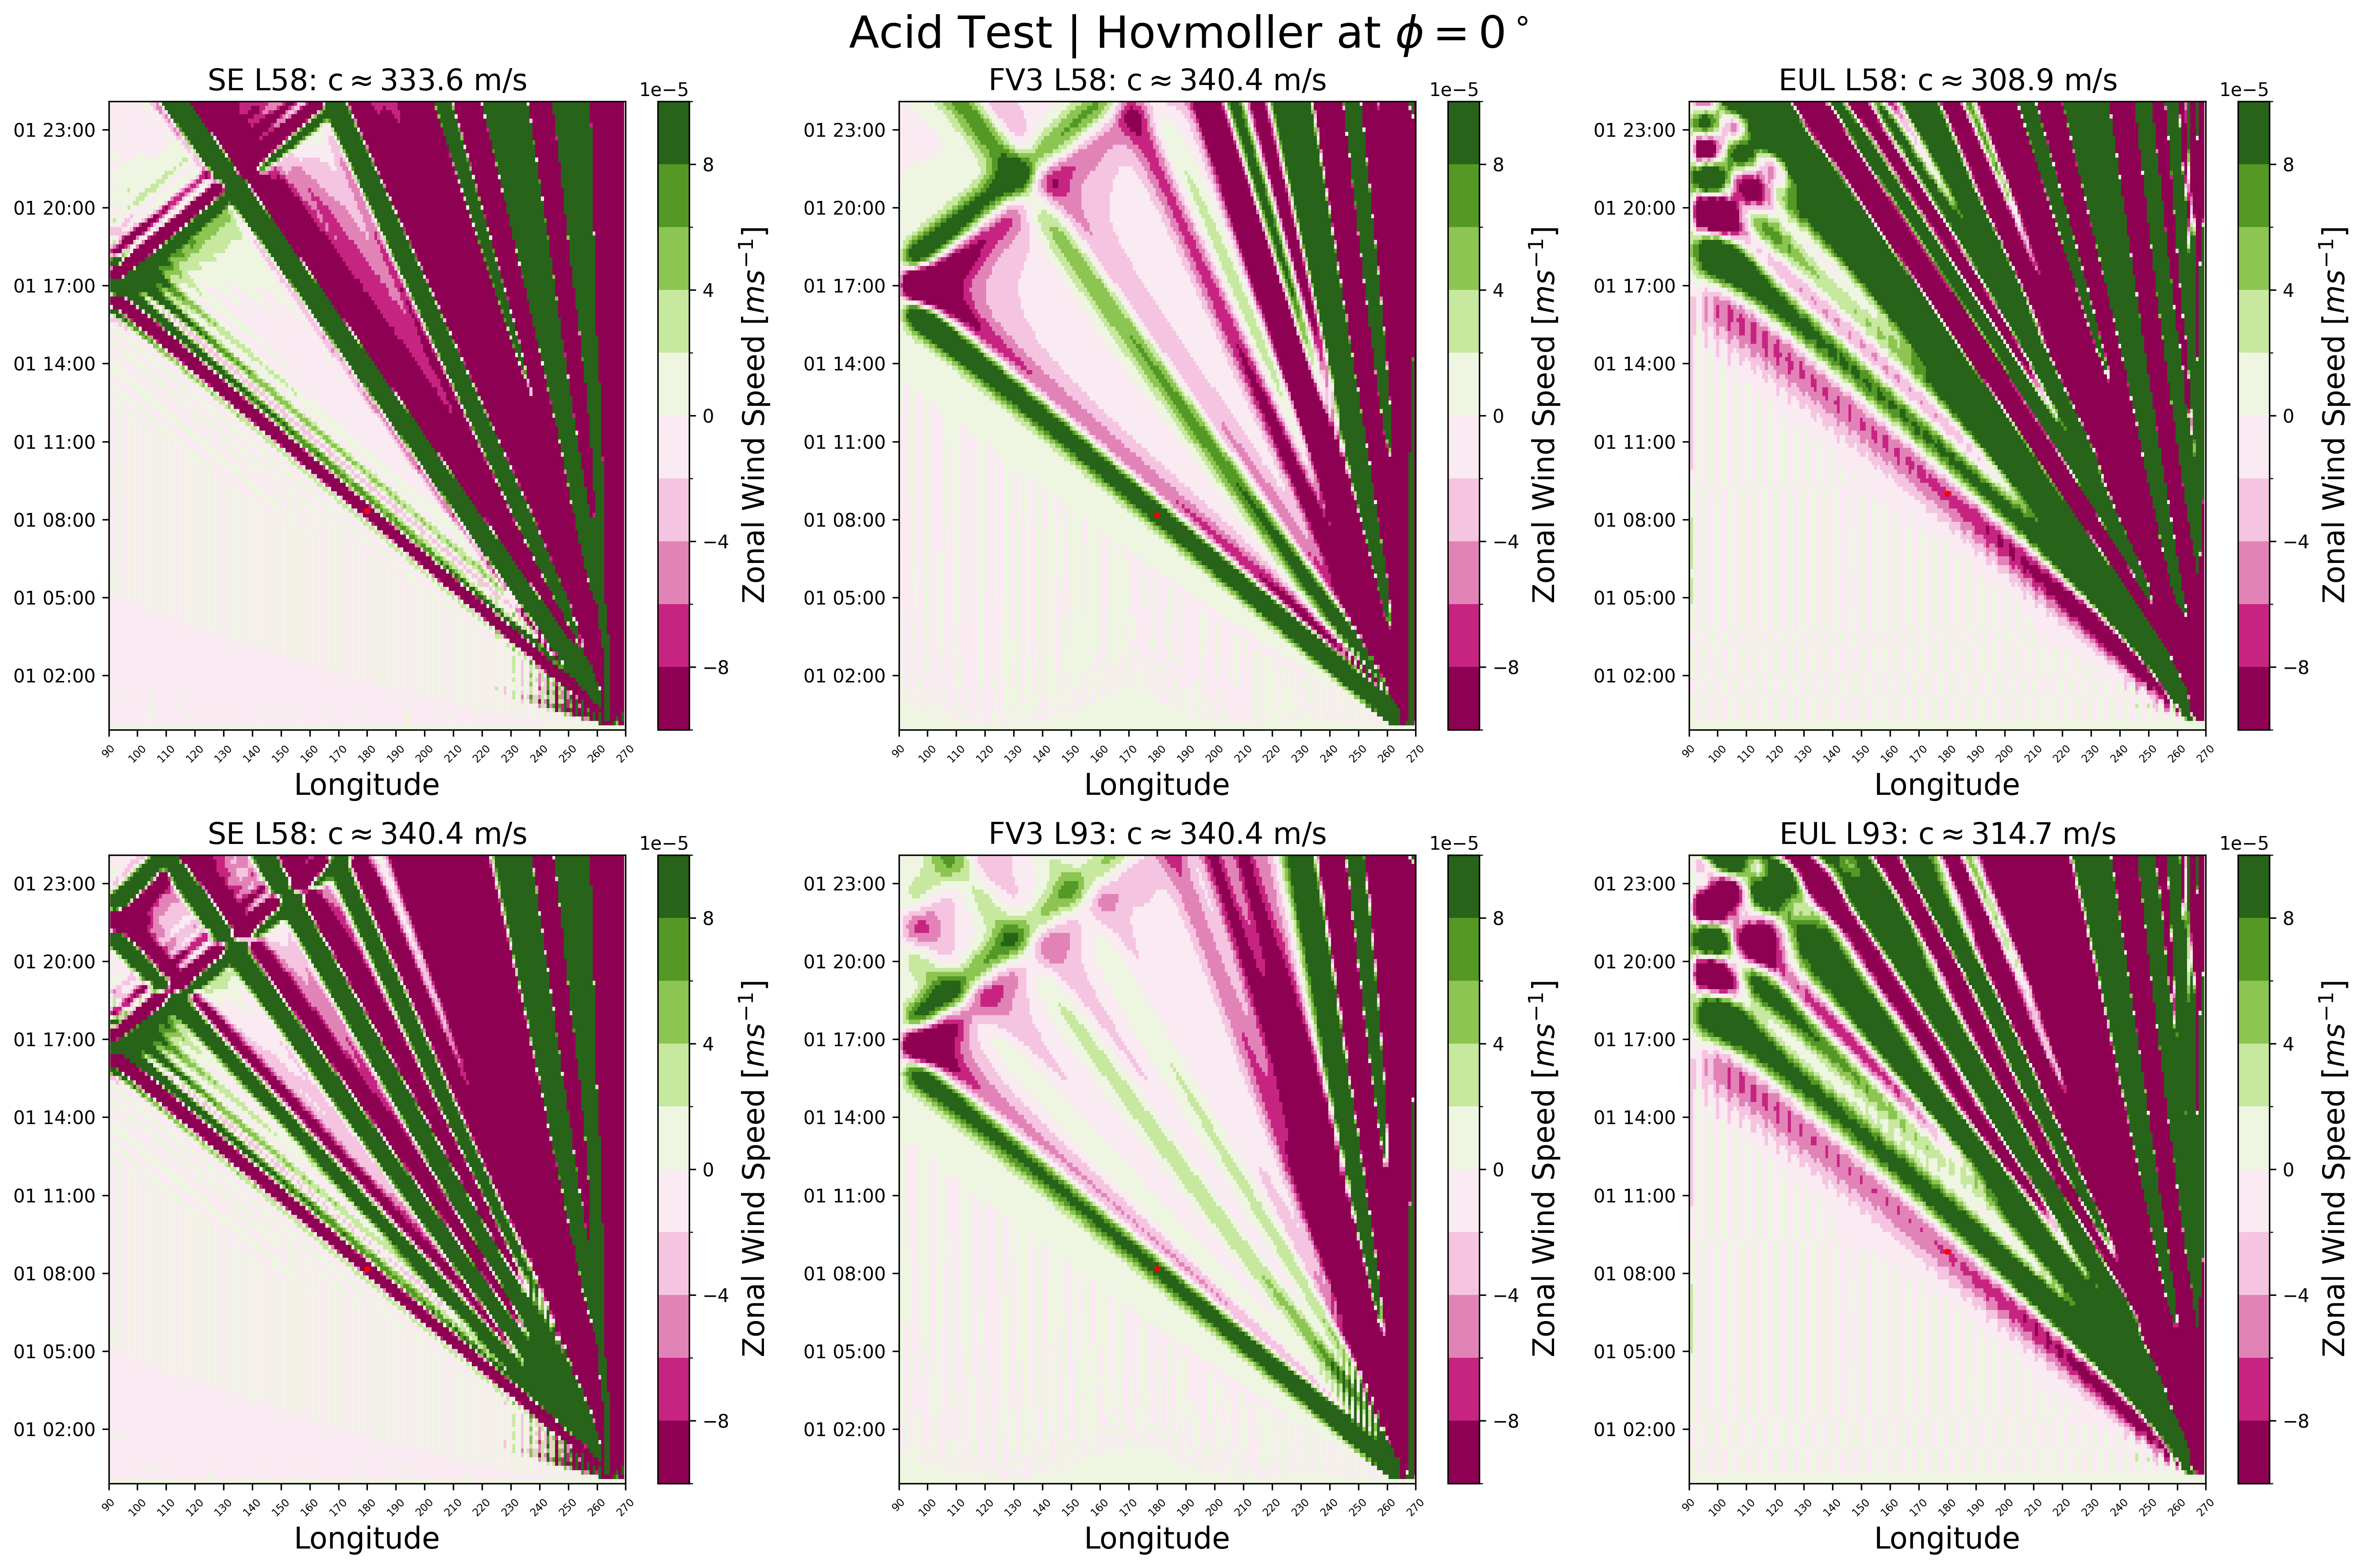

In [4]:
fig, ax = plt.subplots(2,3, figsize=(18,12),dpi=300)
se_L58_ax = ax[0,0]
fv3_L58_ax = ax[0,1]
eul_L58_ax = ax[0,2]

se_L93_ax = ax[1,0]
fv3_L93_ax = ax[1,1]
eul_L93_ax = ax[1,2]

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.0001, 0.0001, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(se_L58_ax, ds_se_L58_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='SE L58',lon_mid=180.0)
Hovmoller(fv3_L58_ax, ds_fv3_L58_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=False,model='FV3 L58',lon_mid=180.0)
Hovmoller(eul_L58_ax, ds_eul_L58_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='EUL L58',lon_mid=180.0)

fig.suptitle(r'Acid Test | Hovmoller at $\phi=0^\circ$',fontsize=24)

Hovmoller(se_L93_ax, ds_se_L93_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='SE L58',lon_mid=180.0)
Hovmoller(fv3_L93_ax, ds_fv3_L93_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=False,model='FV3 L93',lon_mid=180.0)
Hovmoller(eul_L93_ax, ds_eul_L93_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='EUL L93',lon_mid=180.0,check_next_extrema=True)

fig.tight_layout()
plt.show()

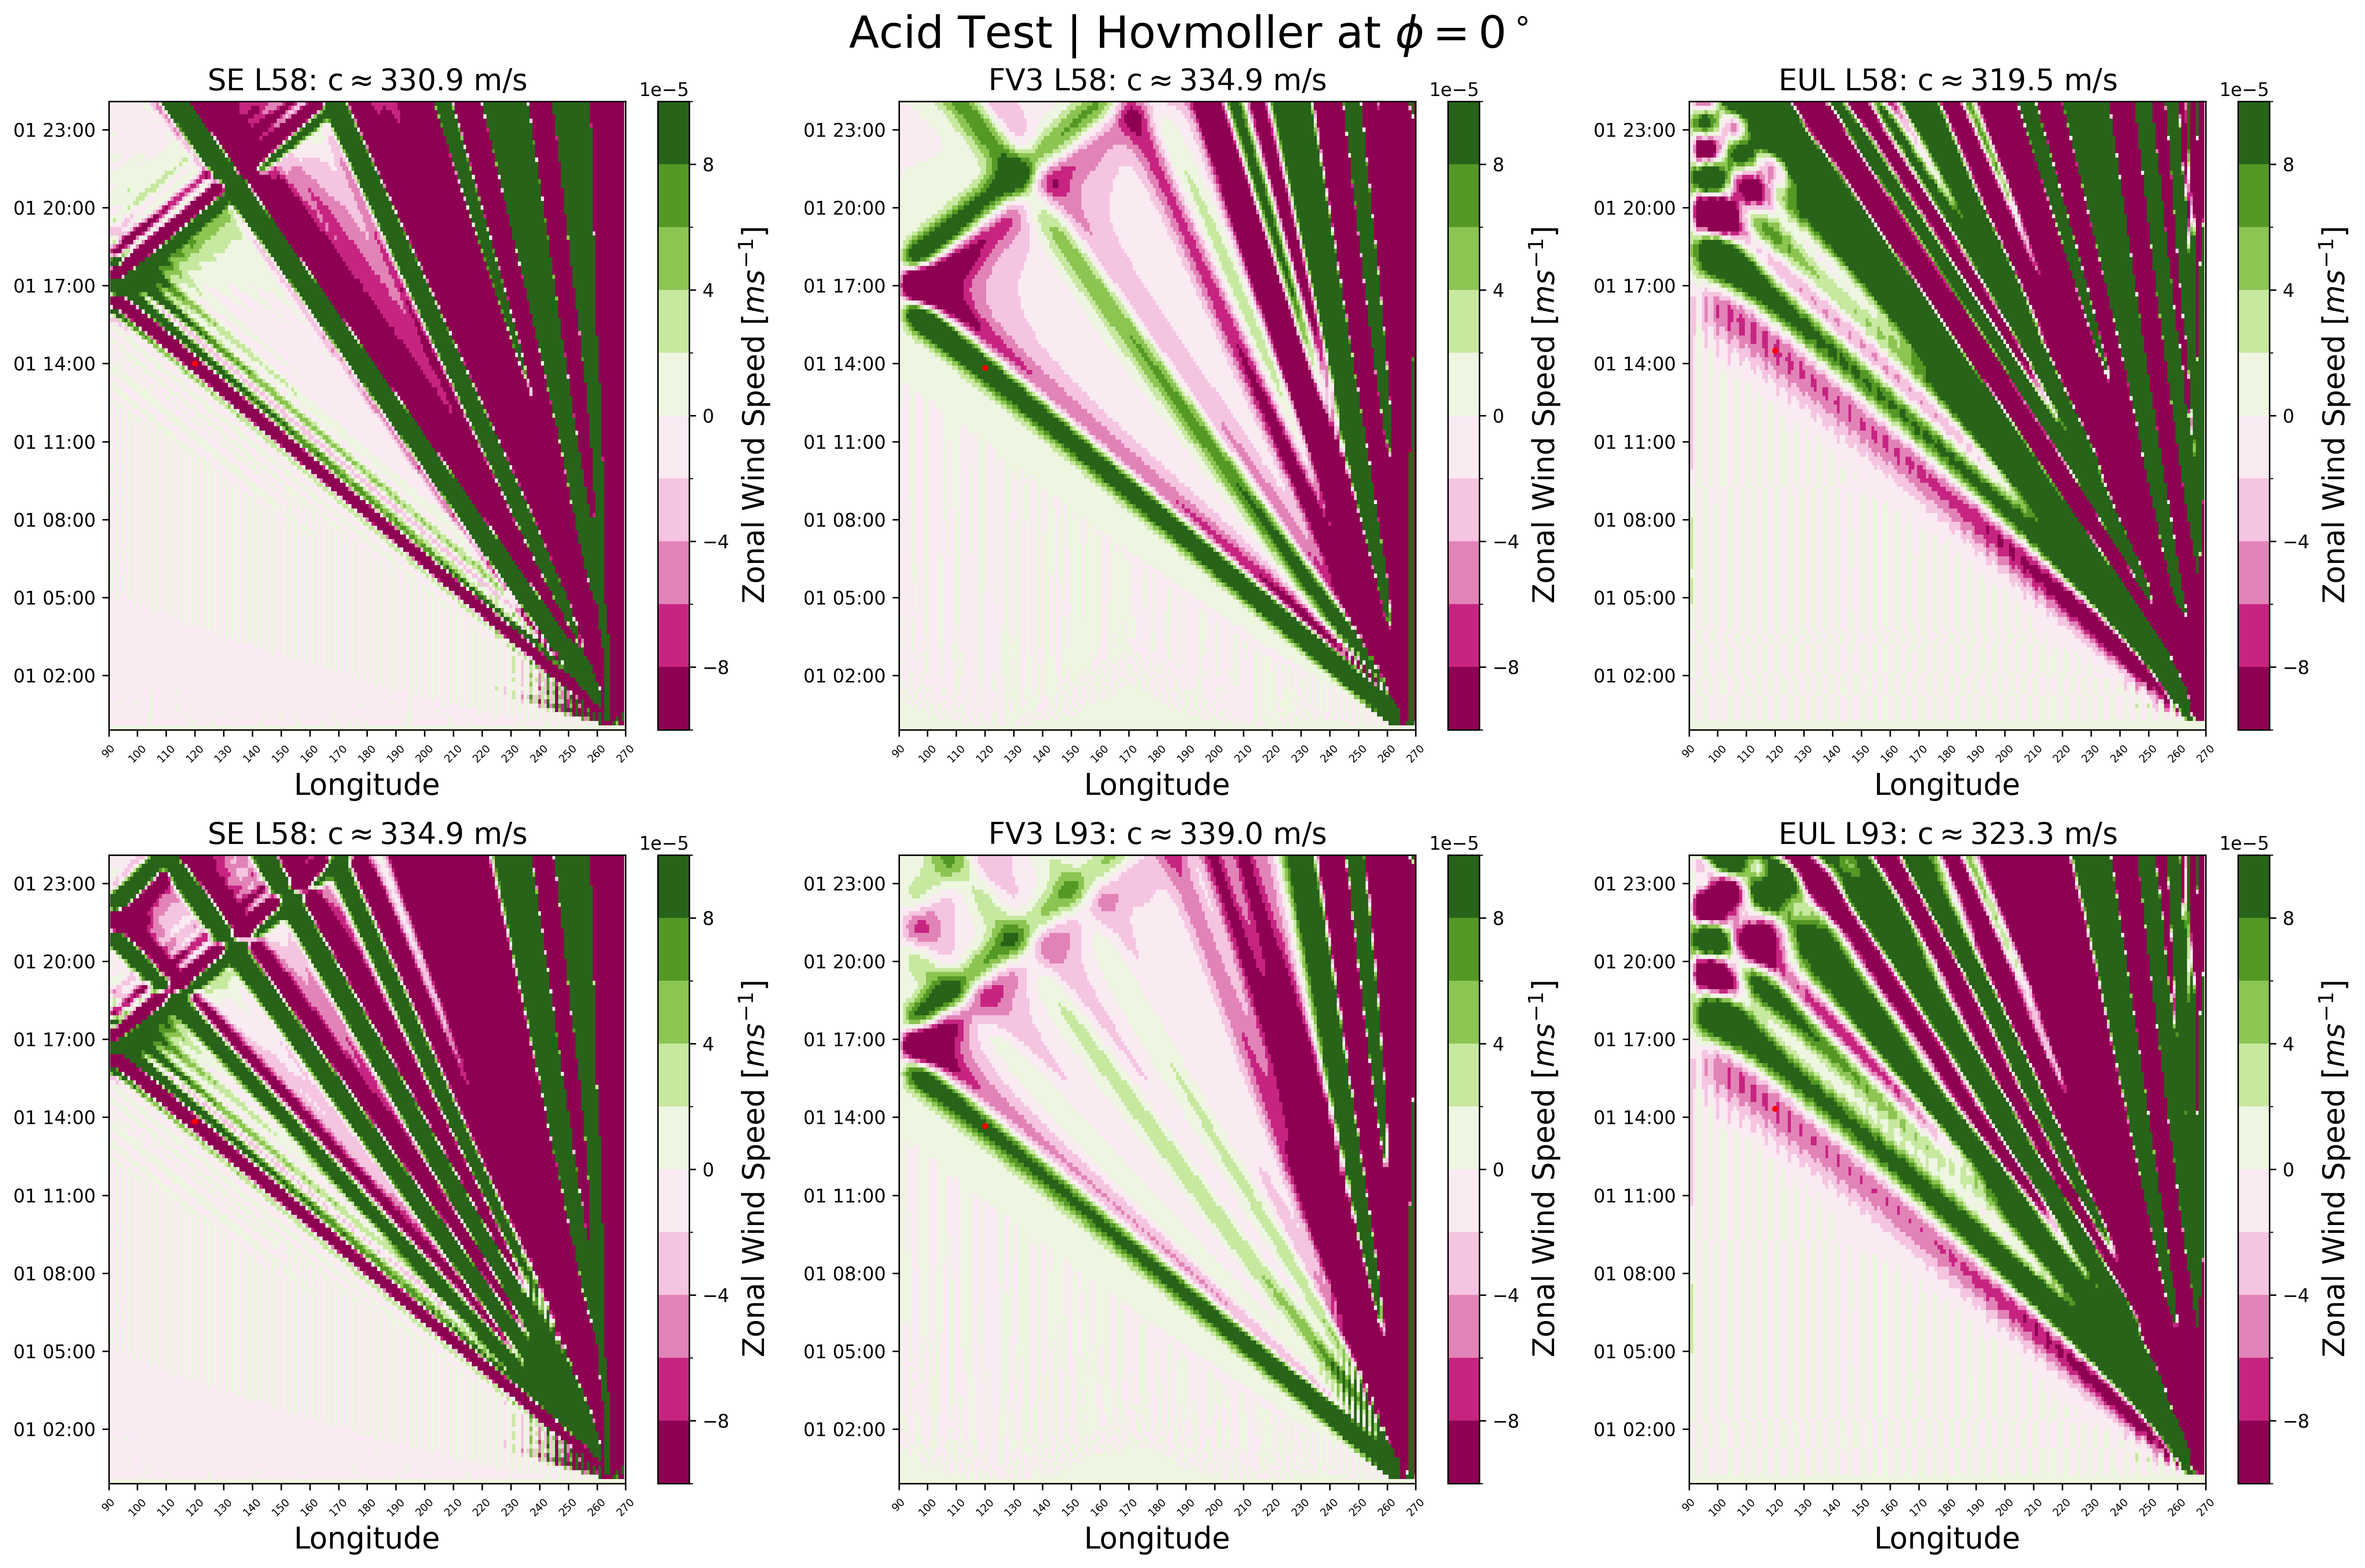

In [9]:
fig, ax = plt.subplots(2,3, figsize=(18,12),dpi=300)
se_L58_ax = ax[0,0]
fv3_L58_ax = ax[0,1]
eul_L58_ax = ax[0,2]

se_L93_ax = ax[1,0]
fv3_L93_ax = ax[1,1]
eul_L93_ax = ax[1,2]

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.0001, 0.0001, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(se_L58_ax, ds_se_L58_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='SE L58',lon_mid=120.0)
Hovmoller(fv3_L58_ax, ds_fv3_L58_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=False,model='FV3 L58',lon_mid=120.0)
Hovmoller(eul_L58_ax, ds_eul_L58_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='EUL L58',lon_mid=120.0)

fig.suptitle(r'Acid Test | Hovmoller at $\phi=0^\circ$',fontsize=24)

Hovmoller(se_L93_ax, ds_se_L93_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='SE L58',lon_mid=120.0)
Hovmoller(fv3_L93_ax, ds_fv3_L93_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=False,model='FV3 L93',lon_mid=120.0)
Hovmoller(eul_L93_ax, ds_eul_L93_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='EUL L93',lon_mid=120.0,check_next_extrema=True)

fig.tight_layout()
plt.show()

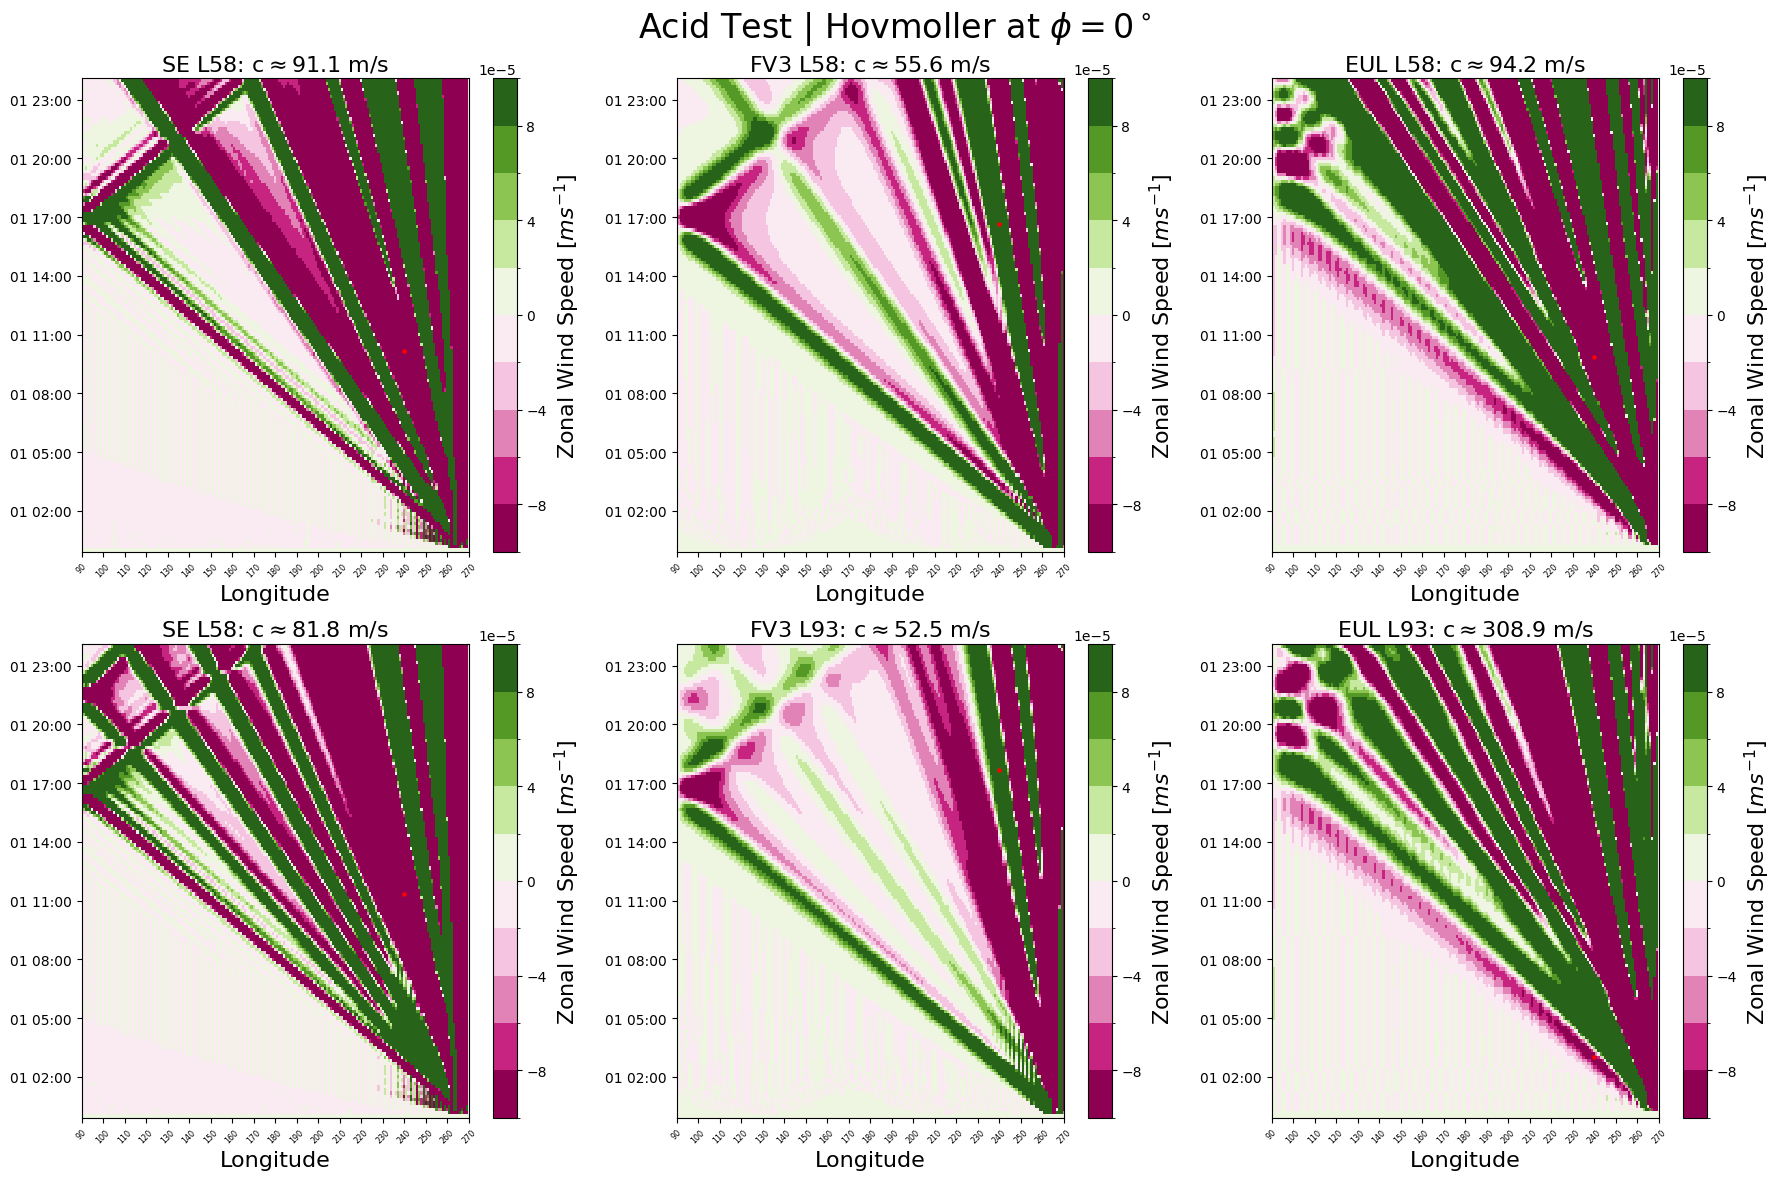

In [114]:
fig, ax = plt.subplots(2,3, figsize=(18,12))
se_L58_ax = ax[0,0]
fv3_L58_ax = ax[0,1]
eul_L58_ax = ax[0,2]

se_L93_ax = ax[1,0]
fv3_L93_ax = ax[1,1]
eul_L93_ax = ax[1,2]

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.0001, 0.0001, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(se_L58_ax, ds_se_L58_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='SE L58',lon_mid=240.0)
Hovmoller(fv3_L58_ax, ds_fv3_L58_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=False,model='FV3 L58',lon_mid=240.0)
Hovmoller(eul_L58_ax, ds_eul_L58_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='EUL L58',lon_mid=240.0)

fig.suptitle(r'Acid Test | Hovmoller at $\phi=0^\circ$',fontsize=24)

Hovmoller(se_L93_ax, ds_se_L93_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='SE L58',lon_mid=240.0)
Hovmoller(fv3_L93_ax, ds_fv3_L93_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=False,model='FV3 L93',lon_mid=240.0)
Hovmoller(eul_L93_ax, ds_eul_L93_acid.U850, lat_value, cmap, norm,t_mask=1.0,use_min=True,model='EUL L93',lon_mid=240.0,check_next_extrema=True)

fig.tight_layout()
plt.show()

# FFT Analysis

## Individual

Num time points:  193
Num grid points:  360
signal_fft.shape:  (193, 181)


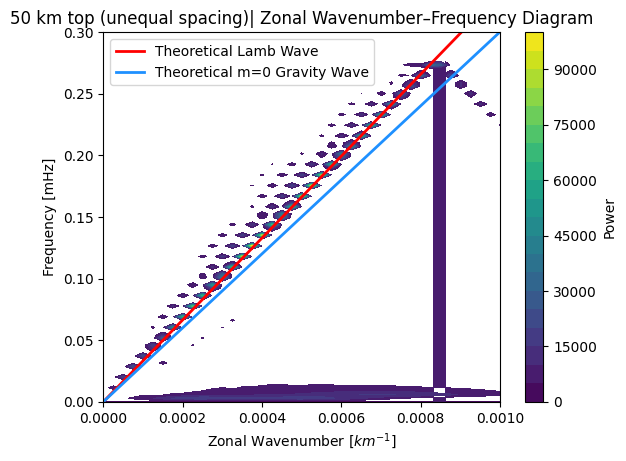

In [3]:
# scipy rfft2: computes 2D FFT of a real-values input signal
# scipy fftfreq: Returns the Discrete Fourier Transform sample frequencies (returns array length n)
# scipy rfftfreq: Return the Discrete Fourier Transform sample frequencies (returns array length n//2 + 1)

# select U at 850 hPa along the Equator
U850 = ds_high_top.U850.sel(lat=0)

# calculate anomalies from time mean to be used as signal for FFT
signal = U850 - U850.mean(dim='time')

# number of time points and number of grid points
nt, nx = signal.shape
print('Num time points: ', nt)
print('Num grid points: ', nx)

dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters

# 2D FFT
signal_fft = rfft2(signal)
print('signal_fft.shape: ', signal_fft.shape)

freq = fftfreq(nt, d=dt)               # s^-1
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1

power = np.abs(signal_fft)**2

# sound speed, isothermal atmosphere
T0 = 275
Rd = 287
cp = 1004
cv = 717
g  = 9.80616
gamma = cp / cv
cs = np.sqrt(gamma * Rd * T0) / 1000  # km s^-1
H = Rd*T0/g / 1000.0 # km
N = g / np.sqrt(cp*T0) #Hz


# Lamb wave dispersion relationship
omega_S = cs * wavenumber * 1e3         # mHz
omega_GW = np.sqrt((N * wavenumber)**2 / (wavenumber**2 + 0.25/(H**2))) * 1e3         # mHz


# plot
plt.figure(4)
plt.contourf(wavenumber, freq*1e3, power, levels=20)  # plot frequency in mHz
plt.plot(wavenumber, omega_S, 'r-', label='Theoretical Lamb Wave', linewidth=2)
plt.plot(wavenumber, omega_GW, '-', color='dodgerblue', label='Theoretical m=0 Gravity Wave', linewidth=2)

plt.xlabel(r"Zonal Wavenumber [$km^{-1}$]")
plt.ylabel("Frequency [mHz]")
plt.xlim((0, 0.001))
plt.ylim((0, 0.3))
plt.title("50 km top (unequal spacing)| Zonal Wavenumber–Frequency Diagram")
plt.colorbar(label='Power')
plt.legend()
plt.show()

Num time points:  241
Num grid points:  360
signal_fft.shape:  (241, 181)
0.028 0.0038593021163121125
224.39947525641378 18.699956271367814


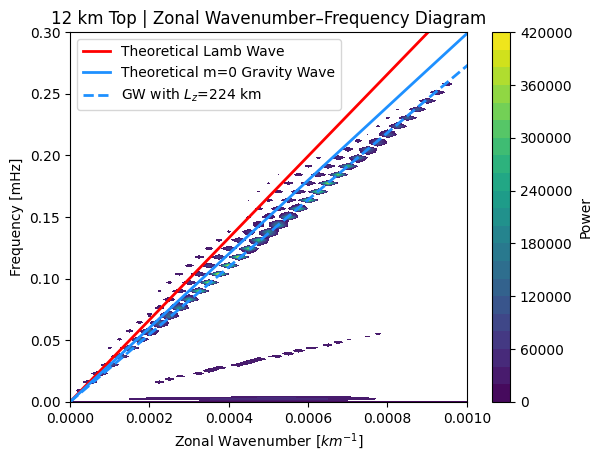

In [18]:
# scipy rfft2: computes 2D FFT of a real-values input signal
# scipy fftfreq: Returns the Discrete Fourier Transform sample frequencies (returns array length n)
# scipy rfftfreq: Return the Discrete Fourier Transform sample frequencies (returns array length n//2 + 1)

# select U at 850 hPa along the Equator
U850 = ds_low_top.U850.sel(lat=0)

# calculate anomalies from time mean to be used as signal for FFT
signal = U850 - U850.mean(dim='time')

# number of time points and number of grid points
nt, nx = signal.shape
print('Num time points: ', nt)
print('Num grid points: ', nx)

dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters

# 2D FFT
signal_fft = rfft2(signal)
print('signal_fft.shape: ', signal_fft.shape)

freq = fftfreq(nt, d=dt)               # s^-1
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1

power = np.abs(signal_fft)**2

# sound speed, isothermal atmosphere
T0 = 275
Rd = 287
cp = 1004
cv = 717
g  = 9.80616
gamma = cp / cv
cs = np.sqrt(gamma * Rd * T0) / 1000  # km s^-1
H = Rd*T0/g / 1000.0 # km
N = g / np.sqrt(cp*T0) # Hz


# Lamb wave dispersion relationship
omega_S = cs * wavenumber * 1e3         # mHz
omega_GW = np.sqrt((N * (2*np.pi*wavenumber))**2 / ((2*np.pi*wavenumber)**2 + 0.25/(H**2))) * 1e3 / 2.0/np.pi        # mHz

m_top = 2*np.pi/12.0
m_top = 0.028
print(m_top,0.25/(H**2))
print(2*np.pi/m_top,2*np.pi/m_top/12.0)
omega_GW_mtop = np.sqrt((N * (2*np.pi*wavenumber))**2 / ((2*np.pi*wavenumber)**2 + (m_top)**2 + 0.25/(H**2))) * 1e3 / 2.0/np.pi        # mHz


# plot
plt.figure(4)
plt.contourf(wavenumber, freq*1e3, power, levels=20)  # plot frequency in mHz
plt.plot(wavenumber, omega_S, 'r-', label='Theoretical Lamb Wave', linewidth=2)
plt.plot(wavenumber, omega_GW, '-', color='dodgerblue', label='Theoretical m=0 Gravity Wave', linewidth=2)
plt.plot(wavenumber, omega_GW_mtop, '--', color='dodgerblue', label=r'GW with $L_z$'+f'={2*np.pi/m_top:.0f} km', linewidth=2)


plt.xlabel(r"Zonal Wavenumber [$km^{-1}$]")
plt.ylabel("Frequency [mHz]")
plt.xlim((0, 0.001))
plt.ylim((0, 0.3))
plt.title("12 km Top | Zonal Wavenumber–Frequency Diagram")
plt.colorbar(label='Power')
plt.legend()
plt.show()

Num time points:  250
Num grid points:  360
signal_fft.shape:  (250, 181)


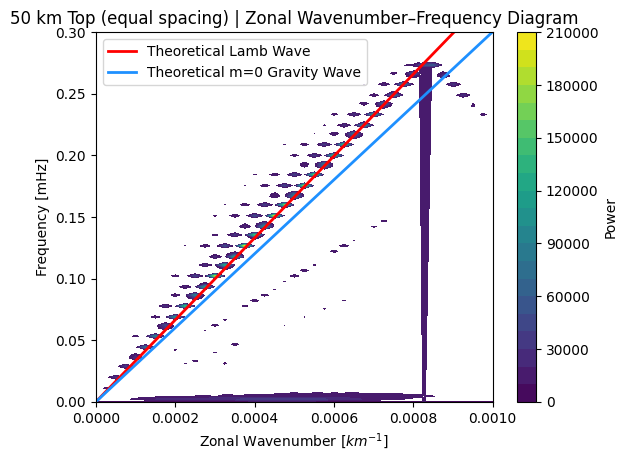

In [ ]:
# scipy rfft2: computes 2D FFT of a real-values input signal
# scipy fftfreq: Returns the Discrete Fourier Transform sample frequencies (returns array length n)
# scipy rfftfreq: Return the Discrete Fourier Transform sample frequencies (returns array length n//2 + 1)

# select U at 850 hPa along the Equator
U850 = ds_400m_50km.U850.sel(lat=0)

# calculate anomalies from time mean to be used as signal for FFT
signal = U850 - U850.mean(dim='time')

# number of time points and number of grid points
nt, nx = signal.shape
print('Num time points: ', nt)
print('Num grid points: ', nx)

dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters

# 2D FFT
signal_fft = rfft2(signal)
print('signal_fft.shape: ', signal_fft.shape)

freq = fftfreq(nt, d=dt)               # s^-1
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1

power = np.abs(signal_fft)**2

# sound speed, isothermal atmosphere
T0 = 275
Rd = 287
cp = 1004
cv = 717
g  = 9.80616
gamma = cp / cv
cs = np.sqrt(gamma * Rd * T0) / 1000  # km s^-1
H = Rd*T0/g / 1000.0 # km
N = g / np.sqrt(cp*T0) #Hz


# Lamb wave dispersion relationship
omega_S = cs * wavenumber * 1e3         # mHz
omega_GW = np.sqrt((N * (2*np.pi*wavenumber))**2 / ((2*np.pi*wavenumber)**2 + 0.25/(H**2))) * 1e3 / 2.0/np.pi        # mHz


# plot
plt.figure(4)
plt.contourf(wavenumber, freq*1e3, power, levels=20)  # plot frequency in mHz
plt.plot(wavenumber, omega_S, 'r-', label='Theoretical Lamb Wave', linewidth=2)
plt.plot(wavenumber, omega_GW, '-', color='dodgerblue', label='Theoretical m=0 Gravity Wave', linewidth=2)

plt.xlabel(r"Zonal Wavenumber [$km^{-1}$]")
plt.ylabel("Frequency [mHz]")
plt.xlim((0, 0.001))
plt.ylim((0, 0.3))
plt.title("50 km Top (equal spacing) | Zonal Wavenumber–Frequency Diagram")
plt.colorbar(label='Power')
plt.legend()
plt.show()

## Grouped

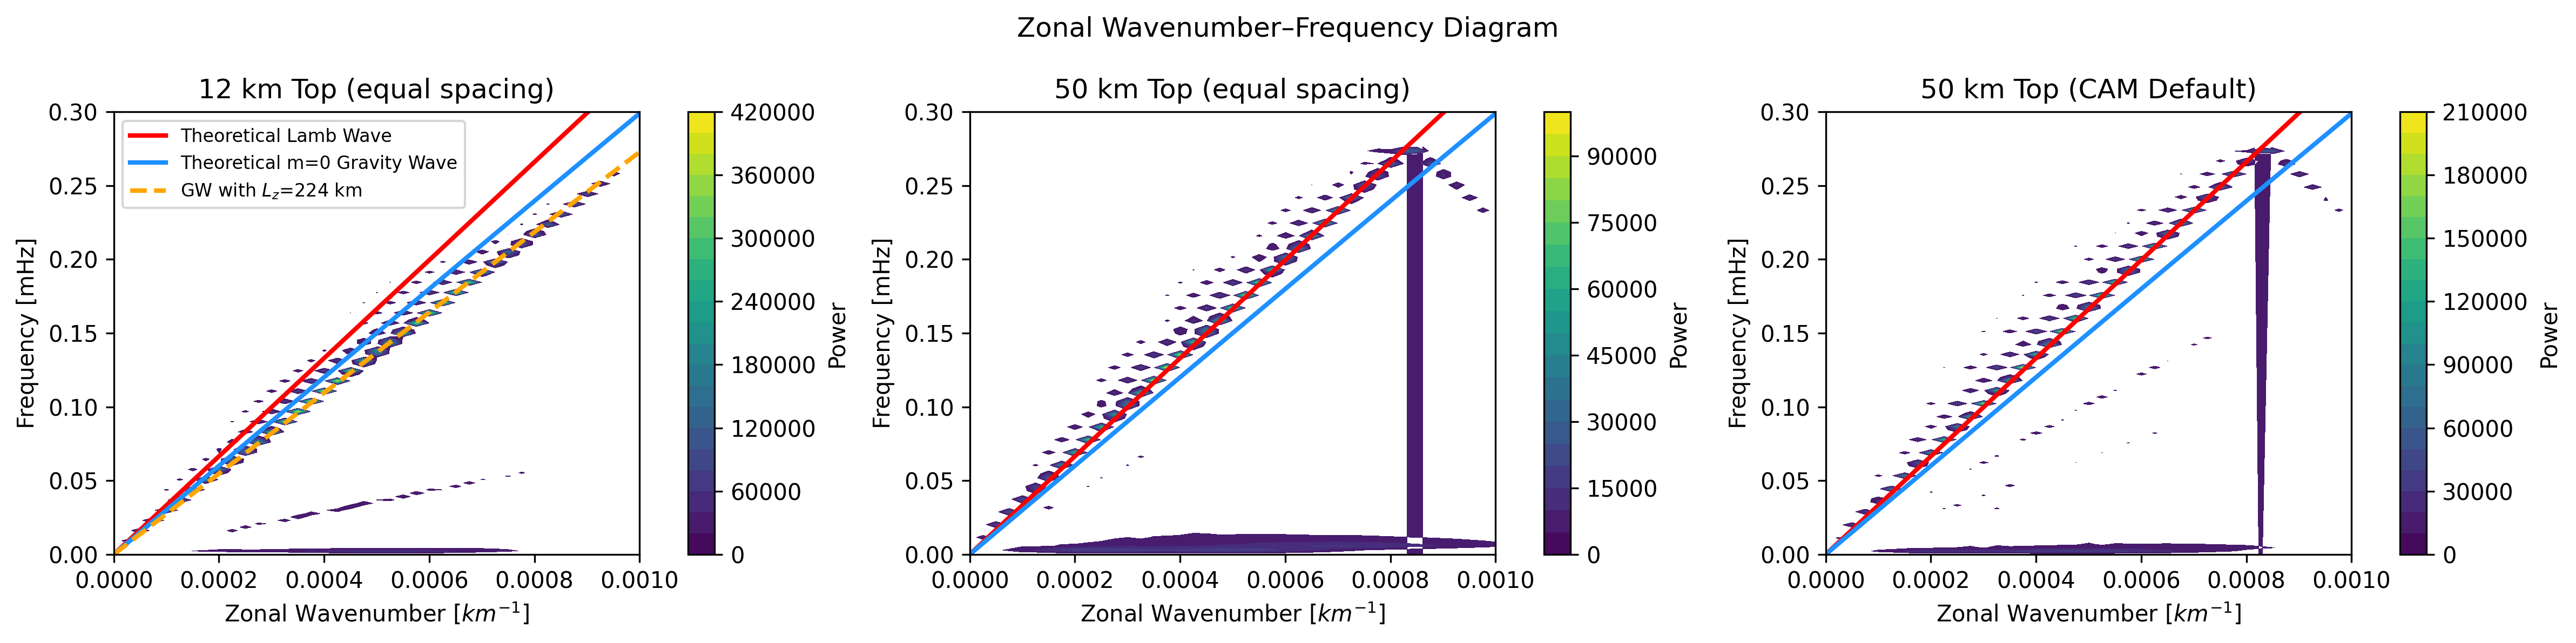

In [38]:
fig, axes = plt.subplots(1,3,figsize=(16,4),dpi=300)

# select U at 850 hPa along the Equator
U850 = ds_low_top.U850.sel(lat=0)

# calculate anomalies from time mean to be used as signal for FFT
signal = U850 - U850.mean(dim='time')
# number of time points and number of grid points
nt, nx = signal.shape
dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters
# 2D FFT
signal_fft = rfft2(signal)
freq = fftfreq(nt, d=dt)               # s^-1
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1
power = np.abs(signal_fft)**2
CF1=axes[0].contourf(wavenumber, freq*1e3, power, levels=20)  # plot frequency in mHz
axes[0].set_title("12 km Top (equal spacing)")


# select U at 850 hPa along the Equator
U850 = ds_high_top.U850.sel(lat=0)

# calculate anomalies from time mean to be used as signal for FFT
signal = U850 - U850.mean(dim='time')
# number of time points and number of grid points
nt, nx = signal.shape
dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters
# 2D FFT
signal_fft = rfft2(signal)
freq = fftfreq(nt, d=dt)               # s^-1
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1
power = np.abs(signal_fft)**2
CF2 = axes[1].contourf(wavenumber, freq*1e3, power, levels=20)  # plot frequency in mHz
axes[1].set_title("50 km Top (equal spacing)")


# select U at 850 hPa along the Equator
U850 = ds_400m_50km.U850.sel(lat=0)
# calculate anomalies from time mean to be used as signal for FFT
signal = U850 - U850.mean(dim='time')
# number of time points and number of grid points
nt, nx = signal.shape
dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters
# 2D FFT
signal_fft = rfft2(signal)
freq = fftfreq(nt, d=dt)               # s^-1
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1
power = np.abs(signal_fft)**2
CF3=axes[2].contourf(wavenumber, freq*1e3, power, levels=20)  # plot frequency in mHz
axes[2].set_title("50 km Top (CAM Default)")

CFs=[CF1,CF2,CF3]

# sound speed, isothermal atmosphere
T0 = 275
Rd = 287
cp = 1004
cv = 717
g  = 9.80616
gamma = cp / cv
cs = np.sqrt(gamma * Rd * T0) / 1000  # km s^-1
H = Rd*T0/g / 1000.0 # km
N = g / np.sqrt(cp*T0) #Hz


# Lamb wave dispersion relationship
omega_S = cs * wavenumber * 1e3         # mHz
omega_GW = np.sqrt((N * (2*np.pi*wavenumber))**2 / ((2*np.pi*wavenumber)**2 + 0.25/(H**2))) * 1e3 / 2.0/np.pi        # mHz

m_top = 2*np.pi/12.0
m_top = 0.028
# print(m_top,0.25/(H**2))
# print(2*np.pi/m_top,2*np.pi/m_top/12.0)
omega_GW_mtop = np.sqrt((N * (2*np.pi*wavenumber))**2 / ((2*np.pi*wavenumber)**2 + (m_top)**2 + 0.25/(H**2))) * 1e3 / 2.0/np.pi        # mHz


# plot
for i, ax in enumerate(axes.flatten()):
    ax.plot(wavenumber, omega_S, 'r-', label='Theoretical Lamb Wave', linewidth=2)
    ax.plot(wavenumber, omega_GW, '-', color='dodgerblue', label='Theoretical m=0 Gravity Wave', linewidth=2)
    if i == 0:
        ax.plot(wavenumber, omega_GW_mtop, '--', color='orange', label=r'GW with $L_z$'+f'={2*np.pi/m_top:.0f} km', linewidth=2)

    ax.set_xlabel(r"Zonal Wavenumber [$km^{-1}$]")
    ax.set_ylabel("Frequency [mHz]")
    ax.set_xlim((0, 0.001))
    ax.set_ylim((0, 0.3))
    divider = make_axes_locatable(ax)
    cbar_ax = divider.append_axes("right", size="5%", pad=0.3)  
    # Colorbar with 5% width of the plot
    cbar = fig.colorbar(CFs[i],cax=cbar_ax,label='Power')
    cbar.ax.tick_params(labelsize=10)
    # plt.colorbar(label='Power')
fig.suptitle('Zonal Wavenumber–Frequency Diagram')
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()


# Lamb Wave Vertical Profile Properties

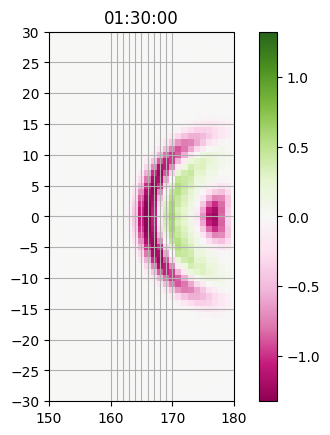

In [ ]:
ds = ds_low_top
# Plot the U850 horizontal slice at a given time index with grid lines
MyProj = ccrs.PlateCarree()

fig, ax = plt.subplots(subplot_kw={'projection': MyProj})

time_ind = 3

xmin, xmax = 150, 180
ymin, ymax = -30, 30

xtick_locs = np.linspace(xmin, xmax, 4)
gl_xtick_locs = (xmin, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, xmax)
ytick_locs = np.linspace(ymin, ymax, 13)

pcmesh = ax.pcolormesh(ds.lon,
                       ds.lat,
                       ds.U850[time_ind], transform=MyProj,
                       cmap='PiYG')
ax.set_extent(([xmin, xmax, ymin, ymax]), crs=MyProj)
ax.set_xticks(xtick_locs, crs=MyProj)
ax.set_yticks(ytick_locs, crs=MyProj)
ax.set_title(num2date(ds.time)[time_ind].strftime('%H:%M:%S'))
gl = ax.gridlines()
gl.xlocator = mticker.FixedLocator(gl_xtick_locs)
gl.ylocator = mticker.FixedLocator(ytick_locs)
plt.colorbar(pcmesh, ax=ax)

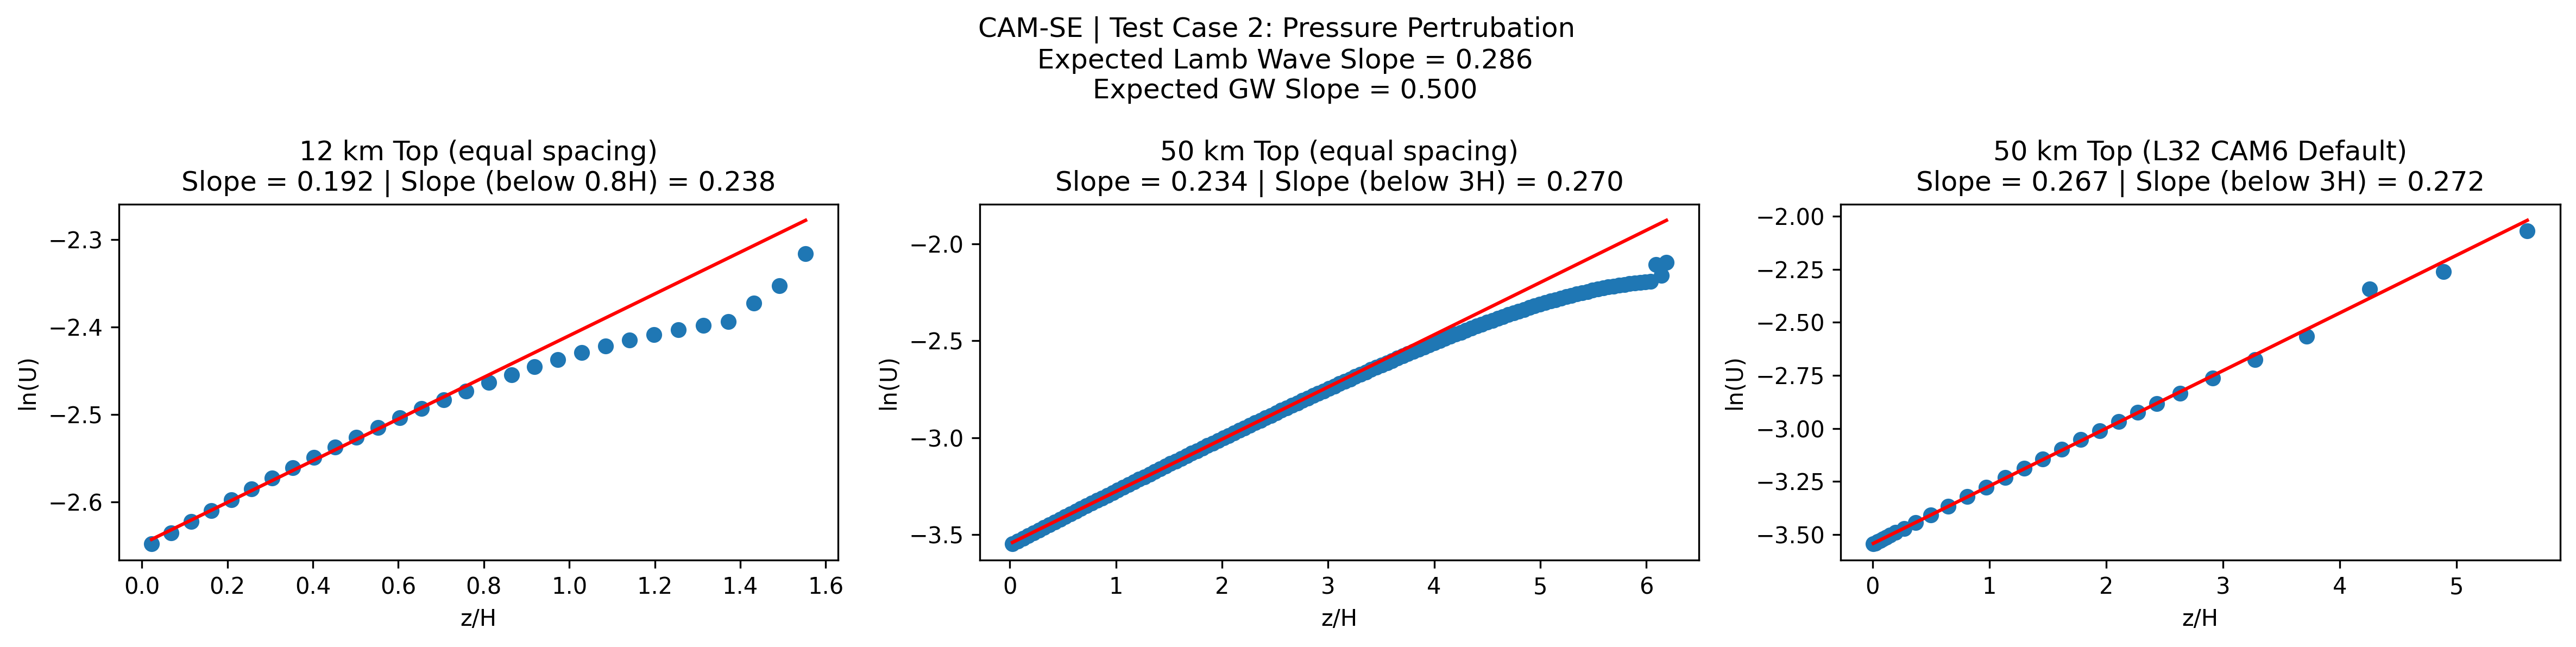

In [35]:
# Fit on full data
fig, axes = plt.subplots(1,3,figsize=(16,4),dpi=300)

T0 = 275
Rd = 287
g = 9.81

H = (Rd * T0) / g
time_ind = 3
lat_val = 0

#low top
lon_val = 163 # lon value ahead of first wavefront
X = ds_low_top.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_low_top.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=0.8], Y[X<=0.8], 1)
p_total = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], 'red')
axes[0].scatter(X, Y)
# print(p[0])
axes[0].set_title("12 km Top (equal spacing)\n"+f"Slope = {p_total[0]:.3f} | Slope (below 0.8H) = {p[0]:.3f}")


# 50 km top, uniform
lon_val = 160
X = ds_400m_50km.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_400m_50km.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=3.0], Y[X<=3.0], 1)
p_total = np.polyfit(X, Y, 1)

axes[1].plot(X, X * p[0] + p[1], 'red')
axes[1].scatter(X, Y)
# print(p[0])
axes[1].set_title("50 km Top (equal spacing)\n"+f"Slope = {p_total[0]:.3f} | Slope (below 3H) = {p[0]:.3f}")


# 50 km top, nonuniform
lon_val = 160
X = ds_high_top.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_high_top.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p_total = np.polyfit(X, Y, 1)
p = np.polyfit(X[X<=3.0], Y[X<=3.0], 1)
axes[2].plot(X, X * p[0] + p[1], 'red')
axes[2].scatter(X, Y)
# print(p[0])
axes[2].set_title("50 km Top (L32 CAM6 Default)\n"+f"Slope = {p_total[0]:.3f} | Slope (below 3H) = {p[0]:.3f}")


# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'CAM-SE | Test Case 2: Pressure Pertrubation \n Expected Lamb Wave Slope = {2.0/7.0:.3f}\n Expected GW Slope = {0.5:.3f}')
fig.tight_layout()
plt.show()

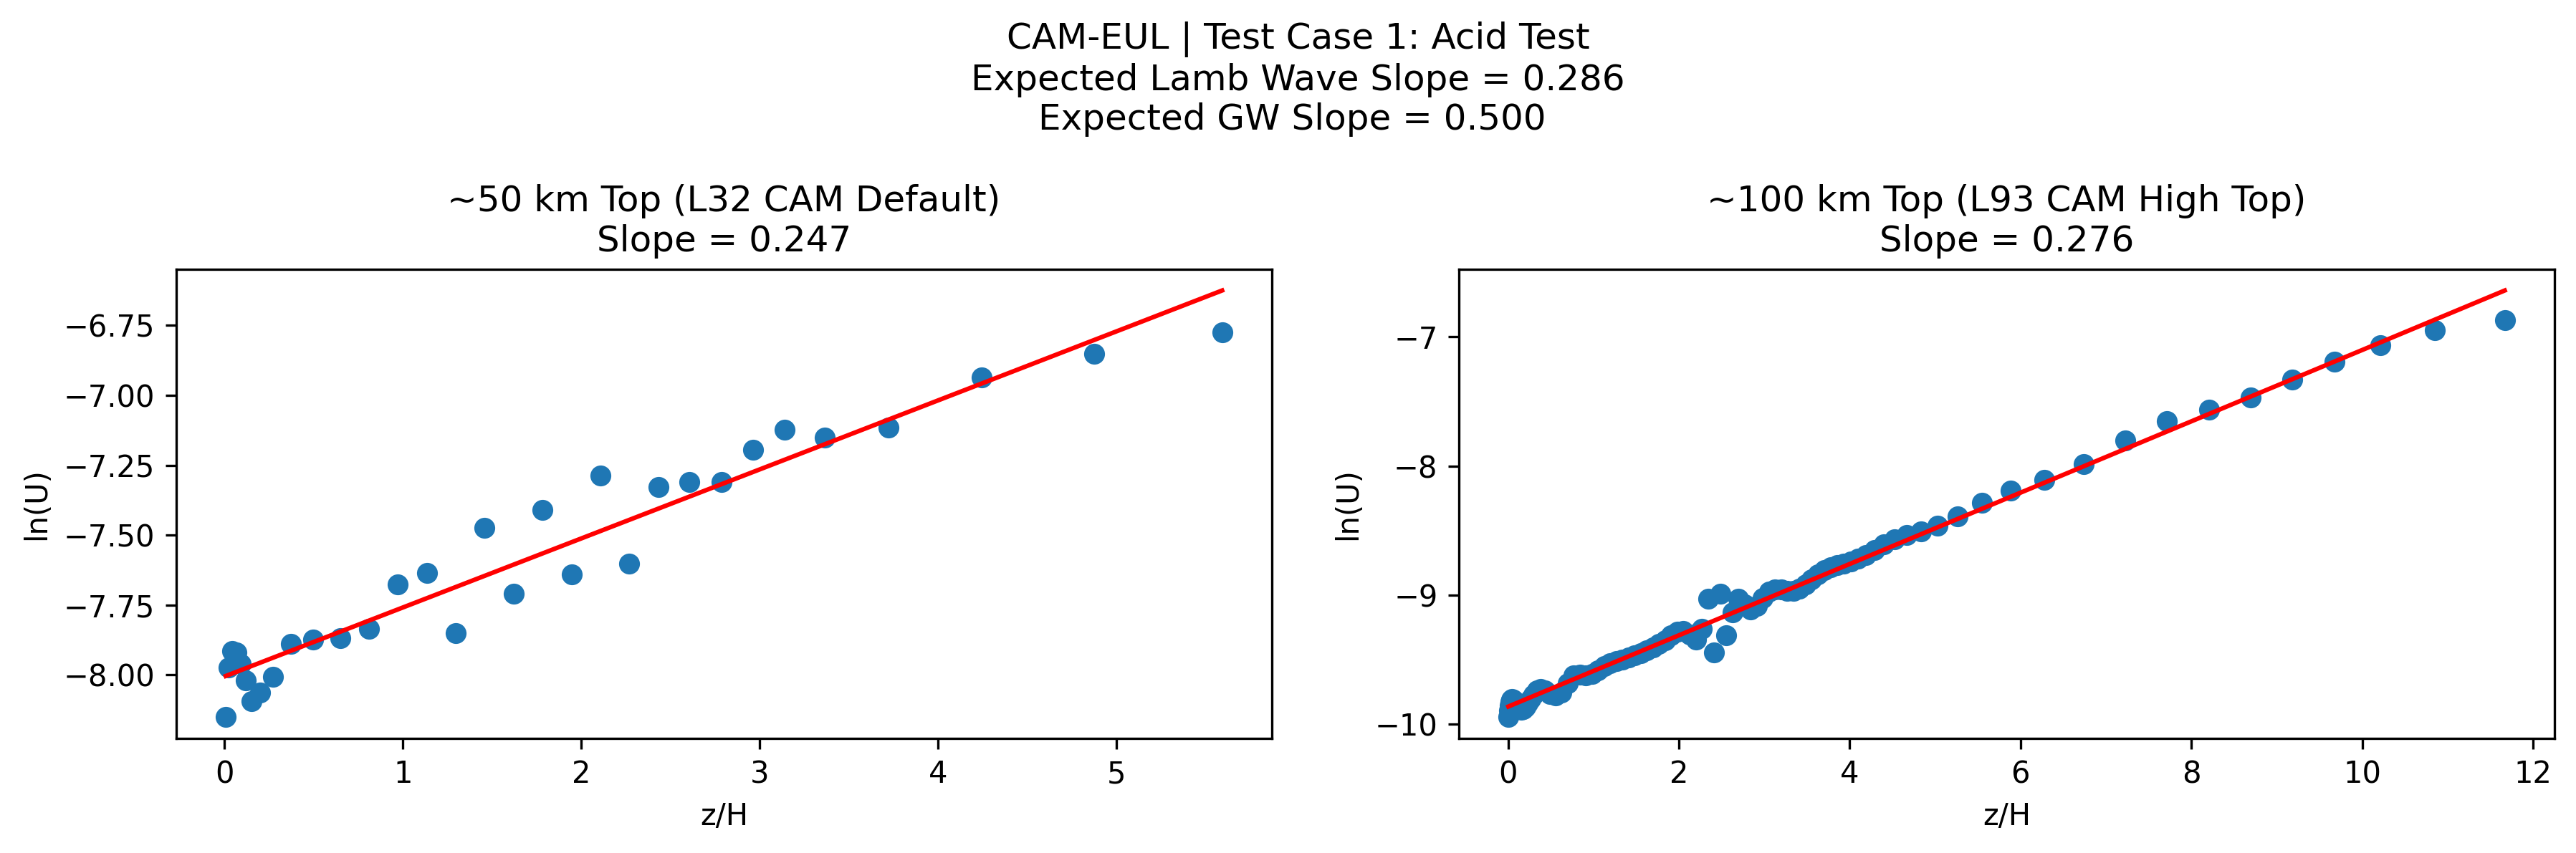

In [31]:
# Fit on full data
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 300
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 2
lat_val = 0

#50 km CAM default
lon_val = 50 # lon value ahead of first wavefront
X = ds_eul_L32_nodif.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_eul_L32_nodif.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], 'red')
axes[0].scatter(X, Y)
# print(p[0])
axes[0].set_title("~50 km Top (L32 CAM Default)\n"+f"Slope = {p[0]:.3f}")


# 100 km top, uniform
lon_val = 50
X = ds_eul_L93_nodif.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_eul_L93_nodif.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], 'red')
axes[1].scatter(X, Y)
# print(p[0])
axes[1].set_title("~100 km Top (L93 CAM High Top)\n"+f"Slope = {p[0]:.3f}")

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'CAM-EUL | Test Case 1: Acid Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

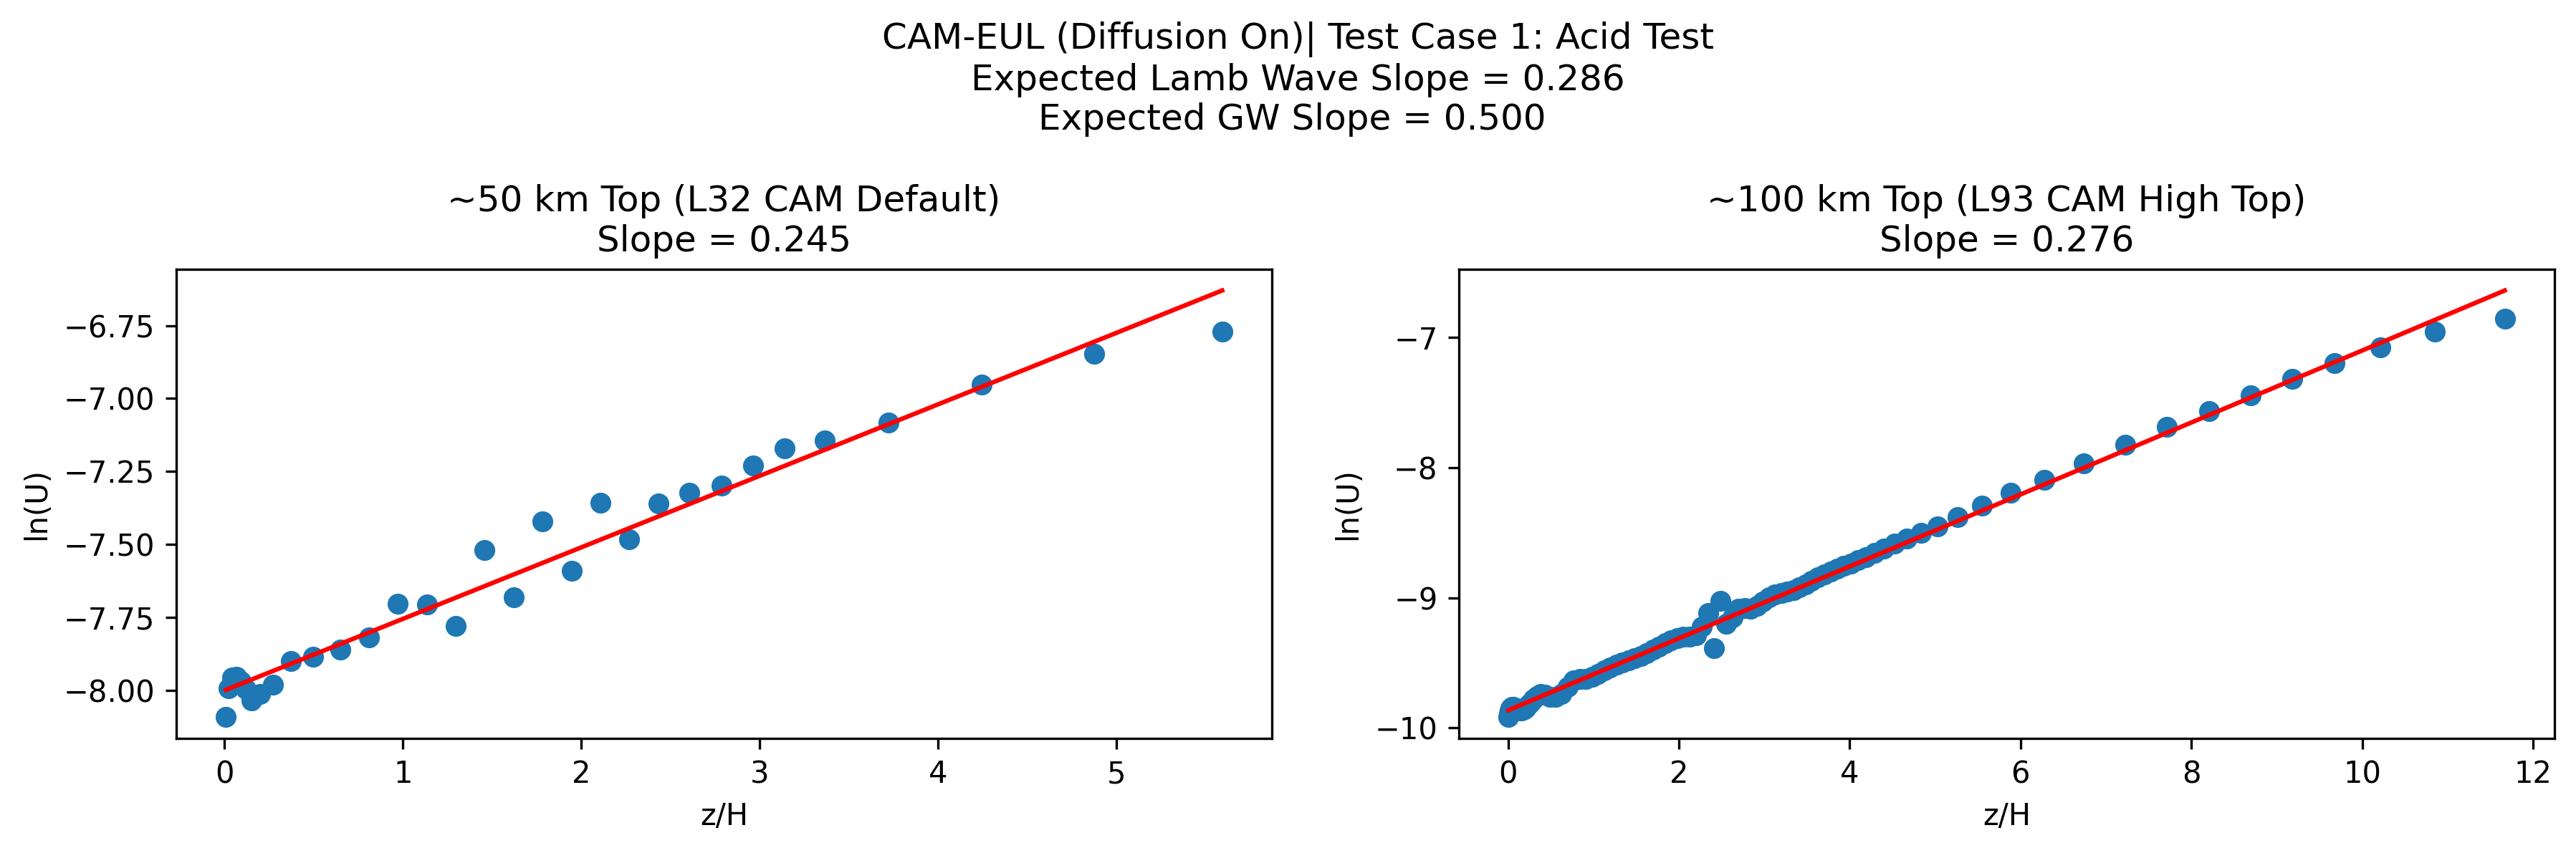

In [4]:
# Fit on full data
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 300
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 2
lat_val = 0

#50 km CAM default
lon_val = 50 # lon value ahead of first wavefront
X = ds_eul_L32_dif.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_eul_L32_dif.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], 'red')
axes[0].scatter(X, Y)
# print(p[0])
axes[0].set_title("~50 km Top (L32 CAM Default)\n"+f"Slope = {p[0]:.3f}")


# 100 km top, uniform
lon_val = 50
X = ds_eul_L93_dif.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_eul_L93_dif.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], 'red')
axes[1].scatter(X, Y)
# print(p[0])
axes[1].set_title("~100 km Top (L93 CAM High Top)\n"+f"Slope = {p[0]:.3f}")

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'CAM-EUL (Diffusion On)| Test Case 1: Acid Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

<xarray.DataArray 'time' ()> Size: 8B
array(0.375)
Coordinates:
    lat      float64 8B 0.0
    lon      float64 8B 180.0
    time     float64 8B 0.375
Attributes:
    long_name:  Model elapsed time
    units:      days


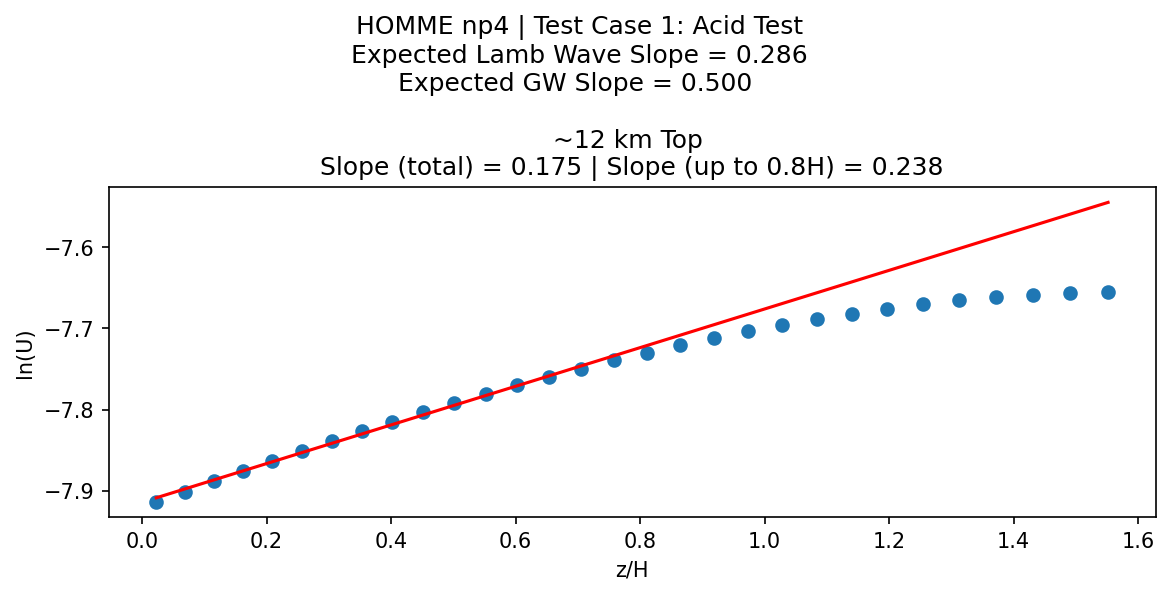

In [37]:
# Fit on full data
fig, axes = plt.subplots(1,1,figsize=(8,4),dpi=150)

T0 = 300
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 9
lat_val = 0

#50 km CAM default
lon_val = 180 # lon value ahead of first wavefront
print(ds_homme_np4.u[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest').time)
X = ds_homme_np4.geo[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H / g
Y = np.log(abs(ds_homme_np4.u[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p_total = np.polyfit(X, Y, 1)
p = np.polyfit(X[X<=0.8], Y[X<=0.8], 1)
axes.plot(X, X * p[0] + p[1], 'red')
axes.scatter(X, Y)
# print(p[0])
axes.set_title("~12 km Top \n"+f"Slope (total) = {p_total[0]:.3f}" + f" | Slope (up to 0.8H) = {p[0]:.3f}")

# plot
axes.set_ylabel('ln(U)')
axes.set_xlabel('z/H') 

fig.suptitle(f'HOMME np4 | Test Case 1: Acid Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

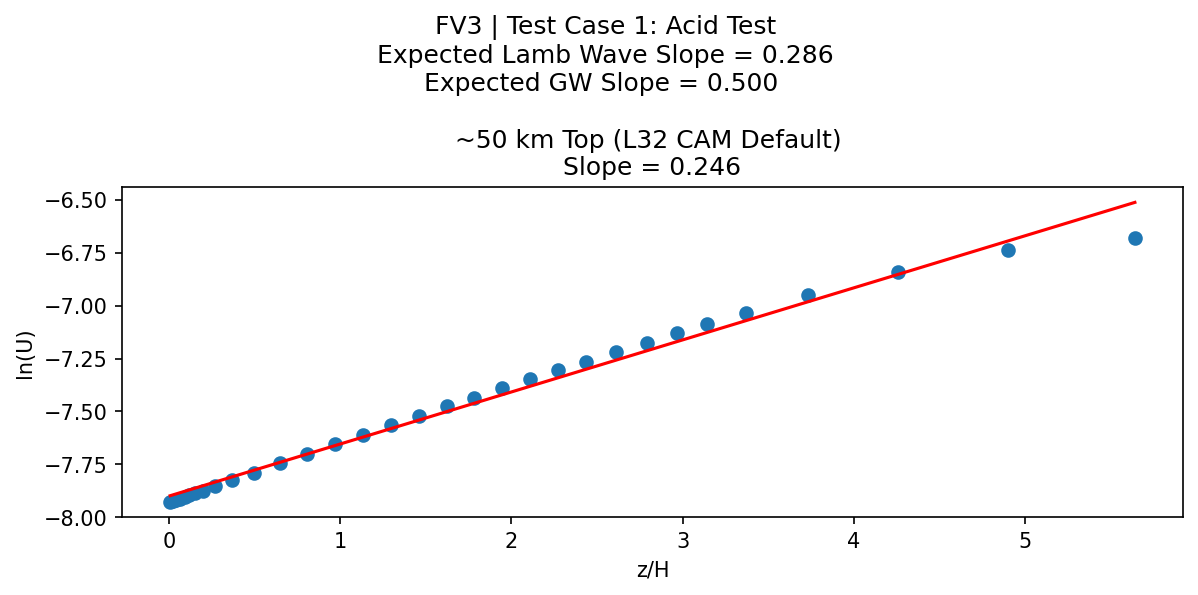

In [12]:
# Fit on full data
fig, axes = plt.subplots(1,1,figsize=(8,4),dpi=150)

T0 = 300.0
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 8
lat_val = 0

#50 km CAM default
lon_val = 180.0 # lon value ahead of first wavefront
X = ds_fv3_L32.Z3.isel(time=time_ind).sel(lat=lat_val, lon=lon_val, method='nearest') / H 
Y = np.log(abs(ds_fv3_L32.U.isel(time=time_ind).sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X, Y, 1)
axes.plot(X, X * p[0] + p[1], 'red')
axes.scatter(X, Y)
# print(p[0])
axes.set_title("~50 km Top (L32 CAM Default) \n"+f"Slope = {p[0]:.3f}")

# plot
axes.set_ylabel('ln(U)')
axes.set_xlabel('z/H') 

fig.suptitle(f'FV3 | Test Case 1: Acid Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

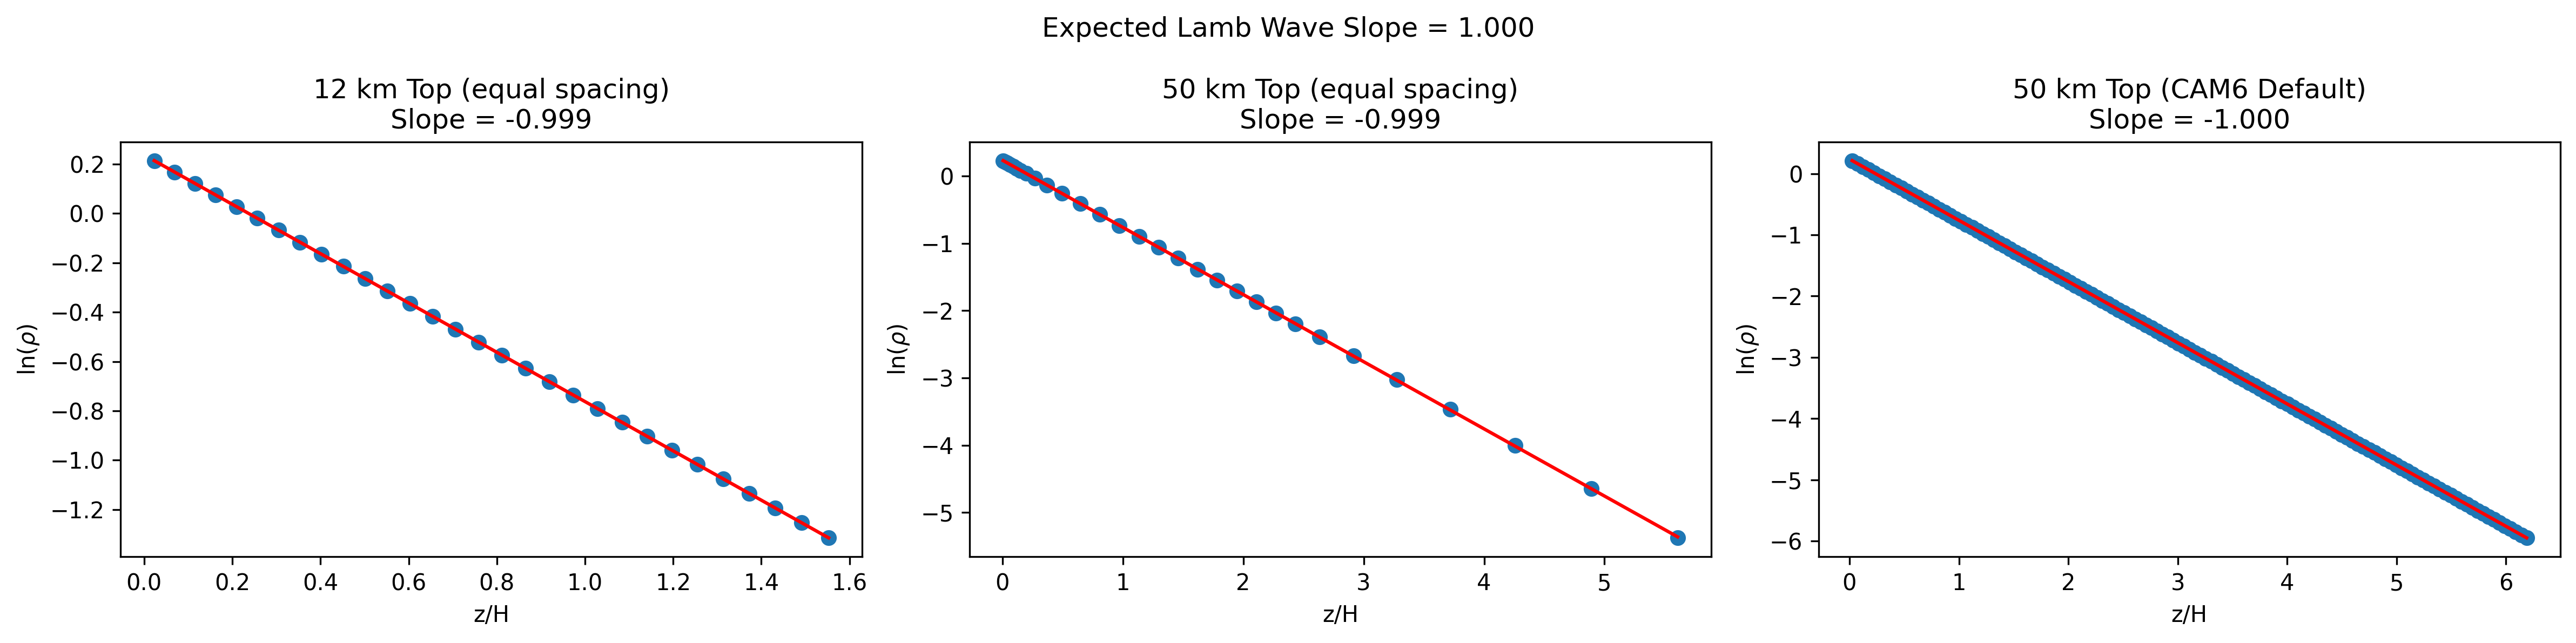

In [ ]:
# Density
fig, axes = plt.subplots(1,3,figsize=(16,4),dpi=300)

T0 = 275
Rd = 287
g = 9.81

H = (Rd * T0) / g
time_ind = 3
lat_val = 0

#low top
ds = ds_low_top.isel(time=time_ind).copy()

lon_val = 163 # lon value ahead of first wavefront
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds['hyam']*1.0e5+ds['hybm']*ds['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
rho = p/(Rd*ds['T'].sel(lat=lat_val, lon=lon_val, method='nearest'))
Y = np.log(abs(rho))
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], 'red')
axes[0].scatter(X, Y)
# print(p[0])
axes[0].set_title("12 km Top (equal spacing)\n"+f"Slope = {p[0]:.3f}")


# 50 km top, uniform
ds = ds_high_top.isel(time=time_ind).copy()

lon_val = 160
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds['hyam']*1.0e5+ds['hybm']*ds['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
rho = p/(Rd*ds['T'].sel(lat=lat_val, lon=lon_val, method='nearest'))
Y = np.log(abs(rho))
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], 'red')
axes[1].scatter(X, Y)
# print(p[0])
axes[1].set_title("50 km Top (equal spacing)\n"+f"Slope = {p[0]:.3f}")


# 50 km top, nonuniform
ds = ds_400m_50km.isel(time=time_ind).copy()

lon_val = 160
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds['hyam']*1.0e5+ds['hybm']*ds['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
rho = p/(Rd*ds['T'].sel(lat=lat_val, lon=lon_val, method='nearest'))
Y = np.log(abs(rho))
p = np.polyfit(X, Y, 1)
axes[2].plot(X, X * p[0] + p[1], 'red')
axes[2].scatter(X, Y)
# print(p[0])
axes[2].set_title("50 km Top (CAM6 Default)\n"+f"Slope = {p[0]:.3f}")


# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel(r'ln($\rho$)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'Expected Lamb Wave Slope = {-1.0:.3f}')
fig.tight_layout()
plt.show()

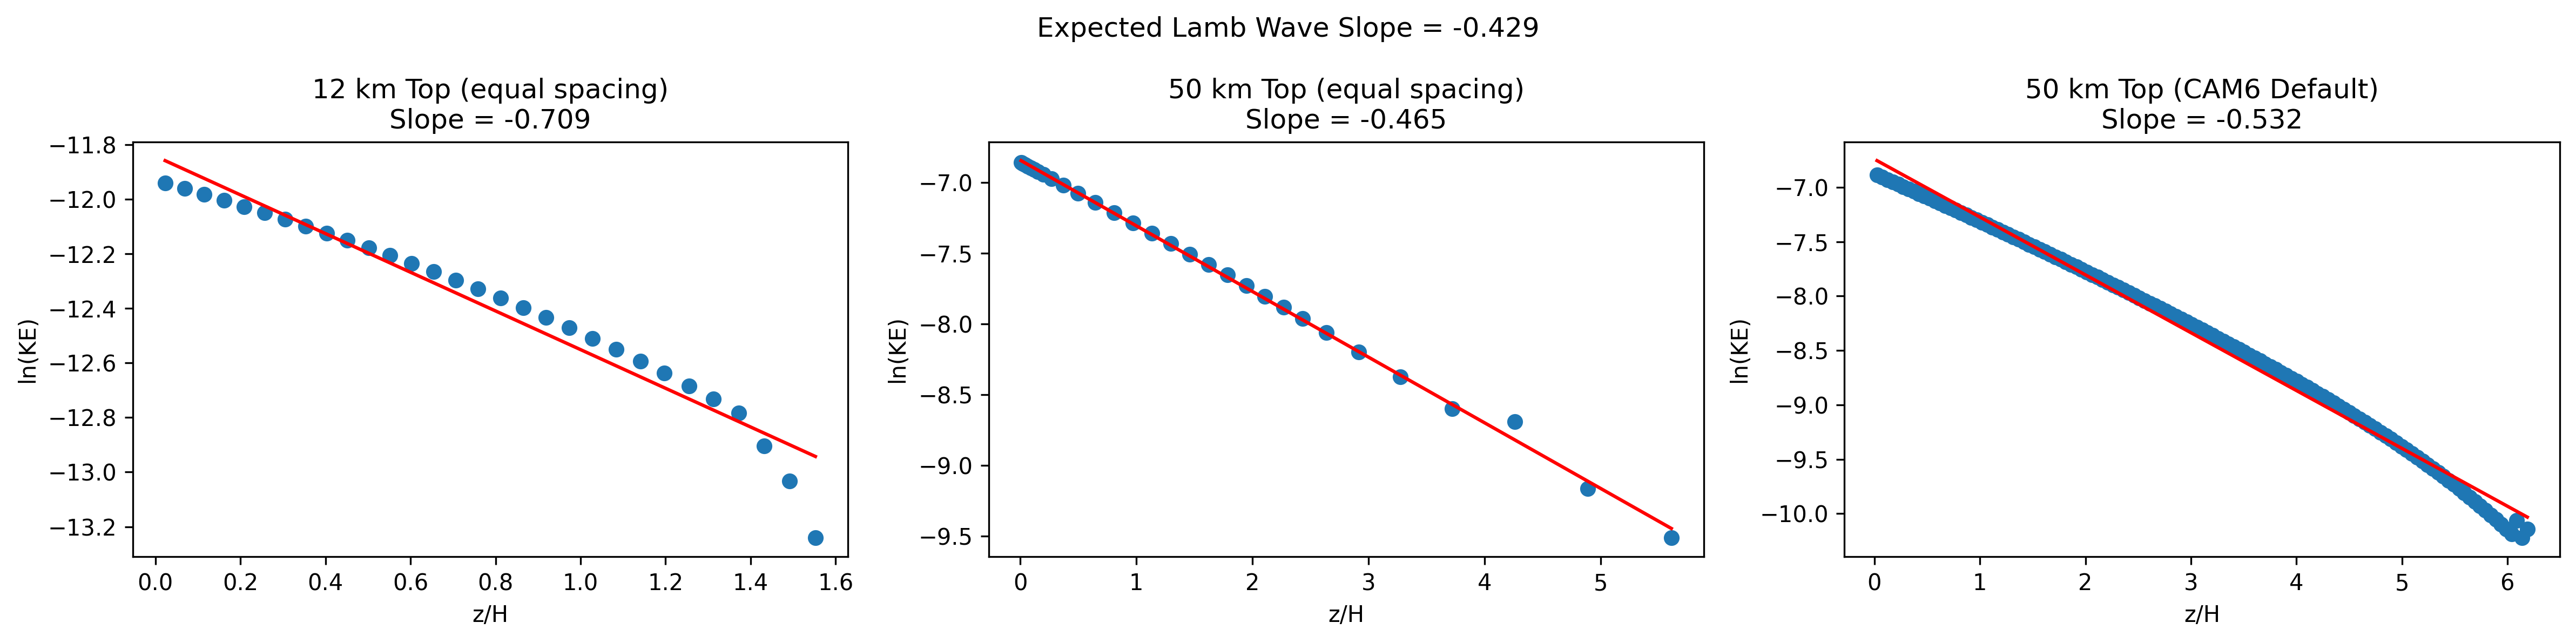

In [48]:
# Kinetic Energy: rho * u^2
fig, axes = plt.subplots(1,3,figsize=(16,4),dpi=300)

T0 = 275
Rd = 287
g = 9.81

H = (Rd * T0) / g
time_ind = 3
lat_val = 0

#low top
ds = ds_low_top.isel(time=time_ind).copy()
ds0 = ds_low_top.isel(time=0).copy()


lon_vals = 163 # lon value ahead of first wavefront
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds0['hyam']*1.0e5+ds0['hybm']*ds0['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
rho = p/(Rd*ds0['T'].sel(lat=lat_val, lon=lon_val, method='nearest'))
U = ds['U'].sel(lat=lat_val, lon=lon_val, method='nearest')
KE = rho*U**2

Y = np.log(abs(KE))
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], 'red')
axes[0].scatter(X, Y)
# print(p[0])
axes[0].set_title("12 km Top (equal spacing)\n"+f"Slope = {p[0]:.3f}")


# 50 km top, uniform
ds = ds_high_top.isel(time=time_ind).copy()
ds0 = ds_high_top.isel(time=0).copy()


lon_val = 160
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds0['hyam']*1.0e5+ds0['hybm']*ds0['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
rho = p/(Rd*ds0['T'].sel(lat=lat_val, lon=lon_val, method='nearest'))
U = ds['U'].sel(lat=lat_val, lon=lon_val, method='nearest')
KE = rho*U**2

Y = np.log(abs(KE))
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], 'red')
axes[1].scatter(X, Y)
# print(p[0])
axes[1].set_title("50 km Top (equal spacing)\n"+f"Slope = {p[0]:.3f}")


# 50 km top, nonuniform
ds = ds_400m_50km.isel(time=time_ind).copy()
ds0 = ds_400m_50km.isel(time=0).copy()


lon_val = 160
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds0['hyam']*1.0e5+ds0['hybm']*ds0['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
rho = p/(Rd*ds0['T'].sel(lat=lat_val, lon=lon_val, method='nearest'))
U = ds['U'].sel(lat=lat_val, lon=lon_val, method='nearest')
KE = rho*U**2

Y = np.log(abs(KE))
p = np.polyfit(X, Y, 1)
axes[2].plot(X, X * p[0] + p[1], 'red')
axes[2].scatter(X, Y)
# print(p[0])
axes[2].set_title("50 km Top (CAM6 Default)\n"+f"Slope = {p[0]:.3f}")


# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel(r'ln(KE)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'Expected Lamb Wave Slope = {-3.0/7.0:.3f}')
fig.tight_layout()
plt.show()

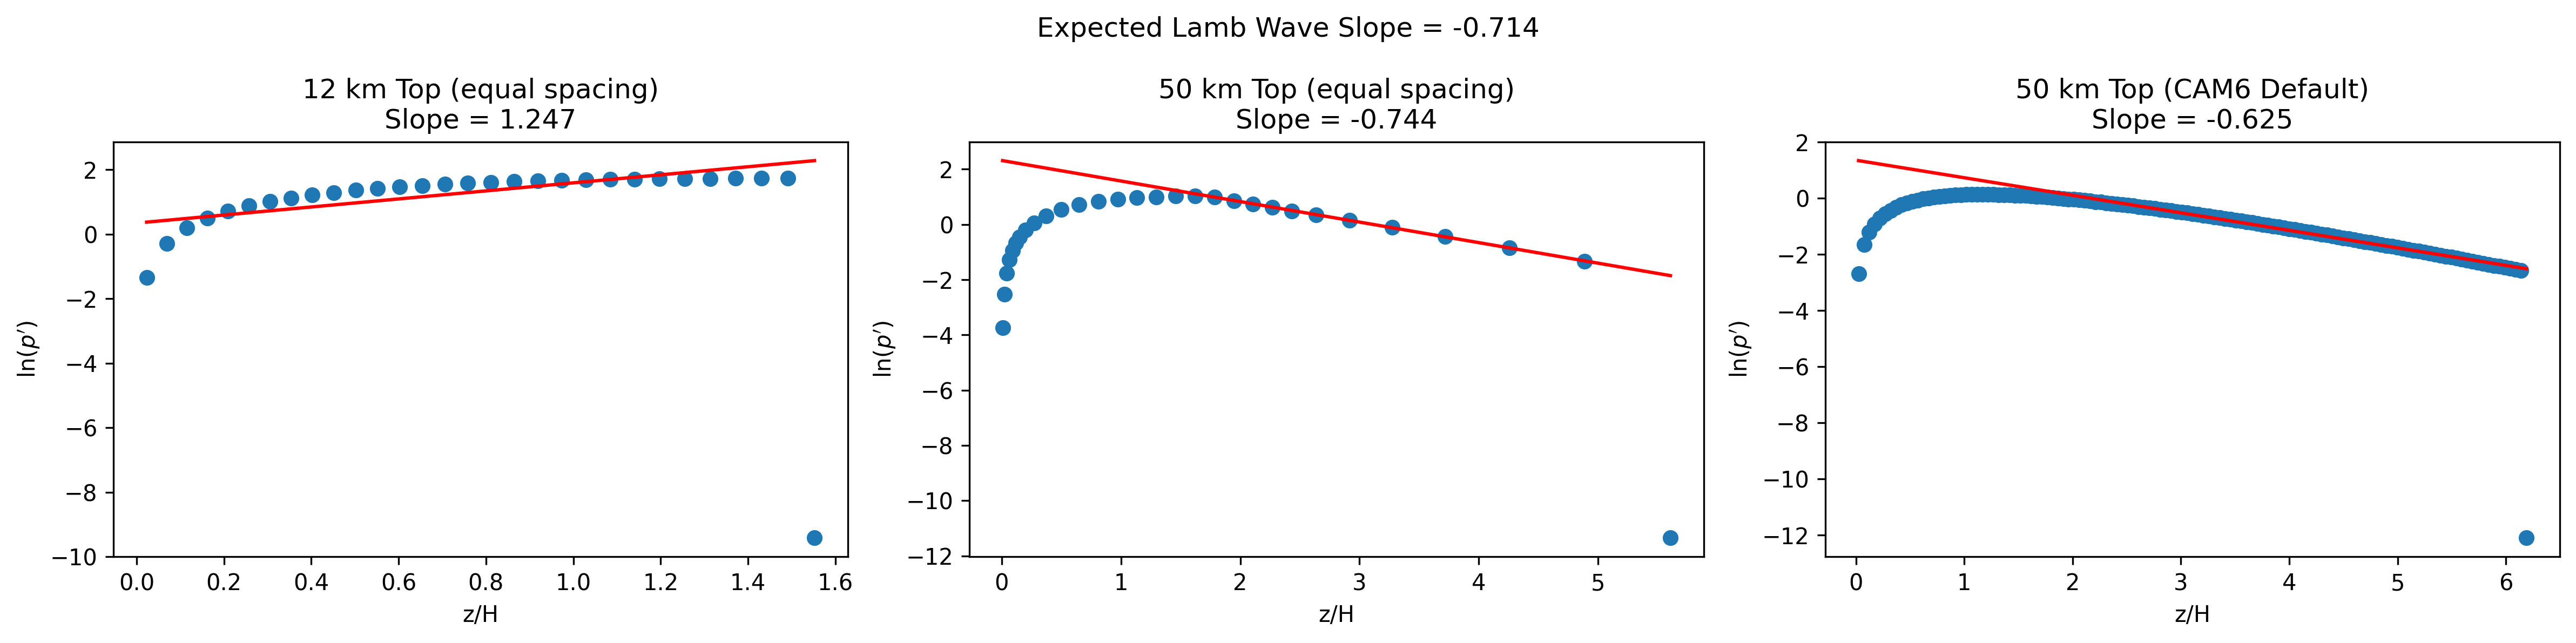

In [37]:
# pressure
fig, axes = plt.subplots(1,3,figsize=(16,4),dpi=300)

T0 = 275
Rd = 287
g = 9.81

H = (Rd * T0) / g
time_ind = 3
lat_val = 0

#low top
ds = ds_low_top.isel(time=time_ind).copy()
ds0 = ds_low_top.isel(time=0).copy()

lon_val = 163 # lon value ahead of first wavefront
X0 = ds0.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds['hyam']*1.0e5+ds['hybm']*ds['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
p0 = (ds0['hyam']*1.0e5+ds0['hybm']*ds0['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')

# interpolate p onto initial Z3 values
p_interp = np.zeros_like(X0)

for k in range(0,len(X0)):
    p_interp[k] = np.exp(np.interp(X[k],X0[::-1],np.log(p0[::-1])))
p_pert = p_interp - p0
# print(p_pert)
Y = np.log(abs(p_pert))
p = np.polyfit(X0[1:], Y[1:], 1)
axes[0].plot(X0, X0 * p[0] + p[1], 'red')
axes[0].scatter(X0, Y)
# print(p[0])
axes[0].set_title("12 km Top (equal spacing)\n"+f"Slope = {p[0]:.3f}")


# 50 km top, uniform
ds = ds_high_top.isel(time=time_ind).copy()
ds0 = ds_high_top.isel(time=0).copy()


lon_val = 160
X0 = ds0.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds['hyam']*1.0e5+ds['hybm']*ds['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
p0 = (ds0['hyam']*1.0e5+ds0['hybm']*ds0['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')

# interpolate p onto initial Z3 values
p_interp = np.zeros_like(X0)
for k in range(0,len(X0)):
    p_interp[k] = np.exp(np.interp(X[k],X0[::-1],np.log(p0[::-1])))

p_pert = p_interp - p0
Y = np.log(abs(p_pert))
p = np.polyfit(X0[1:][X0[1:]>2.0], Y[1:][X0[1:]>2.0], 1)
axes[1].plot(X0, X0 * p[0] + p[1], 'red')
axes[1].scatter(X0, Y)
# print(p[0])
axes[1].set_title("50 km Top (equal spacing)\n"+f"Slope = {p[0]:.3f}")


# 50 km top, nonuniform
ds = ds_400m_50km.isel(time=time_ind).copy()
ds0 = ds_400m_50km.isel(time=0).copy()

lon_val = 160
X0 = ds0.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds['hyam']*1.0e5+ds['hybm']*ds['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
p0 = (ds0['hyam']*1.0e5+ds0['hybm']*ds0['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')

# interpolate p onto initial Z3 values
p_interp = np.zeros_like(X0)
for k in range(0,len(X0)):
    p_interp[k] = np.exp(np.interp(X[k],X0[::-1],np.log(p0[::-1])))
p_pert = p_interp - p0
Y = np.log(abs(p_pert))
p = np.polyfit(X0[1:][X0[1:]>2.0], Y[1:][X0[1:]>2.0], 1)
axes[2].plot(X0, X0 * p[0] + p[1], 'red')
axes[2].scatter(X0, Y)
# print(p[0])
axes[2].set_title("50 km Top (CAM6 Default)\n"+f"Slope = {p[0]:.3f}")


# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel(r"ln($p'$)")
    ax.set_xlabel('z/H') 
    # ax.set_xlim((0,1.5))

fig.suptitle(f'Expected Lamb Wave Slope = {-5.0/7.0:.3f}')
fig.tight_layout()
plt.show()

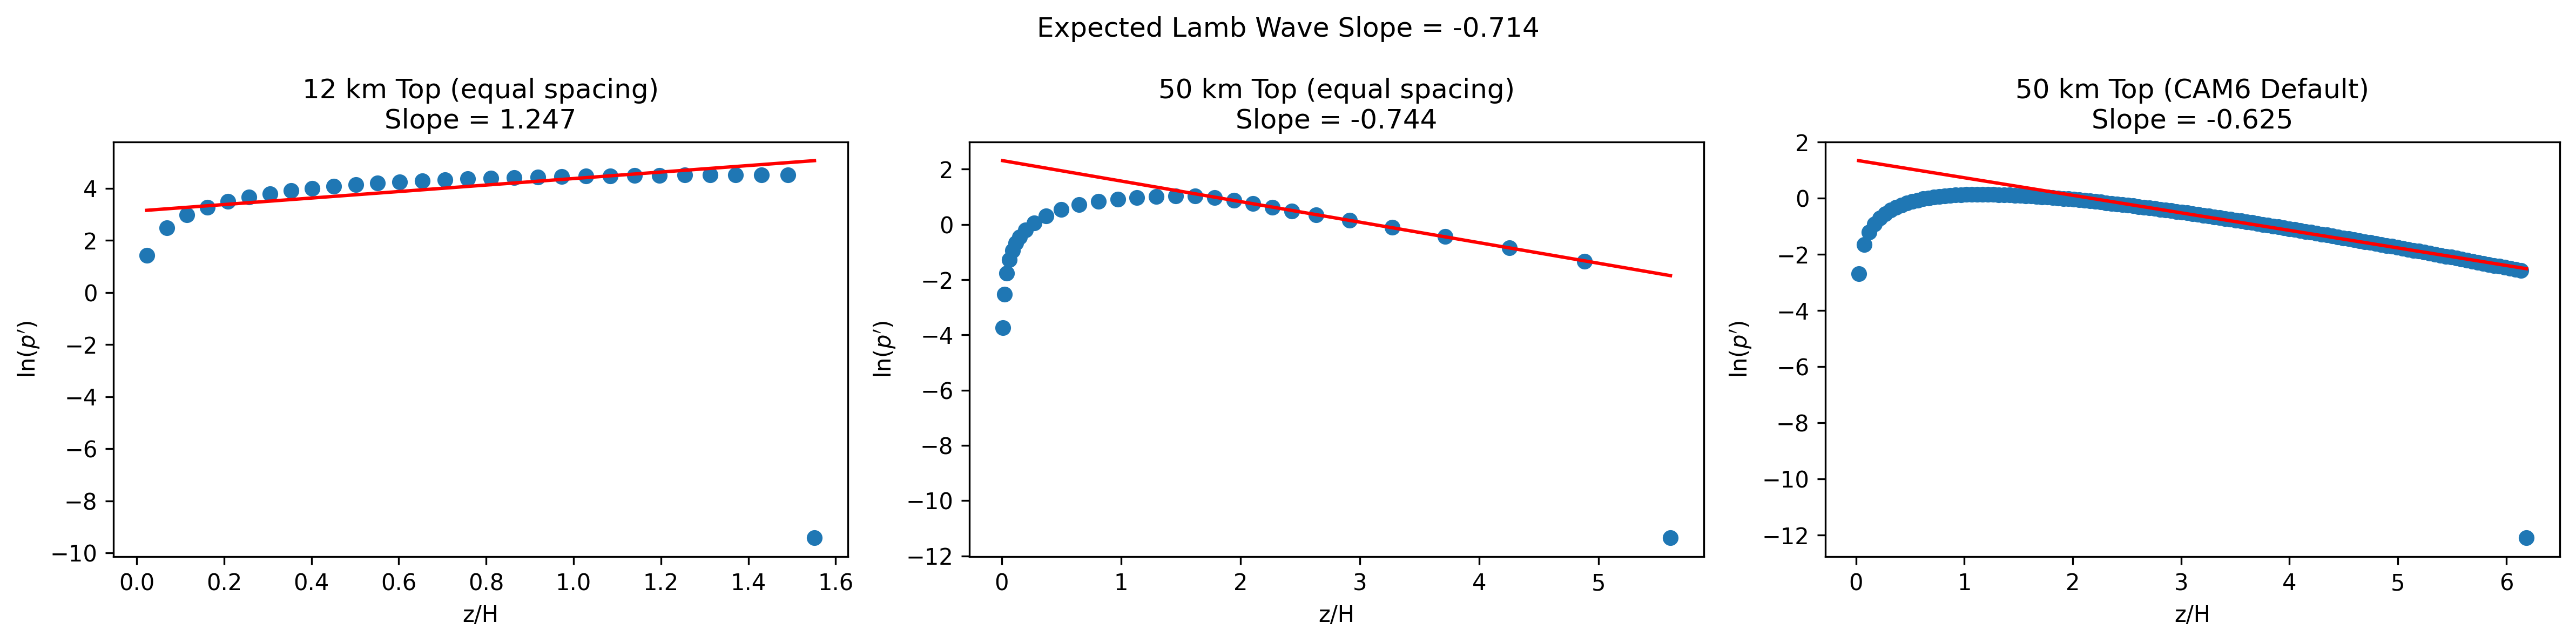

In [51]:
# pressure
fig, axes = plt.subplots(1,3,figsize=(16,4),dpi=300)

T0 = 275
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 3
lat_val = 0

#low top
ds = ds_low_top.isel(time=time_ind).copy()
ds0 = ds_low_top.isel(time=0).copy()

lon_val = 165 # lon value ahead of first wavefront
X0 = ds0.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds['hyam']*1.0e5+ds['hybm']*ds['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
p0 = (ds0['hyam']*1.0e5+ds0['hybm']*ds0['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')

# interpolate p onto initial Z3 values
p_interp = np.zeros_like(X0)

for k in range(0,len(X0)):
    p_interp[k] = np.exp(np.interp(X[k],X0[::-1],np.log(p0[::-1])))
p_pert = p_interp - p0
# print(p_pert)
Y = np.log(abs(p_pert))
p = np.polyfit(X0[1:], Y[1:], 1)
axes[0].plot(X0, X0 * p[0] + p[1], 'red')
axes[0].scatter(X0, Y)
# print(p[0])
axes[0].set_title("12 km Top (equal spacing)\n"+f"Slope = {p[0]:.3f}")


# 50 km top, uniform
ds = ds_high_top.isel(time=time_ind).copy()
ds0 = ds_high_top.isel(time=0).copy()


lon_val = 160
X0 = ds0.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds['hyam']*1.0e5+ds['hybm']*ds['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
p0 = (ds0['hyam']*1.0e5+ds0['hybm']*ds0['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')

# interpolate p onto initial Z3 values
p_interp = np.zeros_like(X0)
for k in range(0,len(X0)):
    p_interp[k] = np.exp(np.interp(X[k],X0[::-1],np.log(p0[::-1])))

p_pert = p_interp - p0
Y = np.log(abs(p_pert))
p = np.polyfit(X0[1:][X0[1:]>2.0], Y[1:][X0[1:]>2.0], 1)
axes[1].plot(X0, X0 * p[0] + p[1], 'red')
axes[1].scatter(X0, Y)
# print(p[0])
axes[1].set_title("50 km Top (equal spacing)\n"+f"Slope = {p[0]:.3f}")


# 50 km top, nonuniform
ds = ds_400m_50km.isel(time=time_ind).copy()
ds0 = ds_400m_50km.isel(time=0).copy()

lon_val = 160
X0 = ds0.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
X = ds.Z3.sel(lat=lat_val, lon=lon_val, method='nearest') / H
p = (ds['hyam']*1.0e5+ds['hybm']*ds['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')
p0 = (ds0['hyam']*1.0e5+ds0['hybm']*ds0['PS']).sel(lat=lat_val, lon=lon_val, method='nearest')

# interpolate p onto initial Z3 values
p_interp = np.zeros_like(X0)
for k in range(0,len(X0)):
    p_interp[k] = np.exp(np.interp(X[k],X0[::-1],np.log(p0[::-1])))
p_pert = p_interp - p0
Y = np.log(abs(p_pert))
p = np.polyfit(X0[1:][X0[1:]>2.0], Y[1:][X0[1:]>2.0], 1)
axes[2].plot(X0, X0 * p[0] + p[1], 'red')
axes[2].scatter(X0, Y)
# print(p[0])
axes[2].set_title("50 km Top (CAM6 Default)\n"+f"Slope = {p[0]:.3f}")


# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel(r"ln($p'$)")
    ax.set_xlabel('z/H') 
    # ax.set_xlim((0,1.5))

fig.suptitle(f'Expected Lamb Wave Slope = {-5.0/7.0:.3f}')
fig.tight_layout()
plt.show()

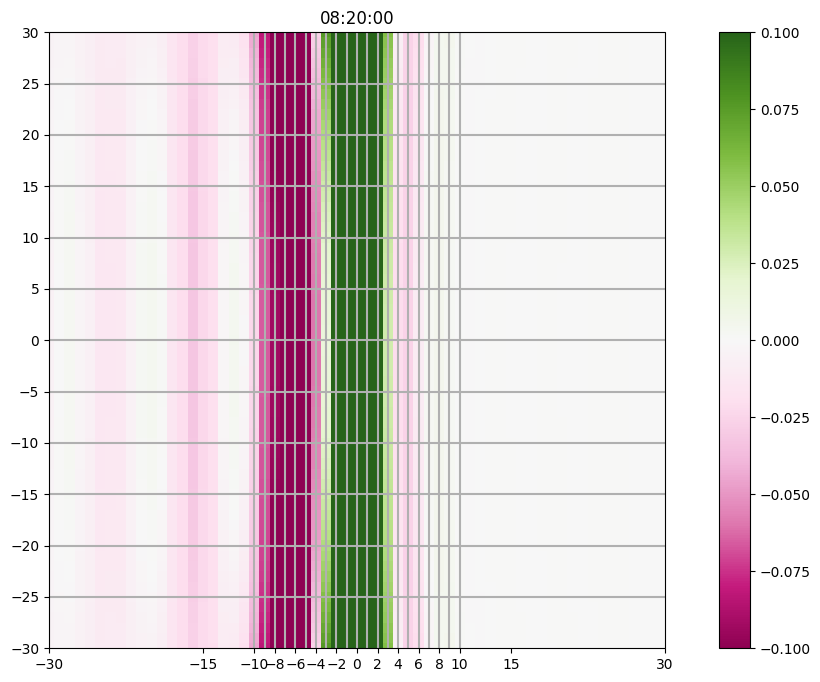

In [ ]:
ds = ds_se_L58_pressure
# Plot the U850 horizontal slice at a given time index with grid lines
MyProj = ccrs.PlateCarree()

fig, ax = plt.subplots(subplot_kw={'projection': MyProj},figsize=(14,8))

time_ind = 50

# xmin, xmax = 90-180, 270-180
xmin, xmax = -30, 30
ymin, ymax = -30, 30

xtick_locs = (xmin, xmin/2, *np.arange(-10,10+2,2), xmax/2,xmax)
gl_xtick_locs = (xmin, *np.arange(-10,10+1,1), xmax)
ytick_locs = np.linspace(ymin, ymax, 13)

pcmesh = ax.pcolormesh(ds.lon,
                       ds.lat,
                       ds.U850[time_ind], transform=MyProj,
                       cmap='PiYG',
                       vmin=-0.1,vmax=0.1) #pressure
                    #    vmin=-1.0e-4,vmax=1.0e-4)#acid
ax.set_extent(([xmin, xmax, ymin, ymax]), crs=MyProj)
ax.set_xticks(xtick_locs, crs=MyProj)
ax.set_yticks(ytick_locs, crs=MyProj)
ax.set_title(num2date(ds.time)[time_ind].strftime('%H:%M:%S'))
gl = ax.gridlines(lw=1.5)
gl.xlocator = mticker.FixedLocator(gl_xtick_locs)
gl.ylocator = mticker.FixedLocator(ytick_locs)
plt.colorbar(pcmesh, ax=ax)

plt.show()

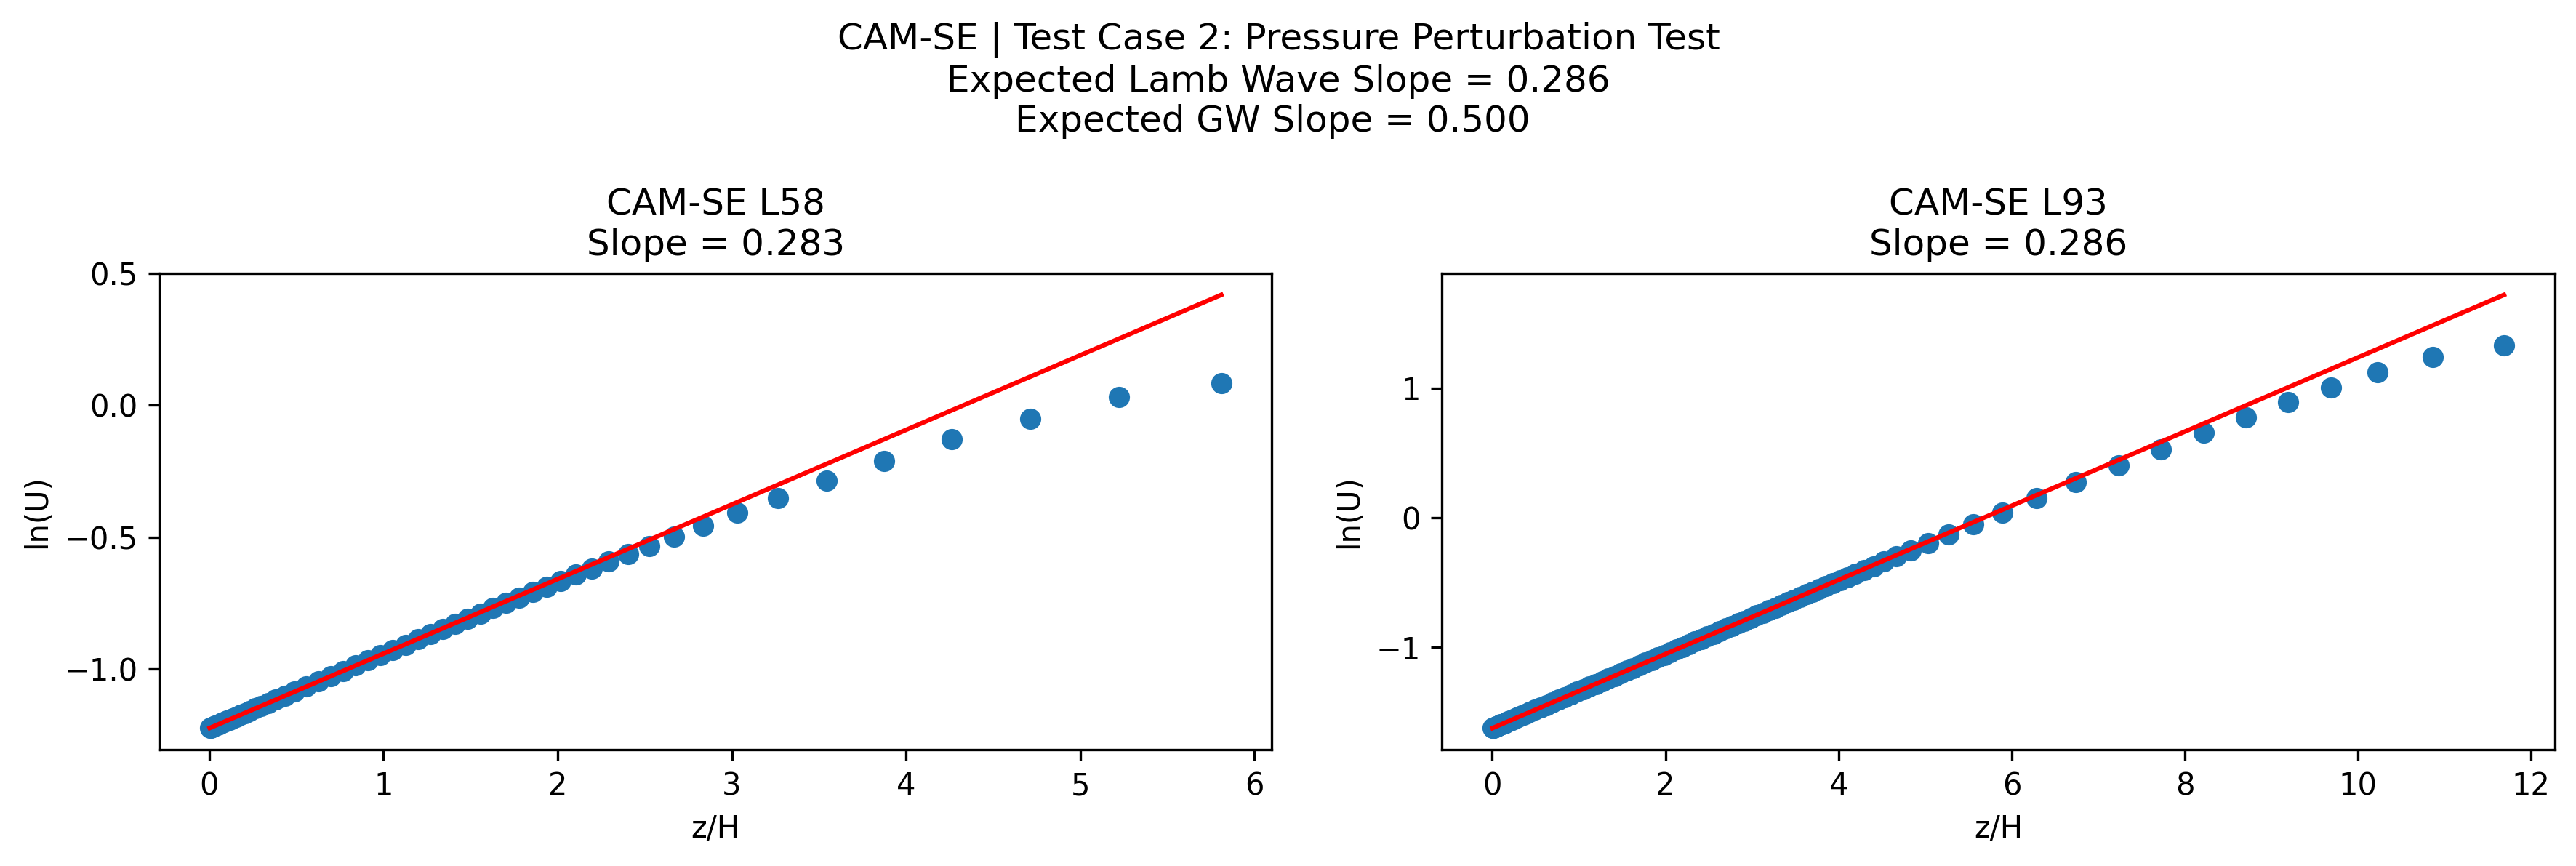

In [ ]:
# Fit on full data
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 275.0
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 50
lat_val = 0

color='dodgerblue'

#50 km CAM default
lon_val = 0 # lon value ahead of first wavefront
X = ds_se_L58_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_se_L58_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[0].plot(X, X * p[0] + p[1], color=color)
axes[0].scatter(X, Y, color=color)
# print(p[0])
axes[0].set_title("CAM-SE L58\n"+f"Slope = {p[0]:.3f}")


# 100 km top, uniform
lon_val = 0
X = ds_se_L93_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_se_L93_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[1].plot(X, X * p[0] + p[1], color=color)
axes[1].scatter(X, Y, color=color)
# print(p[0])
axes[1].set_title("CAM-SE L93\n"+f"Slope = {p[0]:.3f}")

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'CAM-SE | Test Case 2: Pressure Perturbation Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

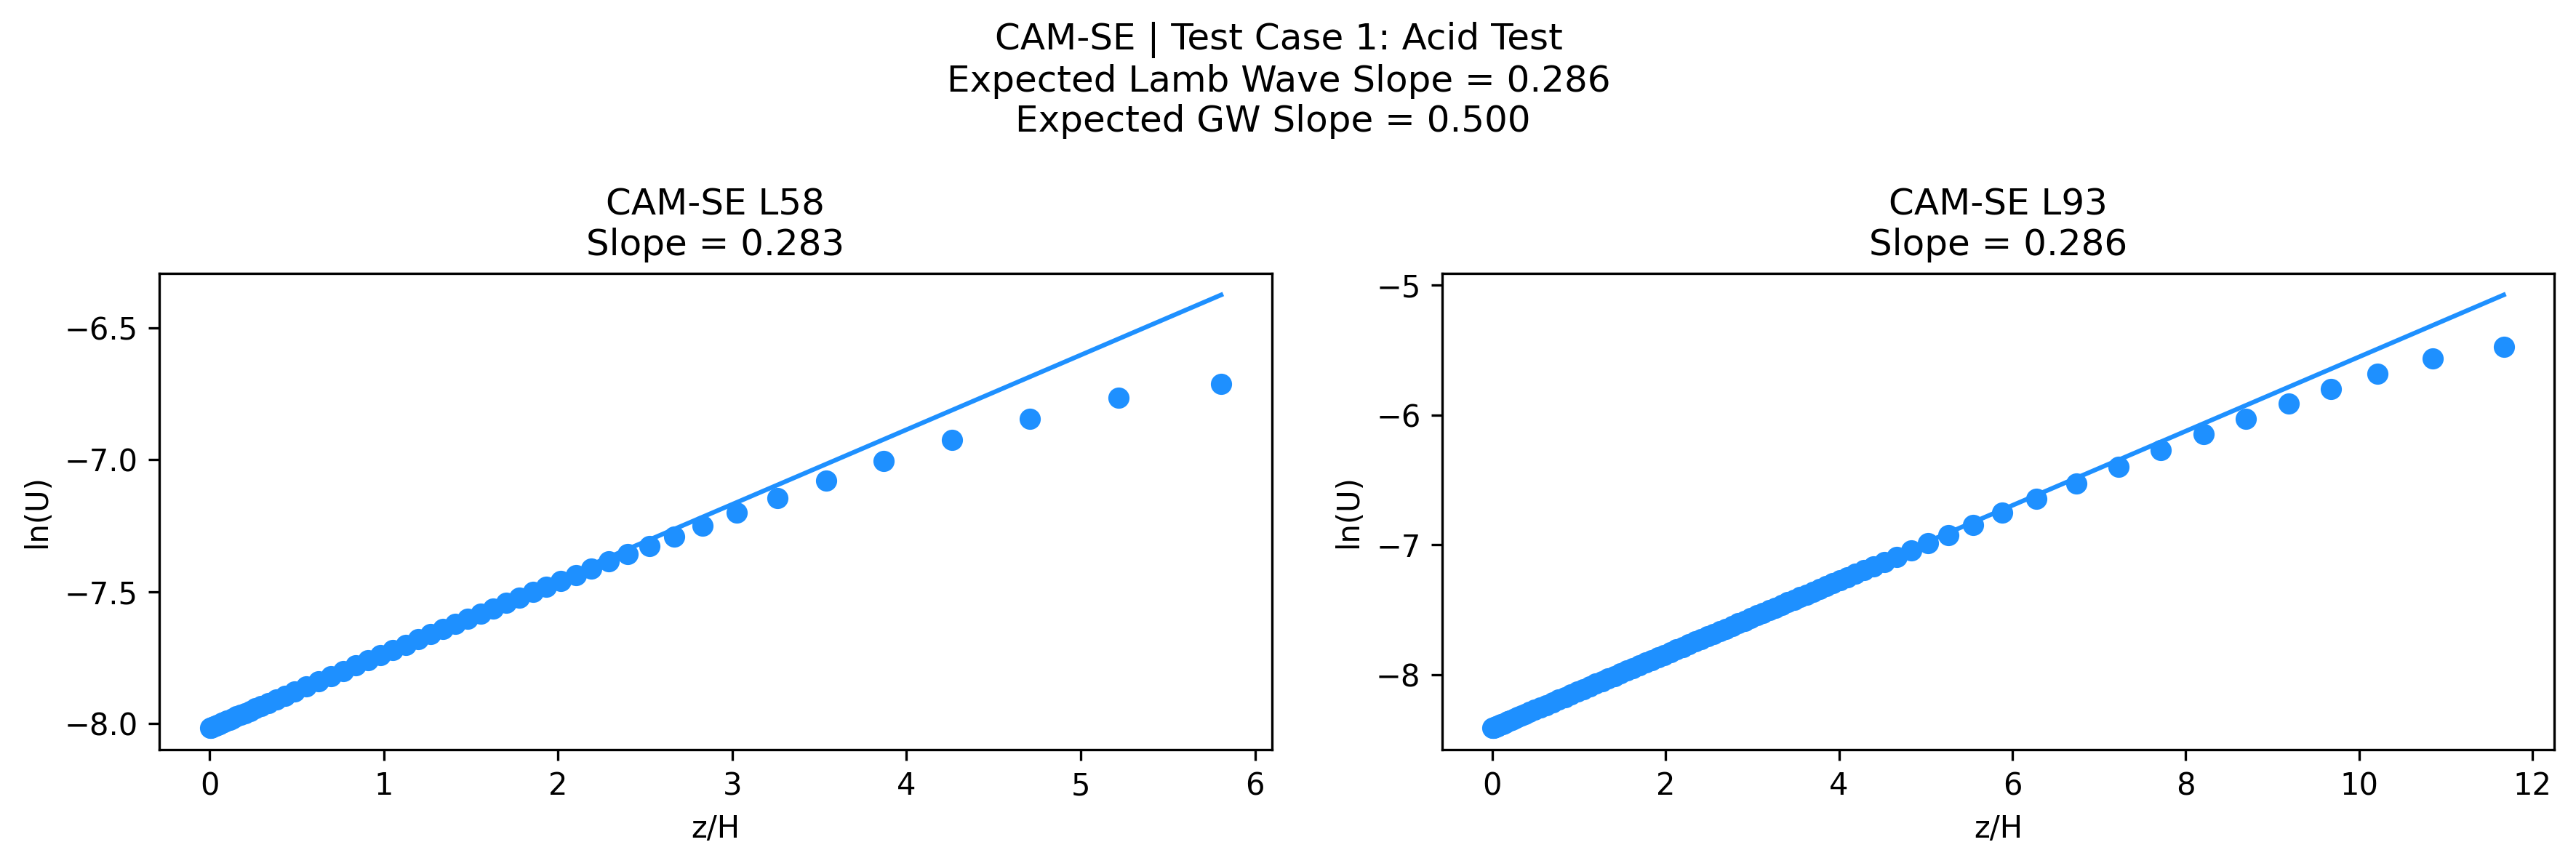

In [22]:
# Fit on full data
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 275.0
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 50
lat_val = 0
color='dodgerblue'

#50 km CAM default
lon_val = 0 # lon value ahead of first wavefront
X = ds_se_L58_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_se_L58_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[0].plot(X, X * p[0] + p[1], color=color)
axes[0].scatter(X, Y, color=color)
# print(p[0])
axes[0].set_title("CAM-SE L58\n"+f"Slope = {p[0]:.3f}")


# 100 km top, uniform
lon_val = 0 # if I use 5 then the amplitudes match better
X = ds_se_L93_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_se_L93_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[1].plot(X, X * p[0] + p[1], color=color)
axes[1].scatter(X, Y, color=color)
# print(p[0])
axes[1].set_title("CAM-SE L93\n"+f"Slope = {p[0]:.3f}")

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'CAM-SE | Test Case 1: Acid Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

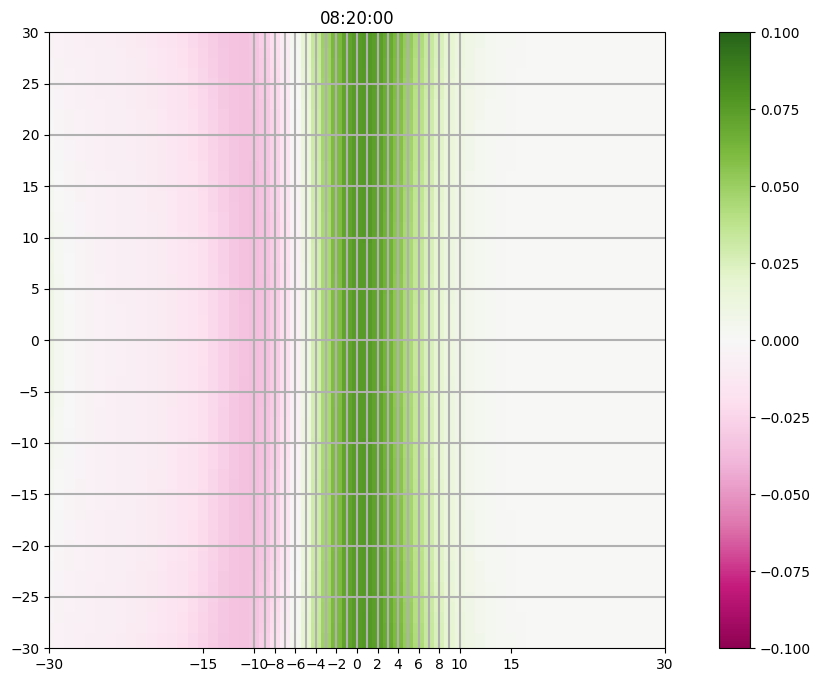

In [11]:
ds = ds_fv3_L58_pressure
# Plot the U850 horizontal slice at a given time index with grid lines
MyProj = ccrs.PlateCarree()

fig, ax = plt.subplots(subplot_kw={'projection': MyProj},figsize=(14,8))

time_ind = 50

# xmin, xmax = 90-180, 270-180
xmin, xmax = -30, 30
ymin, ymax = -30, 30

xtick_locs = (xmin, xmin/2, *np.arange(-10,10+2,2), xmax/2,xmax)
gl_xtick_locs = (xmin, *np.arange(-10,10+1,1), xmax)
ytick_locs = np.linspace(ymin, ymax, 13)

pcmesh = ax.pcolormesh(ds.lon,
                       ds.lat,
                       ds.U850[time_ind], transform=MyProj,
                       cmap='PiYG',
                       vmin=-0.1,vmax=0.1) #pressure
                    #    vmin=-1.0e-4,vmax=1.0e-4)#acid
ax.set_extent(([xmin, xmax, ymin, ymax]), crs=MyProj)
ax.set_xticks(xtick_locs, crs=MyProj)
ax.set_yticks(ytick_locs, crs=MyProj)
ax.set_title(num2date(ds.time)[time_ind].strftime('%H:%M:%S'))
gl = ax.gridlines(lw=1.5)
gl.xlocator = mticker.FixedLocator(gl_xtick_locs)
gl.ylocator = mticker.FixedLocator(ytick_locs)
plt.colorbar(pcmesh, ax=ax)

plt.show()

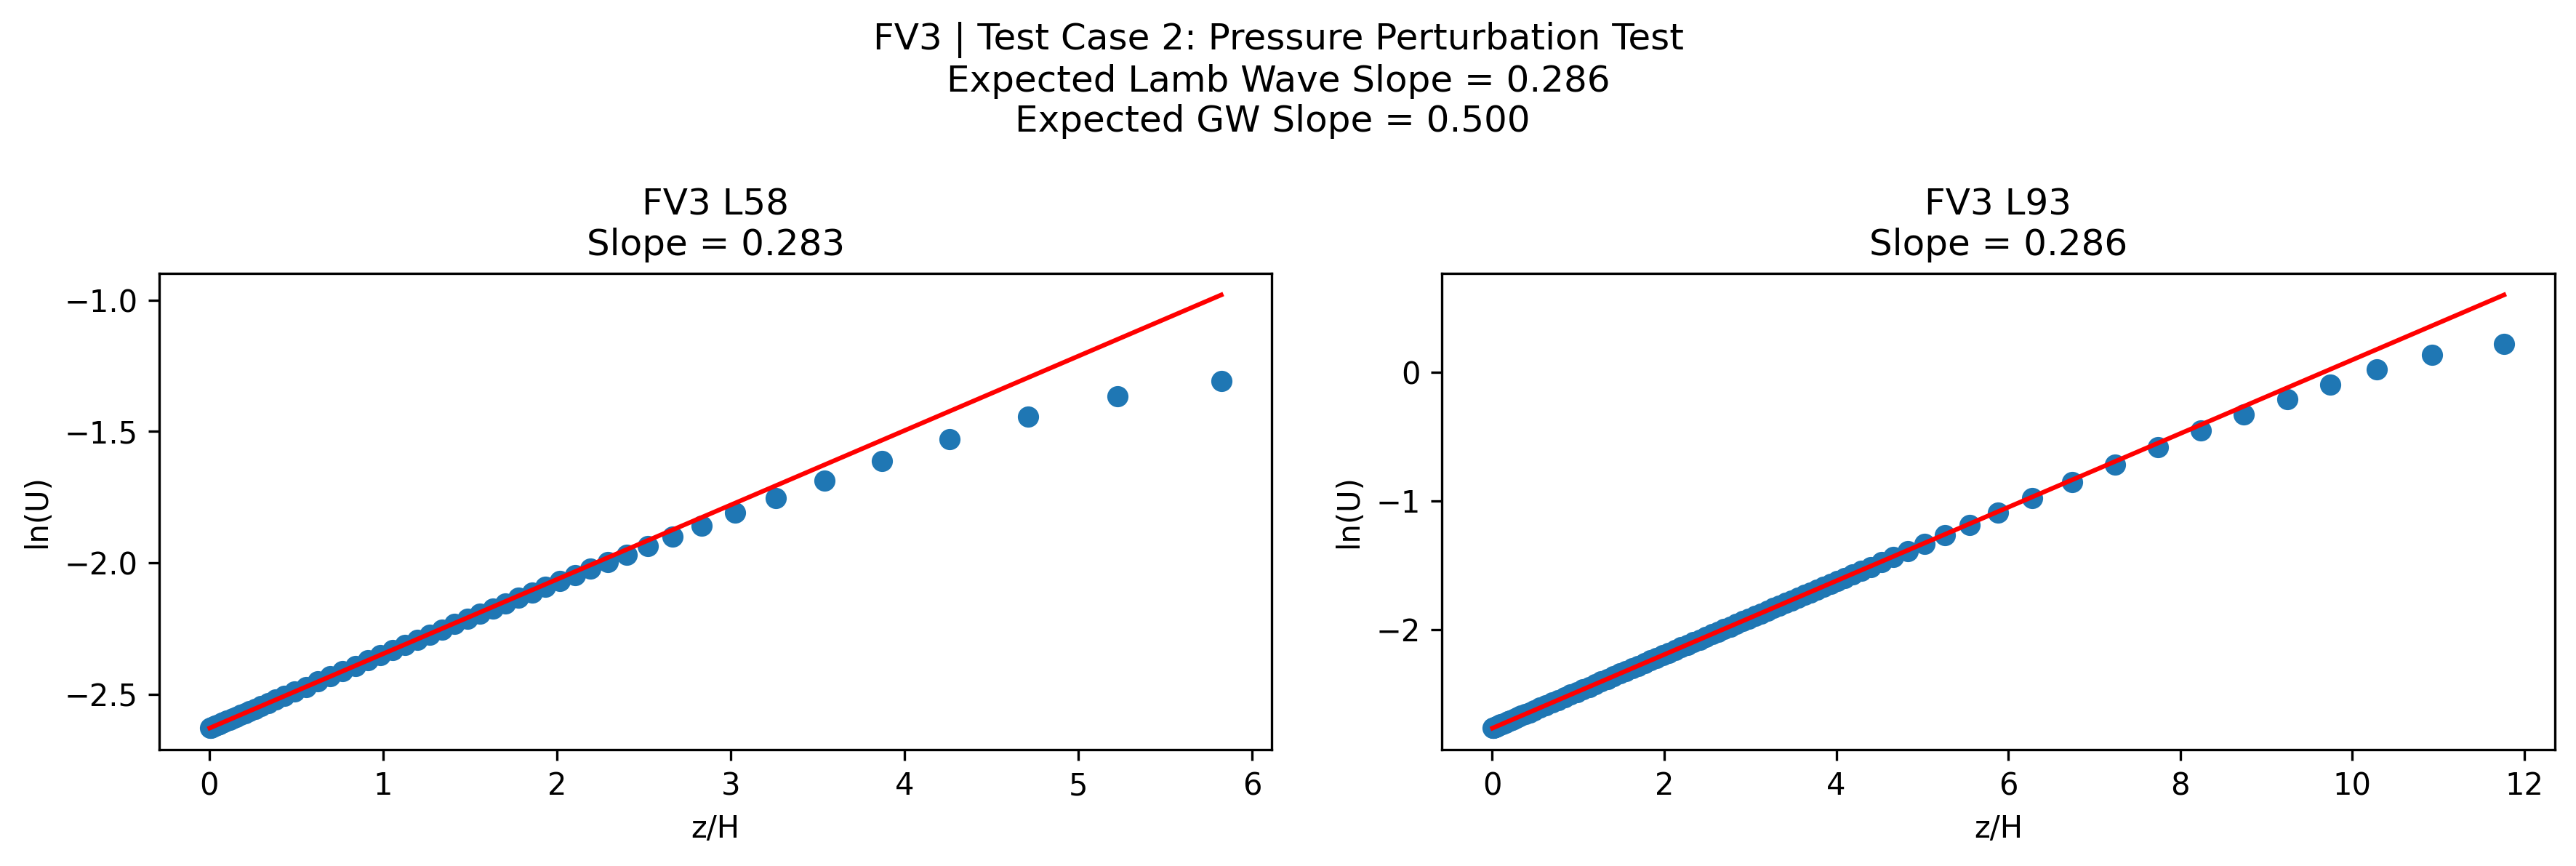

In [ ]:
# Fit on full data
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 275.0
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 50
lat_val = 0

color='orangered'

#50 km CAM default
lon_val = 1 # lon value ahead of first wavefront
X = ds_fv3_L58_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L58_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[0].plot(X, X * p[0] + p[1], color=color)
axes[0].scatter(X, Y, color=color)
# print(p[0])
axes[0].set_title("FV3 L58\n"+f"Slope = {p[0]:.3f}")


# 100 km top, uniform
lon_val = 1
X = ds_fv3_L93_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L93_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[1].plot(X, X * p[0] + p[1], color=color)
axes[1].scatter(X, Y, color=color)
# print(p[0])
axes[1].set_title("FV3 L93\n"+f"Slope = {p[0]:.3f}")

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'FV3 | Test Case 2: Pressure Perturbation Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

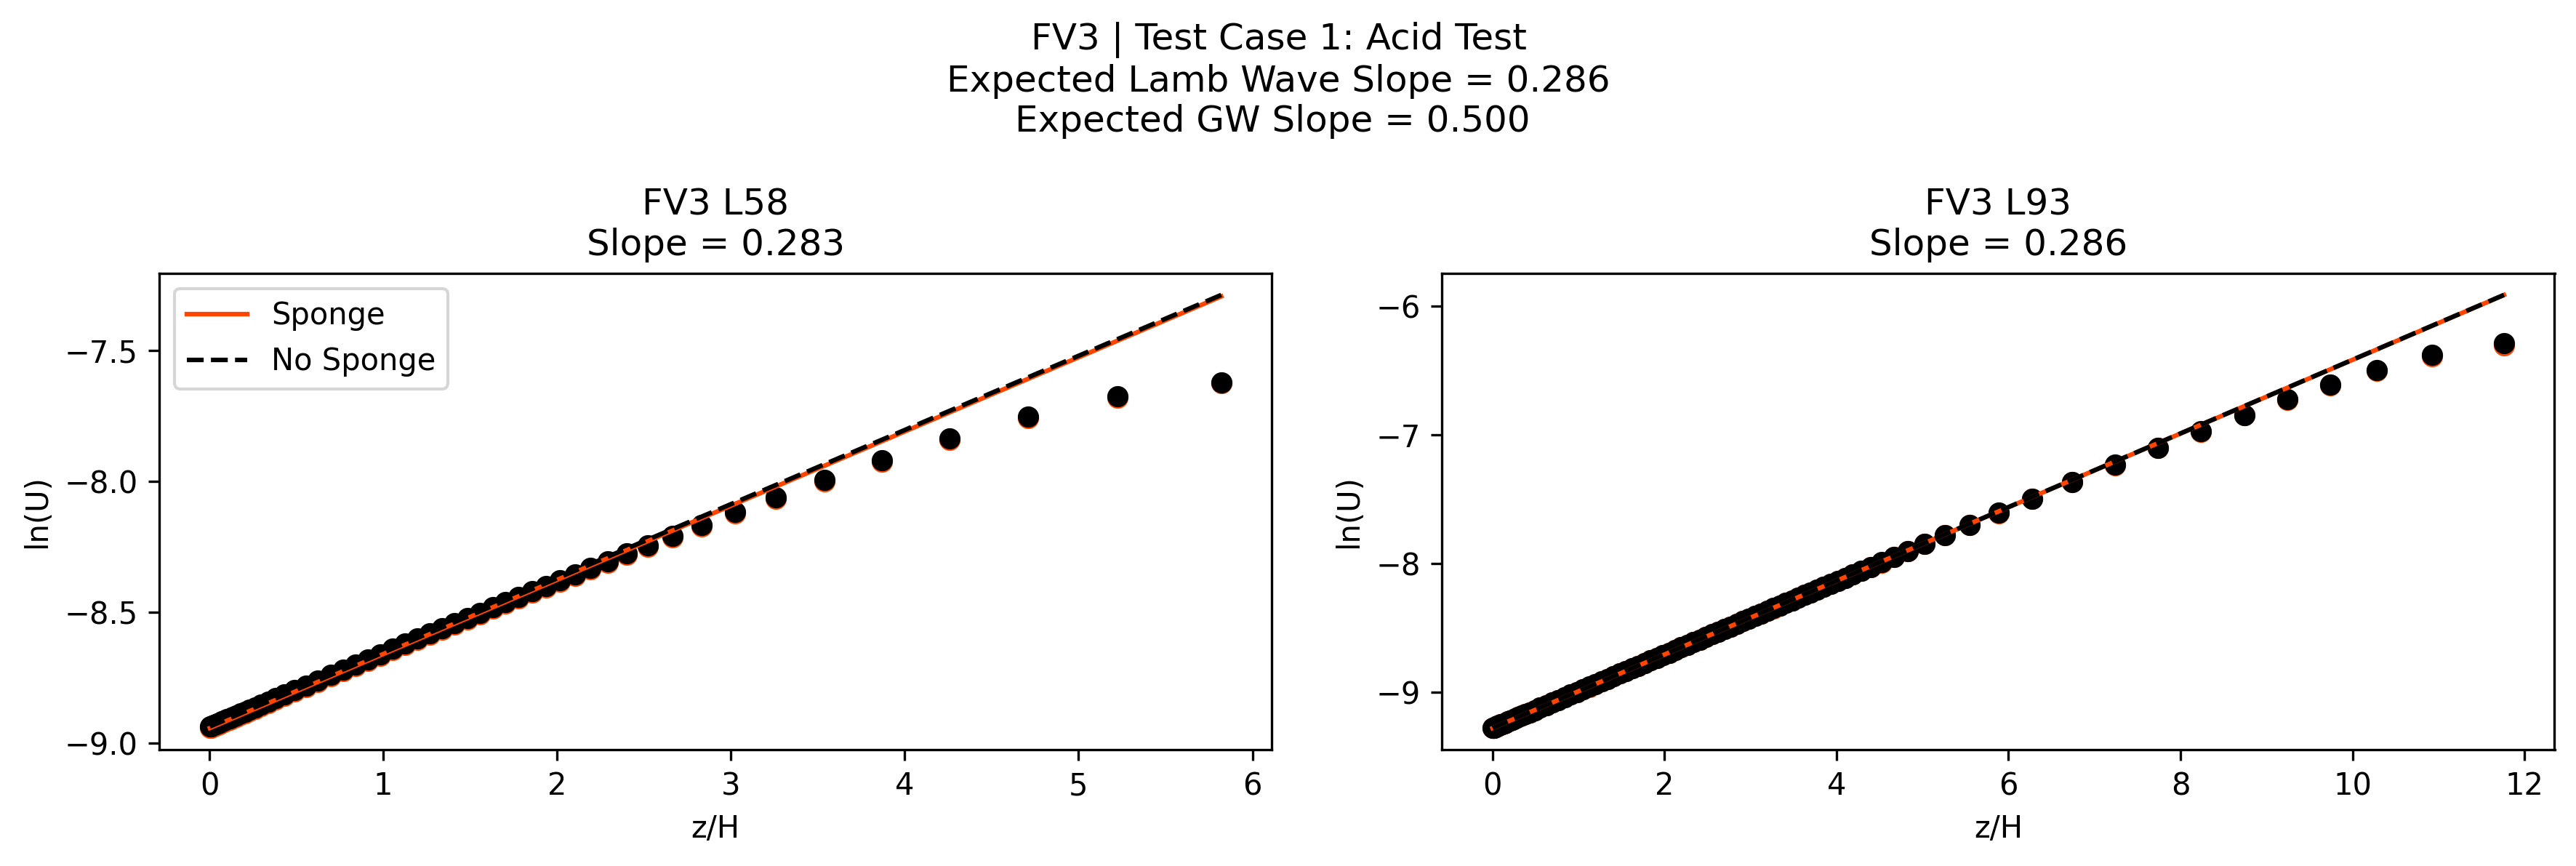

In [7]:
# Fit on full data
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 275.0
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 50
lat_val = 0

color='orangered'

#50 km CAM default
lon_val = 1 # lon value ahead of first wavefront
X = ds_fv3_L58_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L58_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[0].plot(X, X * p[0] + p[1], color=color,label='Sponge')
axes[0].scatter(X, Y,color=color)
# print(p[0])
axes[0].set_title("FV3 L58\n"+f"Slope = {p[0]:.3f}")


# 100 km top, uniform
lon_val = 1 # if I use 5 then the amplitudes match better
X = ds_fv3_L93_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L93_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[1].plot(X, X * p[0] + p[1], color=color)
axes[1].scatter(X, Y,color=color)
# print(p[0])
axes[1].set_title("FV3 L93\n"+f"Slope = {p[0]:.3f}")

#50 km CAM default
lon_val = 1 # lon value ahead of first wavefront
X = ds_fv3_L58_acid_no_spg.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L58_acid_no_spg.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[0].plot(X, X * p[0] + p[1], color='k',linestyle='--',label='No Sponge')
axes[0].scatter(X, Y,color='k')
# print(p[0])
axes[0].set_title("FV3 L58\n"+f"Slope = {p[0]:.3f}")


# 100 km top, uniform
lon_val = 1 # if I use 5 then the amplitudes match better
X = ds_fv3_L93_acid_no_spg.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L93_acid_no_spg.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[1].plot(X, X * p[0] + p[1], color='k',linestyle='--')
axes[1].scatter(X, Y,color='k')
# print(p[0])
axes[1].set_title("FV3 L93\n"+f"Slope = {p[0]:.3f}")
axes[0].legend()

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'FV3 | Test Case 1: Acid Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

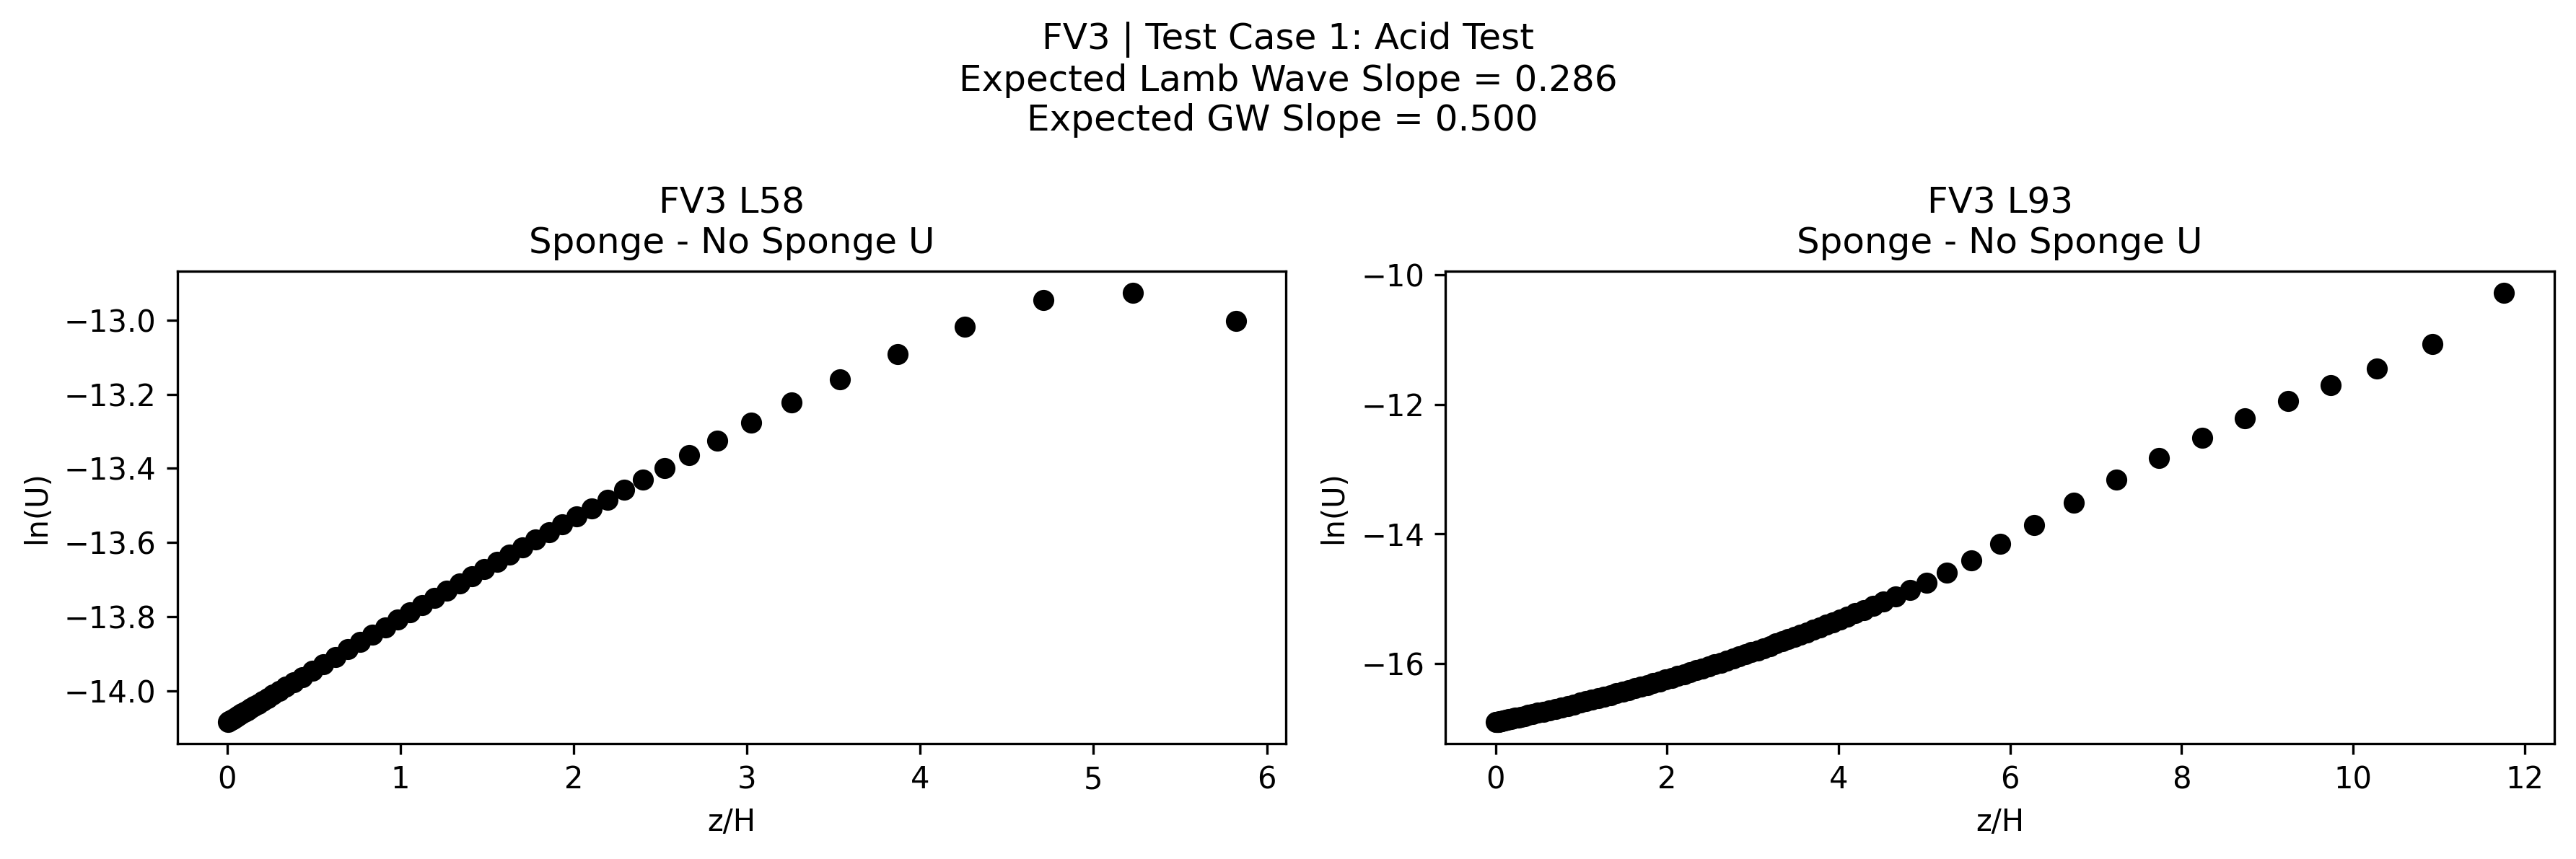

In [14]:
# Fit on full data
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 275.0
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 50
lat_val = 0

color='orangered'

# #50 km CAM default
# lon_val = 1 # lon value ahead of first wavefront
# X = ds_fv3_L58_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
# Y = np.log(abs(ds_fv3_L58_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
# p = np.polyfit(X[X<=1], Y[X<=1], 1)
# axes[0].plot(X, X * p[0] + p[1], color=color,label='Sponge')
# axes[0].scatter(X, Y,color=color)
# # print(p[0])
# axes[0].set_title("FV3 L58\n"+f"Slope = {p[0]:.3f}")


# # 100 km top, uniform
# lon_val = 1 # if I use 5 then the amplitudes match better
# X = ds_fv3_L93_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
# Y = np.log(abs(ds_fv3_L93_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
# p = np.polyfit(X[X<=1], Y[X<=1], 1)
# axes[1].plot(X, X * p[0] + p[1], color=color)
# axes[1].scatter(X, Y,color=color)
# # print(p[0])
# axes[1].set_title("FV3 L93\n"+f"Slope = {p[0]:.3f}")

#50 km CAM default
lon_val = 1 # lon value ahead of first wavefront
X = ds_fv3_L58_acid_no_spg.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L58_acid_no_spg.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') - \
               ds_fv3_L58_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))

axes[0].scatter(X, Y,color='k')
# print(p[0])
axes[0].set_title("FV3 L58\n"+f"Sponge - No Sponge U")


# 100 km top, uniform
lon_val = 1 # if I use 5 then the amplitudes match better
X = ds_fv3_L93_acid_no_spg.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L93_acid_no_spg.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') - \
               ds_fv3_L93_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))

axes[1].scatter(X, Y,color='k')
# print(p[0])
axes[1].set_title("FV3 L93\n"+f"Sponge - No Sponge U")
# axes[0].legend()

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'FV3 | Test Case 1: Acid Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

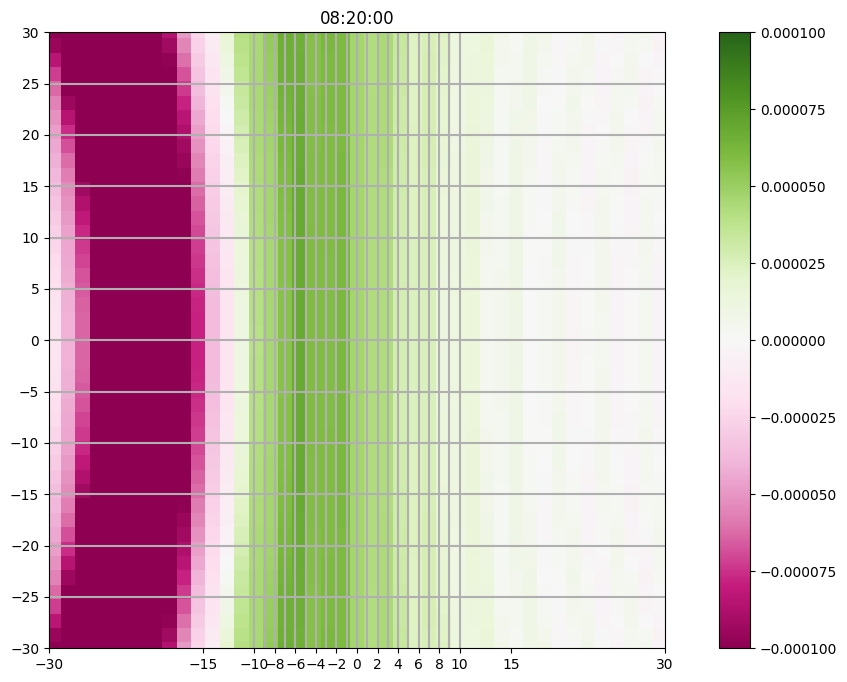

In [14]:
ds = ds_eul_L93_acid
# Plot the U850 horizontal slice at a given time index with grid lines
MyProj = ccrs.PlateCarree()

fig, ax = plt.subplots(subplot_kw={'projection': MyProj},figsize=(14,8))

time_ind = 50

# xmin, xmax = 90-180, 270-180
xmin, xmax = -30, 30
ymin, ymax = -30, 30

xtick_locs = (xmin, xmin/2, *np.arange(-10,10+2,2), xmax/2,xmax)
gl_xtick_locs = (xmin, *np.arange(-10,10+1,1), xmax)
ytick_locs = np.linspace(ymin, ymax, 13)

pcmesh = ax.pcolormesh(ds.lon,
                       ds.lat,
                       ds.U850[time_ind], transform=MyProj,
                       cmap='PiYG',
                     #   vmin=-0.1,vmax=0.1) #pressure
                        vmin=-1.0e-4,vmax=1.0e-4)#acid
ax.set_extent(([xmin, xmax, ymin, ymax]), crs=MyProj)
ax.set_xticks(xtick_locs, crs=MyProj)
ax.set_yticks(ytick_locs, crs=MyProj)
ax.set_title(num2date(ds.time)[time_ind].strftime('%H:%M:%S'))
gl = ax.gridlines(lw=1.5)
gl.xlocator = mticker.FixedLocator(gl_xtick_locs)
gl.ylocator = mticker.FixedLocator(ytick_locs)
plt.colorbar(pcmesh, ax=ax)

plt.show()

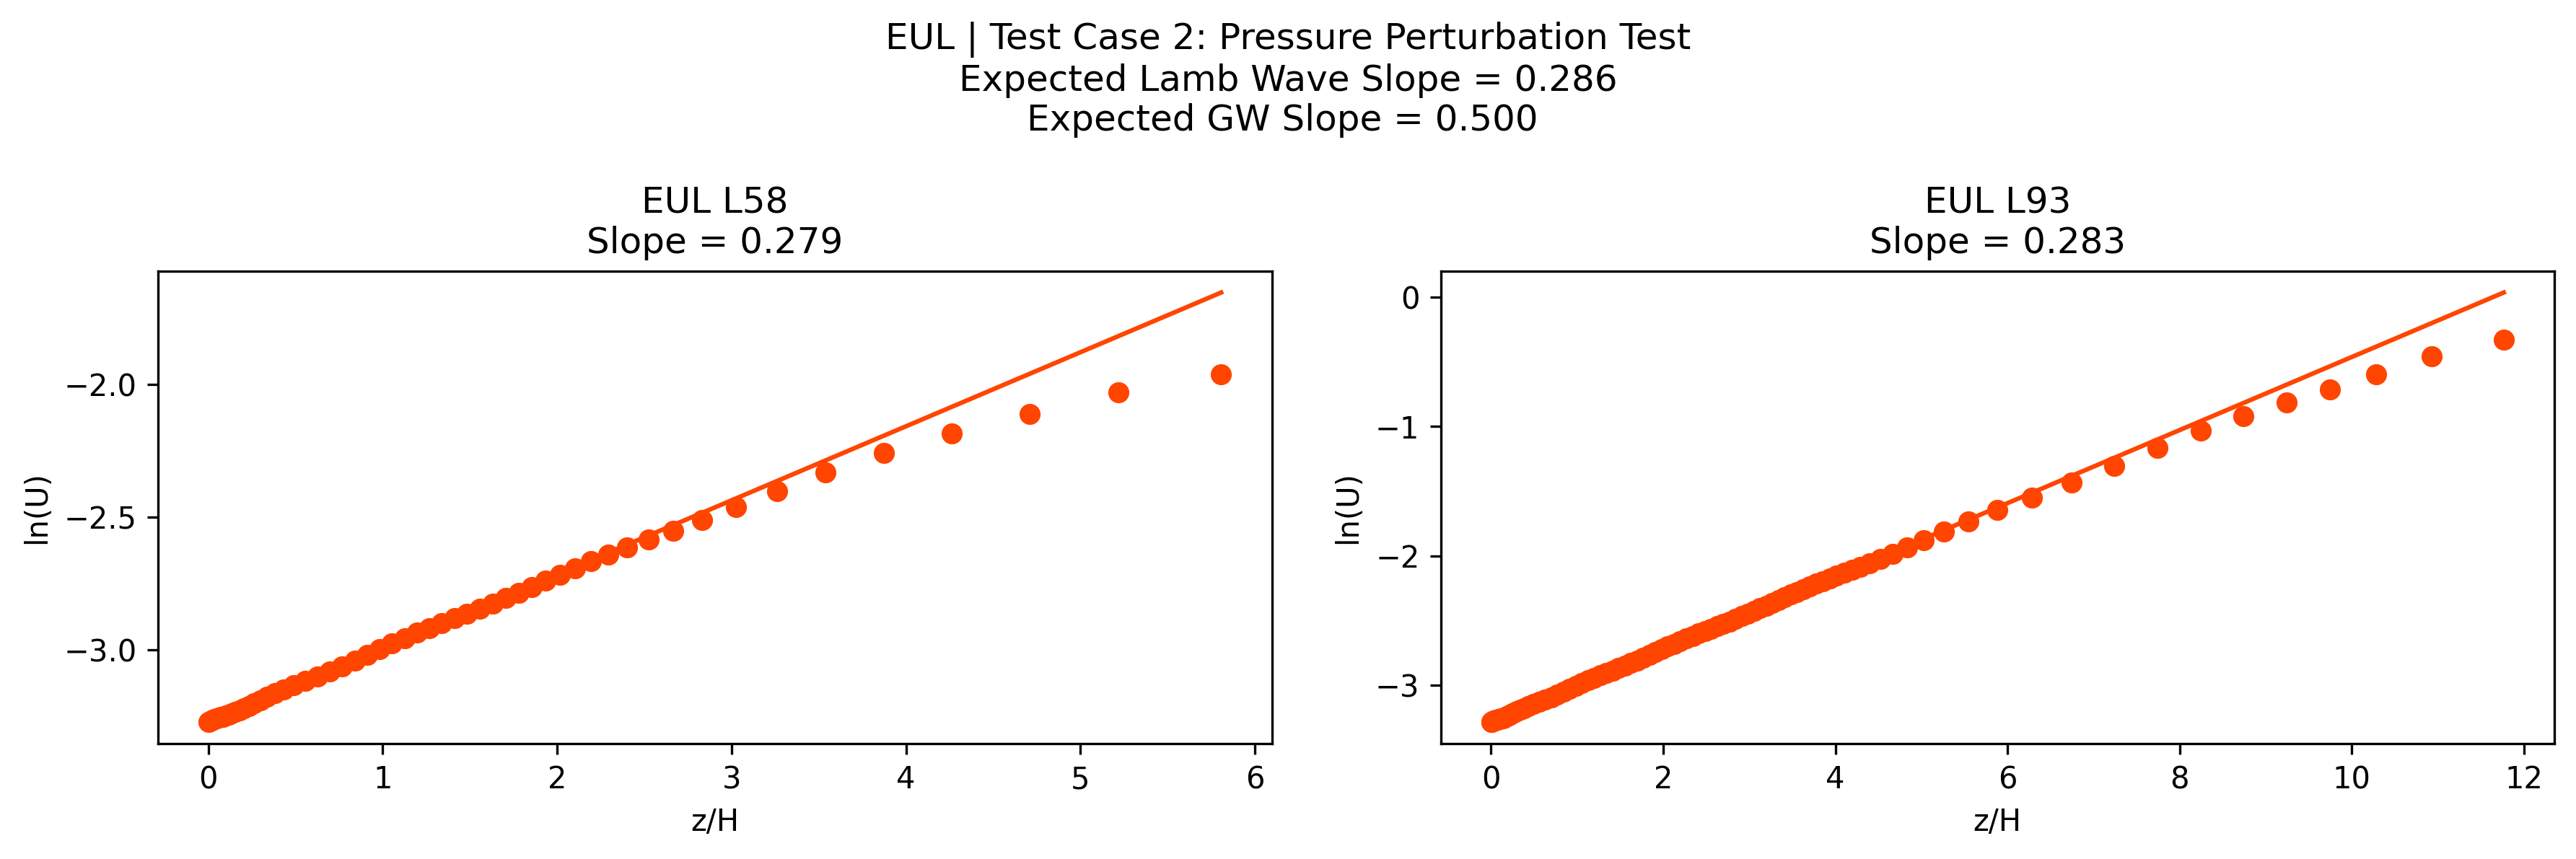

In [25]:
# Fit on full data
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 275.0
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 50
lat_val = 0

color='orangered'

#50 km CAM default
lon_val = 360-1 # lon value ahead of first wavefront
X = ds_eul_L58_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H # not present currently
X = ds_eul_L58_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_eul_L58_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[0].plot(X, X * p[0] + p[1], color=color)
axes[0].scatter(X, Y, color=color)
# print(p[0])
axes[0].set_title("EUL L58\n"+f"Slope = {p[0]:.3f}")


# 100 km top, uniform
lon_val = 360-1
X = ds_eul_L93_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
X = ds_fv3_L93_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_eul_L93_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[1].plot(X, X * p[0] + p[1], color=color)
axes[1].scatter(X, Y, color=color)
# print(p[0])
axes[1].set_title("EUL L93\n"+f"Slope = {p[0]:.3f}")

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'EUL | Test Case 2: Pressure Perturbation Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

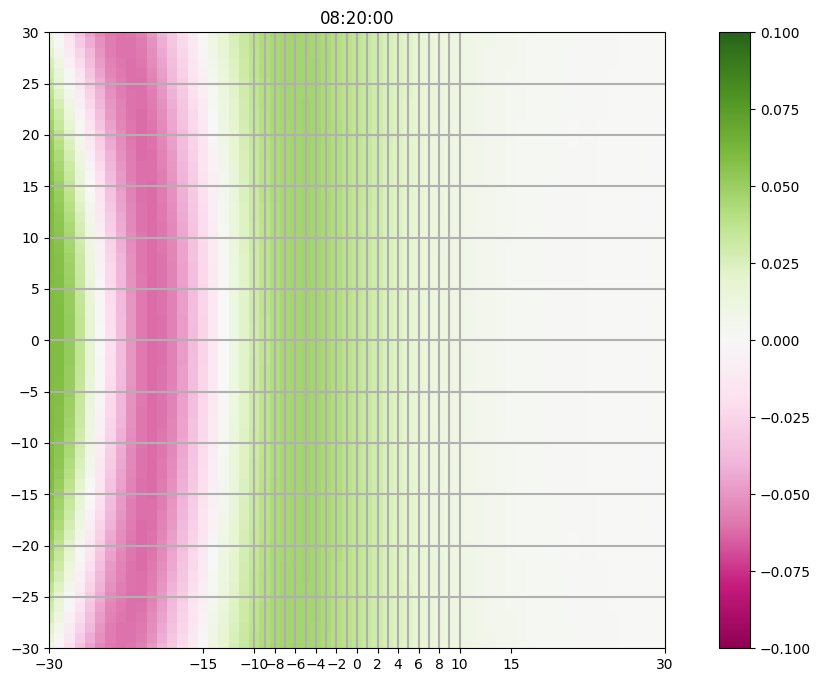

In [18]:
ds = ds_eul_L93_pressure
# Plot the U850 horizontal slice at a given time index with grid lines
MyProj = ccrs.PlateCarree()

fig, ax = plt.subplots(subplot_kw={'projection': MyProj},figsize=(14,8))

time_ind = 50

# xmin, xmax = 90-180, 270-180
xmin, xmax = -30, 30
ymin, ymax = -30, 30

xtick_locs = (xmin, xmin/2, *np.arange(-10,10+2,2), xmax/2,xmax)
gl_xtick_locs = (xmin, *np.arange(-10,10+1,1), xmax)
ytick_locs = np.linspace(ymin, ymax, 13)

pcmesh = ax.pcolormesh(ds.lon,
                       ds.lat,
                       ds.U850[time_ind], transform=MyProj,
                       cmap='PiYG',
                       vmin=-0.1,vmax=0.1) #pressure
                    #    vmin=-1.0e-4,vmax=1.0e-4)#acid
ax.set_extent(([xmin, xmax, ymin, ymax]), crs=MyProj)
ax.set_xticks(xtick_locs, crs=MyProj)
ax.set_yticks(ytick_locs, crs=MyProj)
ax.set_title(num2date(ds.time)[time_ind].strftime('%H:%M:%S'))
gl = ax.gridlines(lw=1.5)
gl.xlocator = mticker.FixedLocator(gl_xtick_locs)
gl.ylocator = mticker.FixedLocator(ytick_locs)
plt.colorbar(pcmesh, ax=ax)

plt.show()

In [26]:
ds_mpas_L58_pressure.lon

<xarray.DataArray 'lon' (lon: 360)> Size: 3kB
array([  0.,   1.,   2., ..., 357., 358., 359.], shape=(360,))
Coordinates:
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Attributes:
    long_name:      Longitude of Grid Cell Centers
    standard_name:  longitude
    units:          degrees_east
    axis:           X
    valid_min:      0.0
    valid_max:      360.0
    bounds:         lon_bnds

332.4310454816156


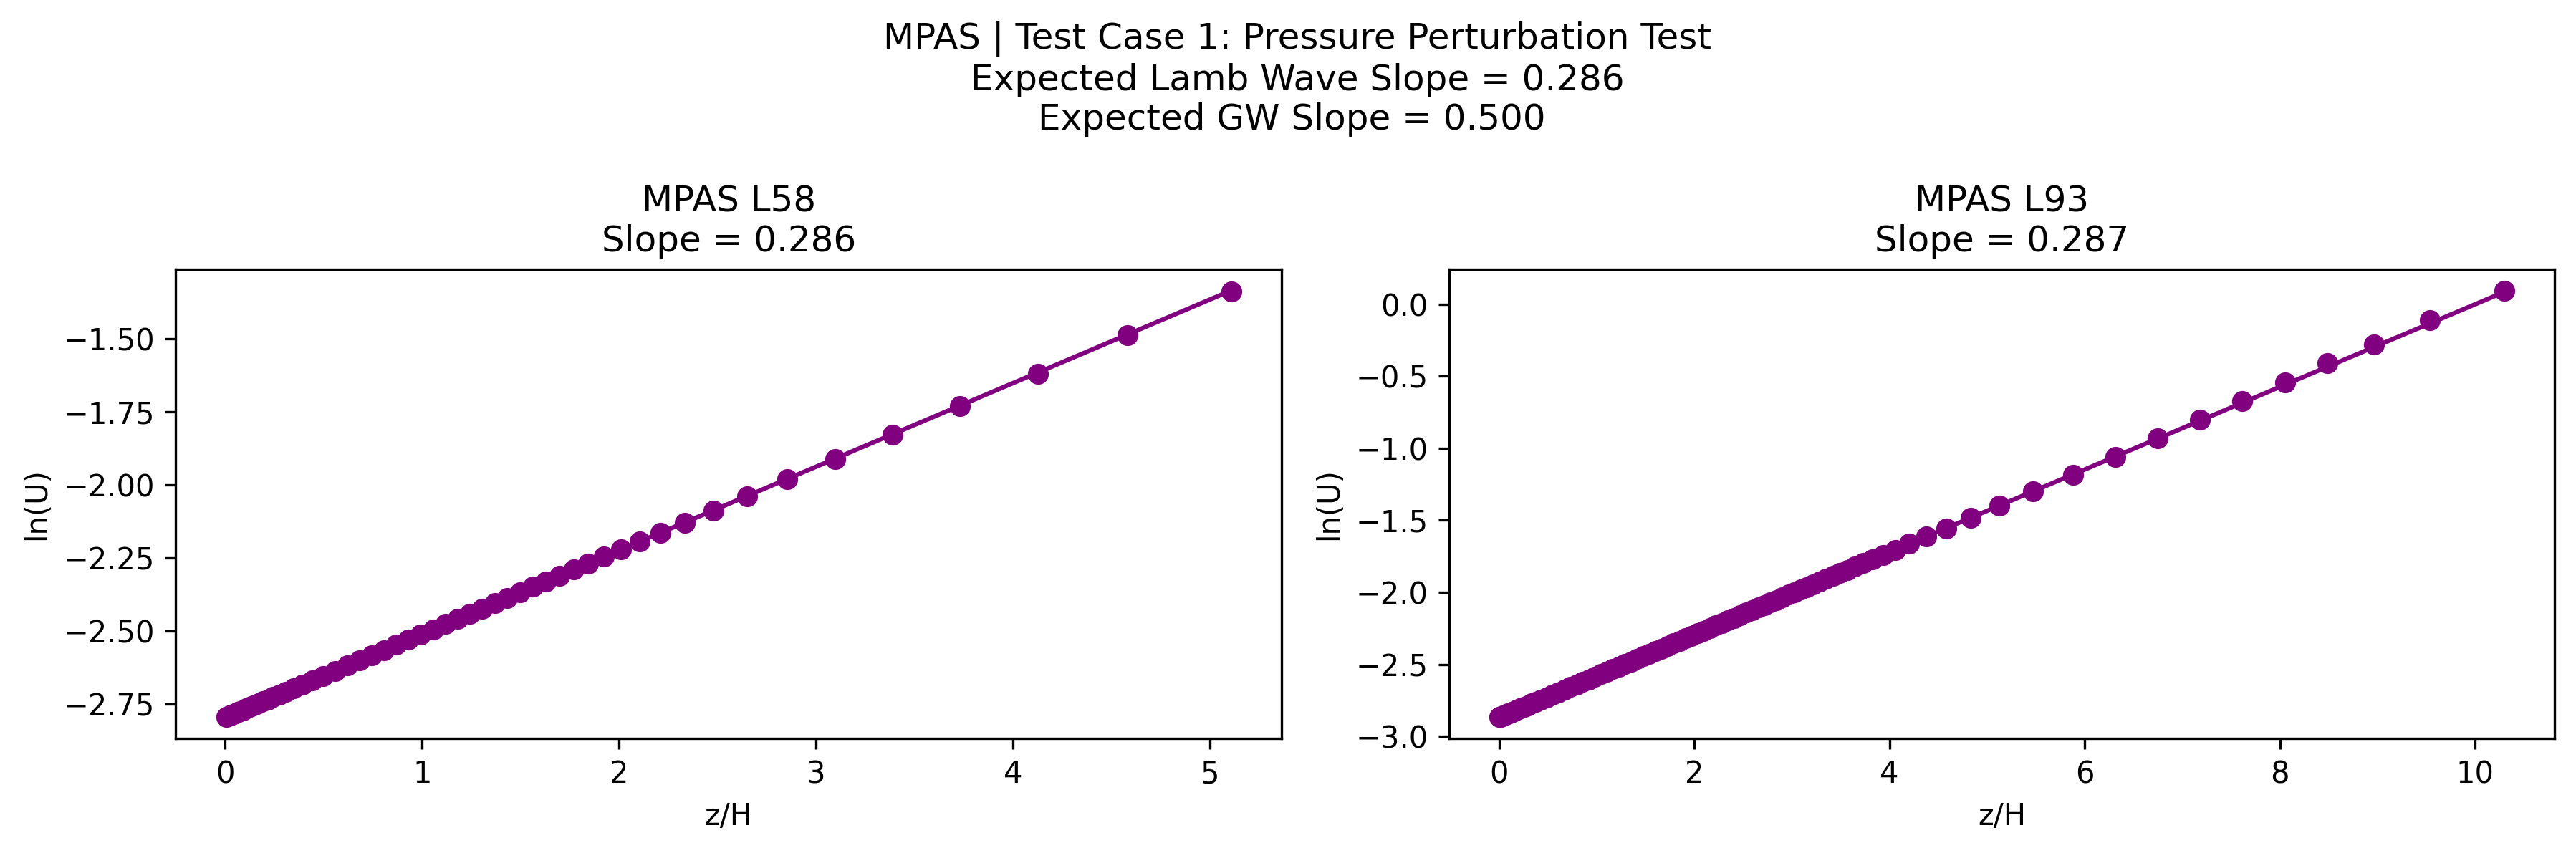

In [27]:
# Fit on full data
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 275.0
Rd = 287.04
g = 9.80616
print(np.sqrt(1.4*Rd*T0))

H = (Rd * T0) / g
time_ind = 50
lat_val = 0

color='purple'

#50 km CAM default
lon_val = 3 # lon value ahead of first wavefront
X = ds_mpas_L58_pressure.lev / H # eul Z3 hasn't been interpolated yet
Y = np.log(abs(ds_mpas_L58_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
# p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], color=color)
axes[0].scatter(X, Y,color=color)
# print(p[0])
axes[0].set_title("MPAS L58\n"+f"Slope = {p[0]:.3f}")


# 100 km top, uniform
lon_val = 3 # if I use 5 then the amplitudes match better
# X = ds_mpas_L93_pressure_Z3.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H # eul Z3 hasn't been interpolated yet
X = ds_mpas_L93_pressure.lev / H # eul Z3 hasn't been interpolated yet
Y = np.log(abs(ds_mpas_L93_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
# p = np.polyfit(X, Y, 1)
p = np.polyfit(X[X<=1], Y[X<=1], 1)
axes[1].plot(X, X * p[0] + p[1], color=color)
axes[1].scatter(X, Y,color=color)
# print(p[0])
axes[1].set_title("MPAS L93\n"+f"Slope = {p[0]:.3f}")

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 

fig.suptitle(f'MPAS | Test Case 1: Pressure Perturbation Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

In [39]:
(332*600)/1000.0

199.2

In [38]:
86400/144

600.0

0.2250631203175937
<xarray.DataArray 'lon' (lon: 360)> Size: 3kB
array([  0.,   1.,   2., ..., 357., 358., 359.], shape=(360,))
Coordinates:
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Attributes:
    long_name:      Longitude of Grid Cell Centers
    standard_name:  longitude
    units:          degrees_east
    axis:           X
    modulo:         360.0
    topology:       circular
    valid_min:      0.0
    valid_max:      360.0
    bounds:         lon_bnds


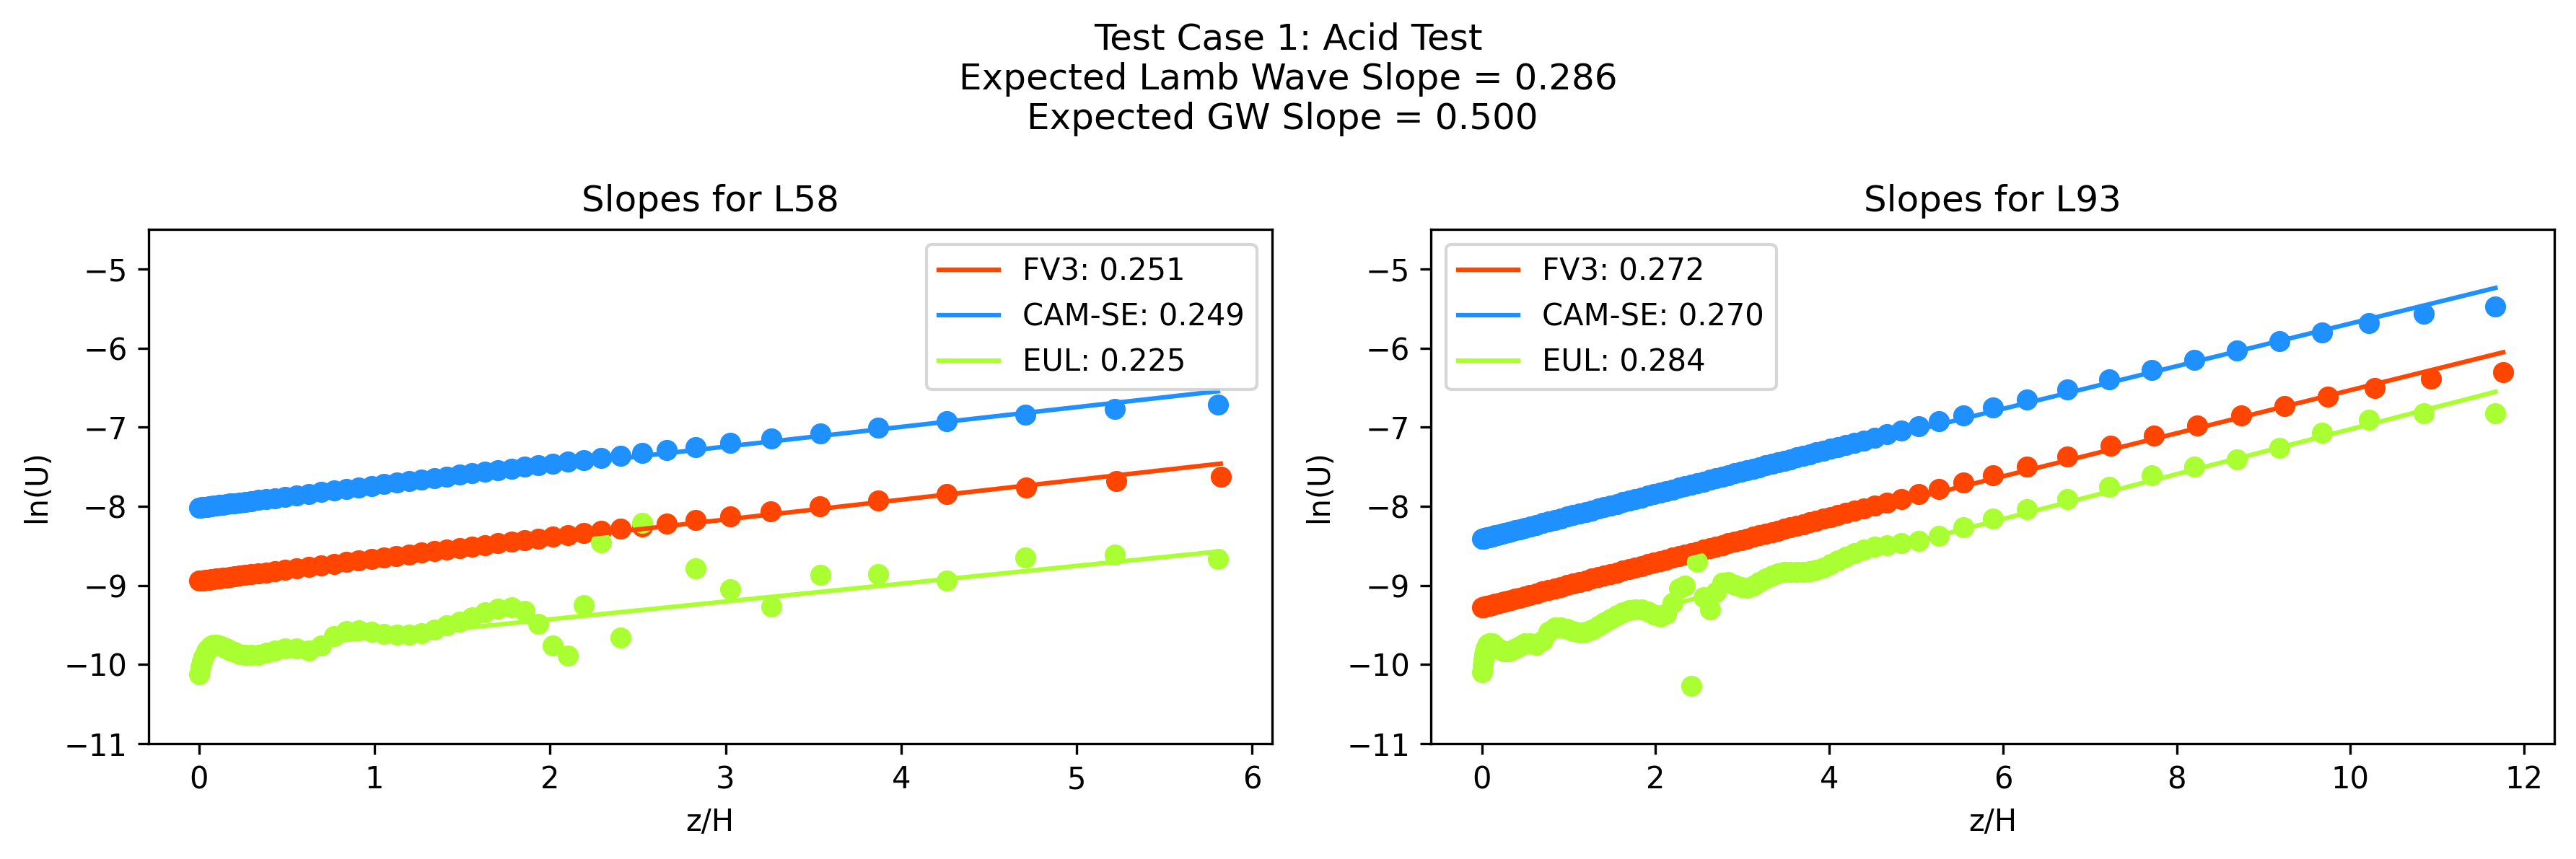

In [51]:
# Acid test case slopes
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 275.0
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 50
lat_val = 0
axes[0].set_title(r"Slopes for L58")
axes[1].set_title("Slopes for L93")


#FV3
color='orangered'

# L58
lon_val = 1 # lon value ahead of first wavefront
X = ds_fv3_L58_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L58_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], color=color,label=f"FV3: {p[0]:.3f}")
axes[0].scatter(X, Y,color=color)
# print(p[0])


# L93
lon_val = 1 # if I use 5 then the amplitudes match better
X = ds_fv3_L93_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L93_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], color=color,label=f"FV3: {p[0]:.3f}")
axes[1].scatter(X, Y,color=color)


# SE
color='dodgerblue'

# L58
lon_val = 0 # lon value at center of leading trough
X = ds_se_L58_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_se_L58_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], color=color,label=f"CAM-SE: {p[0]:.3f}")
axes[0].scatter(X, Y, color=color)
# print(p[0])


# L93
lon_val = 0 
X = ds_se_L93_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_se_L93_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], color=color,label=f"CAM-SE: {p[0]:.3f}")
axes[1].scatter(X, Y, color=color)

# EUL
color='#AAFF32'

# L58
lon_val = 359 # lon value at center of leading trough
X = ds_eul_L58_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_eul_L58_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], color=color,label=f"EUL: {p[0]:.3f}")
axes[0].scatter(X, Y, color=color)
print(p[0])


# L93
lon_val = 359 
X = ds_eul_L93_acid.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_eul_L93_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
print(ds_eul_L93_acid.lon)
# print(Y-np.log(abs(ds_eul_L93_acid.U[time_ind, :, :, :].sel(lat=lat_val, lon=0.0, method='nearest'))))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], color=color,label=f"EUL: {p[0]:.3f}")
axes[1].scatter(X, Y, color=color)

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 
    ax.legend()
    ax.set_ylim((-11,-4.5))

fig.suptitle(f'Test Case 1: Acid Test\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

8049.634107540566


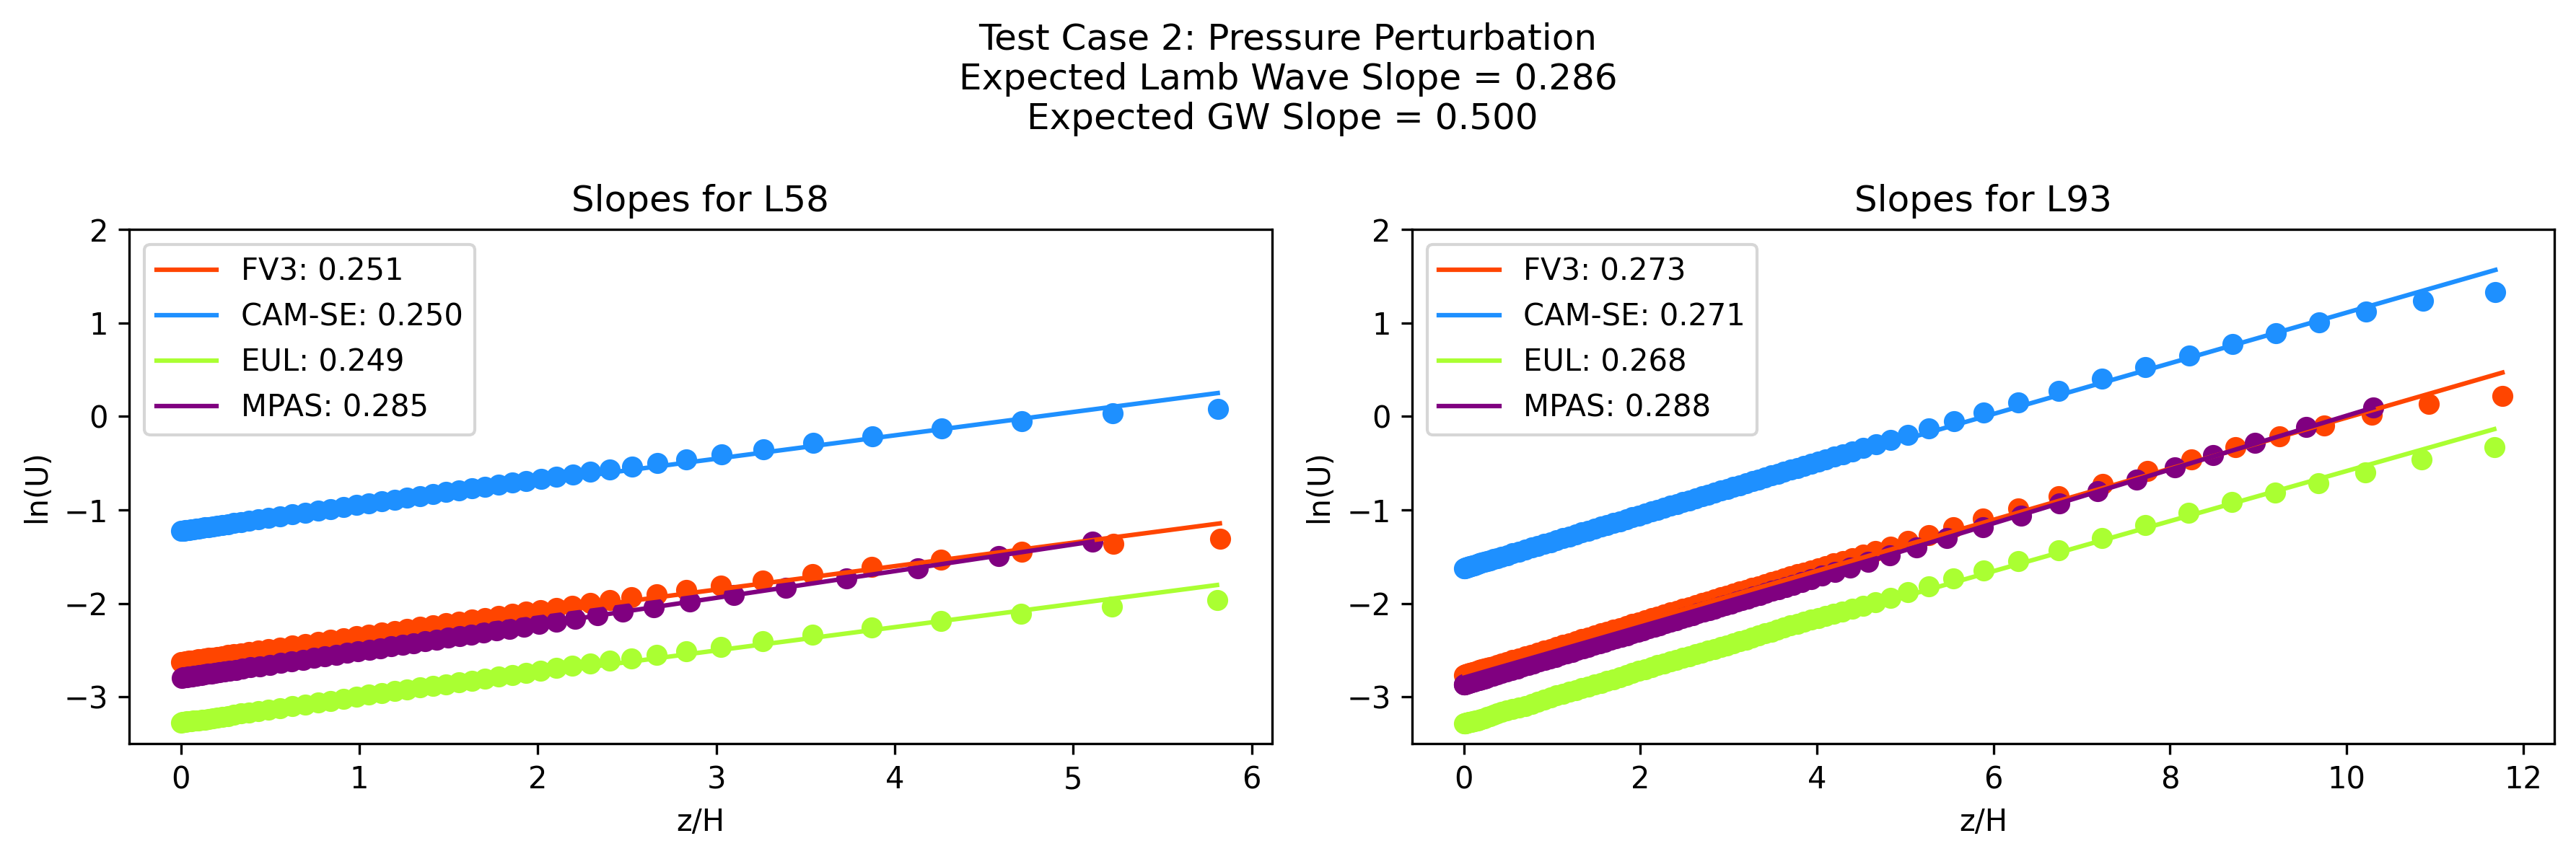

In [50]:
# Acid test case slopes
fig, axes = plt.subplots(1,2,figsize=(12,4),dpi=300)

T0 = 275.0
Rd = 287.04
g = 9.80616

H = (Rd * T0) / g
time_ind = 50
lat_val = 0
axes[0].set_title(r"Slopes for L58")
axes[1].set_title(r"Slopes for L93")


#FV3
color='orangered'

# L58
lon_val = 1 # lon value ahead of first wavefront
X = ds_fv3_L58_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L58_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], color=color,label=f"FV3: {p[0]:.3f}")
axes[0].scatter(X, Y,color=color)
# print(p[0])


# L93
lon_val = 1 # if I use 5 then the amplitudes match better
X = ds_fv3_L93_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_fv3_L93_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], color=color,label=f"FV3: {p[0]:.3f}")
axes[1].scatter(X, Y,color=color)


# SE
color='dodgerblue'

# L58
lon_val = 0 # lon value at center of leading trough
X = ds_se_L58_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_se_L58_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], color=color,label=f"CAM-SE: {p[0]:.3f}")
axes[0].scatter(X, Y, color=color)
# print(p[0])


# L93
lon_val = 0 
X = ds_se_L93_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_se_L93_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], color=color,label=f"CAM-SE: {p[0]:.3f}")
axes[1].scatter(X, Y, color=color)

# EUL
color='#AAFF32'

# L58
lon_val = 359 # lon value at center of leading trough
X = ds_eul_L58_pressure.Z3[time_ind, :, :, :].sel(lat=[-0.700384,   0.700384], lon=lon_val, method='nearest').mean(dim='lat') / H
print(H)
Y = np.log(abs(ds_eul_L58_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], color=color,label=f"EUL: {p[0]:.3f}")
axes[0].scatter(X, Y, color=color)
# print(p[0])


# L93
lon_val = 359 
X = ds_eul_L93_pressure.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_eul_L93_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], color=color,label=f"EUL: {p[0]:.3f}")
axes[1].scatter(X, Y, color=color)

time_ind = 50


# MPAS
color='purple'

# L58
lon_val = 3 # lon value at center of leading trough
X = ds_mpas_L58_pressure.lev / H
Y = np.log(abs(ds_mpas_L58_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[0].plot(X, X * p[0] + p[1], color=color,label=f"MPAS: {p[0]:.3f}")
axes[0].scatter(X, Y, color=color)
# print(p[0])

# L93
lon_val = 3 # lon value at center of leading trough
X = ds_mpas_L93_pressure.lev / H
Y = np.log(abs(ds_mpas_L93_pressure.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))
p = np.polyfit(X[X<=1], Y[X<=1], 1)
p = np.polyfit(X, Y, 1)
axes[1].plot(X, X * p[0] + p[1], color=color,label=f"MPAS: {p[0]:.3f}")
axes[1].scatter(X, Y, color=color)

# plot
for i, ax in enumerate(axes.flatten()):
    ax.set_ylabel('ln(U)')
    ax.set_xlabel('z/H') 
    ax.set_ylim((-3.5,2)) 
    ax.legend()

fig.suptitle(f'Test Case 2: Pressure Perturbation\nExpected Lamb Wave Slope = {2.0/7.0:.3f}\nExpected GW Slope = {0.500:.3f} ')
fig.tight_layout()
plt.show()

In [37]:
ds_mpas_L58_pressure.Z3.isel(lat=0,lon=0,time=0).values

array([4.11163711e+04, 3.68719492e+04, 3.32308008e+04, 3.00325684e+04,
       2.72744102e+04, 2.49322051e+04, 2.29648848e+04, 2.13210078e+04,
       1.99456406e+04, 1.87859844e+04, 1.77950000e+04, 1.69330840e+04,
       1.61682861e+04, 1.54756260e+04, 1.48360312e+04, 1.42351963e+04,
       1.36625225e+04, 1.31102295e+04, 1.25726475e+04, 1.20456592e+04,
       1.15262910e+04, 1.10123975e+04, 1.05024346e+04, 9.99658984e+03,
       9.49490430e+03, 8.99490527e+03, 8.49490527e+03, 7.99490527e+03,
       7.49490527e+03, 6.99490527e+03, 6.49490576e+03, 5.99490576e+03,
       5.49490576e+03, 4.99490527e+03, 4.49490527e+03, 4.00445605e+03,
       3.54819873e+03, 3.14425293e+03, 2.79091138e+03, 2.47976611e+03,
       2.20424268e+03, 1.95910400e+03, 1.74011279e+03, 1.54379370e+03,
       1.36726294e+03, 1.20810254e+03, 1.06426660e+03, 9.34010193e+02,
       8.15834229e+02, 7.07112854e+02, 6.05521057e+02, 5.10307129e+02,
       4.20778473e+02, 3.36279266e+02, 2.56161652e+02, 1.79738312e+02,
      